# Imports

Run this cell to ensure the neccessary packaged are installed (make sure the correct cuda link is used):

In [ ]:
!pip install -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu126

In [2]:
# To generate requirements.txt file:
#!pip list --format=freeze > requirements.txt

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import torch
import torch.nn as nn
import warnings
import statsmodels.api as sm
from sklearn.model_selection import ParameterGrid
import json
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             accuracy_score,
                             roc_auc_score,
                             f1_score,
                             confusion_matrix,
                             classification_report)
from scipy.stats import binomtest
from tabpfn import TabPFNRegressor
import shap
from tabpfn_extensions.interpretability.shapiq import get_tabpfn_imputation_explainer
from tabpfn_extensions.interpretability.shap import shapiq_to_shap_explanation
import networkx as nx
import lime
import os
import gc
import quantus
from scipy.stats import spearmanr
from itertools import combinations
from pathlib import Path
import pickle
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta
import matplotlib.ticker as mticker
from itertools import combinations

# TabPFN API token
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_-XKIJsR_GLPI9Z_f_s0DR1p0u3hIFyoe0JBm09xSkNA"

# Set device for PyTorch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/cs/student/project_msc/2025/cf/kuspatel/comp0077-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


# Data Prep

## Load Data

In [4]:
# Load general features data
general_features = pd.read_csv(Path("Data") / "General Features Data.csv")
general_features.set_index("Date", inplace=True)
general_features.index = pd.to_datetime(general_features.index, dayfirst=True)
general_features.sort_index(inplace=True)
display(general_features)
print(general_features.columns)

,VIX Index,OVX Index,MOVE Index,DXY Curncy,FDTR Index,FDFD Index,GT10 Govt,GDP CQOQ Index,BENWUSGC Index,GDGCAFJP Index,STLNENIC Index,NAPMPMI Index,SPX Index,ES1 Index,MXWO Index
Date,,,,,,,,,,,,,,,
1985-01-01,NaN,NaN,NaN,151.470,8.25,NaN,11.514,3.3,NaN,NaN,NaN,50.6,167.24,NaN,187.20
1985-01-02,NaN,NaN,NaN,152.230,8.25,NaN,11.741,3.3,NaN,NaN,NaN,50.6,165.37,NaN,185.51
1985-01-03,NaN,NaN,NaN,151.970,8.25,NaN,11.600,3.3,NaN,NaN,NaN,50.6,164.57,NaN,184.75
1985-01-04,NaN,NaN,NaN,152.110,8.25,NaN,11.600,3.3,NaN,NaN,NaN,50.6,163.68,NaN,184.59
1985-01-07,NaN,NaN,NaN,152.810,8.25,NaN,11.503,3.3,NaN,NaN,NaN,50.6,164.24,NaN,184.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08,21.04,83.91,78.74,99.133,3.75,3.64,4.293,2.0,2.471,1.320,1.91,52.7,6782.81,6823.75,4458.39
2026-04-09,19.49,81.74,74.01,98.819,3.75,3.64,4.276,2.0,2.210,1.308,1.91,52.7,6824.66,6863.25,4470.41
2026-04-10,19.23,78.01,72.15,98.650,3.75,3.64,4.319,2.0,2.218,1.228,1.99,52.7,6816.89,6855.25,4473.96


Index(['VIX Index', 'OVX Index', 'MOVE Index', 'DXY Curncy', 'FDTR Index',
       'FDFD Index', 'GT10 Govt', 'GDP CQOQ Index', 'BENWUSGC Index',
       'GDGCAFJP Index', 'STLNENIC Index', 'NAPMPMI Index', 'SPX Index',
       'ES1 Index', 'MXWO Index'],
      dtype='str')


In [5]:
# Load energy commodities specific features data
energy_features = pd.read_csv(Path("Data") / "CPLY WTI Features Data.csv")
energy_features.set_index("Date", inplace=True)
energy_features.index = pd.to_datetime(energy_features.index, dayfirst=True)
energy_features.sort_index(inplace=True)
display(energy_features)
print(energy_features.columns)

,CL1 Comdty,CO1 Comdty,HOCL1 Index,USCSMEHC Index,CRK321M1 Index,HUCL1 Index,CLCO1 Index,DSUPKERO Index,DSUPGASL Index,DOEICRP2 Index,...,FZWWFST VTXD Index,DXY Curncy,ES1 Index,EUR Curncy,OVX Index,IP Index,CAD Curncy,INJCJC Index,CNVSPSGR Index,EPUSTOT Index
Date,,,,,,,,,,,,,,,,,,,,,
1985-01-01,26.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,151.470,NaN,0.7114,NaN,54.6416,1.3217,379,NaN,NaN
1985-01-02,25.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,152.230,NaN,0.7063,NaN,54.6416,1.3227,379,NaN,NaN
1985-01-03,25.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,151.970,NaN,0.7083,NaN,54.6416,1.3209,379,NaN,NaN
1985-01-04,25.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,152.110,NaN,0.7086,NaN,54.6416,1.3209,369,NaN,NaN
1985-01-07,25.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,152.810,NaN,0.7066,NaN,54.6416,1.3217,369,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08,94.41,94.75,65.250,4.46,41.895,30.218,-8.22,27.1,27.4,3094.0,...,NaN,99.133,6823.75,1.1663,83.91,102.5510,1.3846,219,2411856.0,76196.0
2026-04-09,97.87,95.92,67.484,4.91,41.268,28.159,-6.20,27.1,27.4,3094.0,...,NaN,98.819,6863.25,1.1699,81.74,102.5510,1.3815,219,2411856.0,76196.0
2026-04-10,96.57,95.20,61.548,4.46,41.321,31.207,-5.24,27.1,27.4,3094.0,...,NaN,98.650,6855.25,1.1723,78.01,102.5510,1.3841,219,2411856.0,76196.0


Index(['CL1 Comdty', 'CO1 Comdty', 'HOCL1 Index', 'USCSMEHC Index',
       'CRK321M1 Index', 'HUCL1 Index', 'CLCO1 Index', 'DSUPKERO Index',
       'DSUPGASL Index', 'DOEICRP2 Index', 'BAKETOT Index', 'BAKEGAS Index',
       'DOESCRUD Index', 'DOESCROK Index', 'DSUPCRUD Index', 'DOEPGRIN Index',
       'DOEPPERC Index', 'DSUPDIST Index', 'FZWWFST VTXD Index', 'DXY Curncy',
       'ES1 Index', 'EUR Curncy', 'OVX Index', 'IP Index', 'CAD Curncy',
       'INJCJC Index', 'CNVSPSGR Index', 'EPUSTOT Index'],
      dtype='str')


In [6]:
# Combine both datasets, dropping duplicate columns
overlap = general_features.columns.intersection(energy_features.columns)
print(f"Duplicate columns dropped: {overlap.tolist()}")
all_features = pd.merge(general_features, energy_features.drop(columns=overlap), left_index=True, right_index=True, how='outer')
display(all_features)
all_features.columns

Duplicate columns dropped: ['OVX Index', 'DXY Curncy', 'ES1 Index']


,VIX Index,OVX Index,MOVE Index,DXY Curncy,FDTR Index,FDFD Index,GT10 Govt,GDP CQOQ Index,BENWUSGC Index,GDGCAFJP Index,...,DOEPGRIN Index,DOEPPERC Index,DSUPDIST Index,FZWWFST VTXD Index,EUR Curncy,IP Index,CAD Curncy,INJCJC Index,CNVSPSGR Index,EPUSTOT Index
Date,,,,,,,,,,,,,,,,,,,,,
1985-01-01,NaN,NaN,NaN,151.470,8.25,NaN,11.514,3.3,NaN,NaN,...,NaN,NaN,NaN,NaN,0.7114,54.6416,1.3217,379,NaN,NaN
1985-01-02,NaN,NaN,NaN,152.230,8.25,NaN,11.741,3.3,NaN,NaN,...,NaN,NaN,NaN,NaN,0.7063,54.6416,1.3227,379,NaN,NaN
1985-01-03,NaN,NaN,NaN,151.970,8.25,NaN,11.600,3.3,NaN,NaN,...,NaN,NaN,NaN,NaN,0.7083,54.6416,1.3209,379,NaN,NaN
1985-01-04,NaN,NaN,NaN,152.110,8.25,NaN,11.600,3.3,NaN,NaN,...,NaN,NaN,NaN,NaN,0.7086,54.6416,1.3209,369,NaN,NaN
1985-01-07,NaN,NaN,NaN,152.810,8.25,NaN,11.503,3.3,NaN,NaN,...,NaN,NaN,NaN,NaN,0.7066,54.6416,1.3217,369,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08,21.04,83.91,78.74,99.133,3.75,3.64,4.293,2.0,2.471,1.320,...,16578.0,92.0,28.6,NaN,1.1663,102.5510,1.3846,219,2411856.0,76196.0
2026-04-09,19.49,81.74,74.01,98.819,3.75,3.64,4.276,2.0,2.210,1.308,...,16578.0,92.0,28.6,NaN,1.1699,102.5510,1.3815,219,2411856.0,76196.0
2026-04-10,19.23,78.01,72.15,98.650,3.75,3.64,4.319,2.0,2.218,1.228,...,16578.0,92.0,28.6,NaN,1.1723,102.5510,1.3841,219,2411856.0,76196.0


Index(['VIX Index', 'OVX Index', 'MOVE Index', 'DXY Curncy', 'FDTR Index',
       'FDFD Index', 'GT10 Govt', 'GDP CQOQ Index', 'BENWUSGC Index',
       'GDGCAFJP Index', 'STLNENIC Index', 'NAPMPMI Index', 'SPX Index',
       'ES1 Index', 'MXWO Index', 'CL1 Comdty', 'CO1 Comdty', 'HOCL1 Index',
       'USCSMEHC Index', 'CRK321M1 Index', 'HUCL1 Index', 'CLCO1 Index',
       'DSUPKERO Index', 'DSUPGASL Index', 'DOEICRP2 Index', 'BAKETOT Index',
       'BAKEGAS Index', 'DOESCRUD Index', 'DOESCROK Index', 'DSUPCRUD Index',
       'DOEPGRIN Index', 'DOEPPERC Index', 'DSUPDIST Index',
       'FZWWFST VTXD Index', 'EUR Curncy', 'IP Index', 'CAD Curncy',
       'INJCJC Index', 'CNVSPSGR Index', 'EPUSTOT Index'],
      dtype='str')

In [7]:
# Load feature details and create a mapping from Bloomberg ID to Common Name
Feature_Details = pd.read_csv(Path("Data") / "WTI All Features Details.csv")
Feature_Name_Map = Feature_Details.set_index('Bloomberg ID')['Common Name'].to_dict()
display(Feature_Details)
Feature_Name_Map

,Bloomberg ID,Bloomberg Name,Common Name,Description,Start date,Frequency
0,VIX Index,Cboe Volatility Index,VIX Index,S&P 500 implied volatility index,02/01/1990,Daily
1,OVX Index,Cboe Oil ETF VIX Index,OVX Index,Crude futures implied volatility index,10/05/2007,Daily
2,MOVE Index,MOVE,MOVE Index,US Treasuries implied volatility index,04/04/1988,Daily
3,DXY Curncy,DOLLAR INDEX SPOT,USD FX,Weighted average of 6 US Dollar exchange rates,01/01/1985,Daily
4,FDTR Index,Federal Funds Target Rate - Up,Fed Rate Upper Target,Target Fed rate upper bound,01/01/1985,Daily (Fed meetings)
5,FDFD Index,ICAP US Federal Funds Rate,Fed Rate,Fed effective rate,17/02/1995,Daily
6,GT10 Govt,US TREASURY N/B,10Y Treasury Yield,10 year US treasury yield,01/01/1985,Daily
7,GDP CQOQ Index,GDP US Chained Dollars QoQ SAA,US QoQ GDP Growth,US QoQ GDP growth,01/01/1985,Quarterly
8,BENWUSGC Index,Bloomberg Economics US GDP Now,US QoQ GDP Growth Nowcast,US GDP QoQ growth nowcast,31/03/2020,Daily
9,GDGCAFJP Index,Atlanta Fed GDPNow GDP Forecas,US QoQ GDP Growth Nowcast,US GDP QoQ growth nowcast,25/08/2011,Daily


{'VIX Index': 'VIX Index',
 'OVX Index': 'OVX Index',
 'MOVE Index': 'MOVE Index',
 'DXY Curncy': 'USD FX',
 'FDTR Index': 'Fed Rate Upper Target',
 'FDFD Index': 'Fed Rate',
 'GT10 Govt': '10Y Treasury Yield',
 'GDP CQOQ Index': 'US QoQ GDP Growth',
 'BENWUSGC Index': 'US QoQ GDP Growth Nowcast',
 'GDGCAFJP Index': 'US QoQ GDP Growth Nowcast',
 'STLNENIC Index': 'US QoQ GDP Growth Nowcast',
 'NAPMPMI Index': 'US Purchasing Managers Index',
 'SPX Index': 'S&P 500',
 'ES1 Index': 'S&P 500 Futures',
 'MXWO Index': 'MSCI World Index',
 'CL1 Comdty': 'WTI Price',
 'CO1 Comdty': 'Brent Price',
 'HOCL1 Index': 'Heating Oil Spread',
 'USCSMEHC Index': 'Cushing Crude Price',
 'CRK321M1 Index': '321 Crack Spread',
 'HUCL1 Index': 'Gasoline Spread',
 'CLCO1 Index': 'WTI-Brent Spread',
 'DSUPKERO Index': 'Kerosene Days of Supply',
 'DSUPGASL Index': 'Gasoline Days of Supply',
 'DOEICRP2 Index': 'Cushing Crude Imports',
 'BAKETOT Index': 'Active US Oil & Gas Rigs',
 'BAKEGAS Index': 'Active US Gas

In [8]:
# Generate summary statistics for all features
features_summary = all_features.describe().T[["mean", "std", "min", "max"]]
features_summary["Start Date"] = all_features.apply(lambda col: col.first_valid_index())
features_summary["Description"] = features_summary.index.map(Feature_Name_Map)
#features_summary = features_summary.append(Target_weekly_ret.describe().to_frame().T[["count", "mean", "std", "min", "max"]].rename(index={0: "BCOMENTR Index"}))
features_summary.round(1)

/tmp/ipykernel_160014/3735428403.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  features_summary.round(1)


,mean,std,min,max,Start Date,Description
VIX Index,19.4,7.7,9.1,82.7,1990-01-02,VIX Index
OVX Index,38.7,17.4,14.5,325.2,2007-05-10,OVX Index
MOVE Index,93.3,27.4,36.6,264.6,1988-04-04,MOVE Index
DXY Curncy,94.5,12.7,71.3,164.7,1985-01-01,USD FX
FDTR Index,3.5,2.7,0.2,9.8,1985-01-01,Fed Rate Upper Target
FDFD Index,2.5,2.2,0.0,9.0,1995-02-17,Fed Rate
GT10 Govt,4.8,2.4,0.5,12.0,1985-01-01,10Y Treasury Yield
GDP CQOQ Index,2.7,4.2,-28.0,34.9,1985-01-01,US QoQ GDP Growth
BENWUSGC Index,2.2,9.4,-30.5,32.0,2020-03-31,US QoQ GDP Growth Nowcast
GDGCAFJP Index,2.5,6.9,-53.8,37.0,2011-08-25,US QoQ GDP Growth Nowcast


In [9]:
# Drop columns with low frequency (less than monthly)
columns_to_drop = ["GDP CQOQ Index"]
all_features_filtered = all_features.drop(columns=columns_to_drop)

# Also drop columns with little history (start after 2005)
start_dates = all_features_filtered.apply(lambda col: col.first_valid_index()) # first non-NaN observation for each feature
display(start_dates.rename("Start Date").to_frame())
insufficient_history = start_dates[(start_dates >= '2005-01-01') | (start_dates.isna())]
insufficient_history = (insufficient_history.index.tolist())
print(f"Columns to drop due to short history: {insufficient_history}")
all_features_filtered = all_features_filtered.drop(columns=insufficient_history)

display(all_features_filtered)
all_features_filtered.columns

,Start Date
VIX Index,1990-01-02
OVX Index,2007-05-10
MOVE Index,1988-04-04
DXY Curncy,1985-01-01
FDTR Index,1985-01-01
FDFD Index,1995-02-17
GT10 Govt,1985-01-01
BENWUSGC Index,2020-03-31
GDGCAFJP Index,2011-08-25
STLNENIC Index,2017-02-17


Columns to drop due to short history: ['OVX Index', 'BENWUSGC Index', 'GDGCAFJP Index', 'STLNENIC Index', 'HOCL1 Index', 'USCSMEHC Index', 'HUCL1 Index', 'FZWWFST VTXD Index', 'CNVSPSGR Index']


,VIX Index,MOVE Index,DXY Curncy,FDTR Index,FDFD Index,GT10 Govt,NAPMPMI Index,SPX Index,ES1 Index,MXWO Index,...,DOESCROK Index,DSUPCRUD Index,DOEPGRIN Index,DOEPPERC Index,DSUPDIST Index,EUR Curncy,IP Index,CAD Curncy,INJCJC Index,EPUSTOT Index
Date,,,,,,,,,,,,,,,,,,,,,
1985-01-01,NaN,NaN,151.470,8.25,NaN,11.514,50.6,167.24,NaN,187.20,...,NaN,26.9,NaN,NaN,NaN,0.7114,54.6416,1.3217,379,NaN
1985-01-02,NaN,NaN,152.230,8.25,NaN,11.741,50.6,165.37,NaN,185.51,...,NaN,26.9,NaN,NaN,NaN,0.7063,54.6416,1.3227,379,NaN
1985-01-03,NaN,NaN,151.970,8.25,NaN,11.600,50.6,164.57,NaN,184.75,...,NaN,26.9,NaN,NaN,NaN,0.7083,54.6416,1.3209,379,NaN
1985-01-04,NaN,NaN,152.110,8.25,NaN,11.600,50.6,163.68,NaN,184.59,...,NaN,26.9,NaN,NaN,NaN,0.7086,54.6416,1.3209,369,NaN
1985-01-07,NaN,NaN,152.810,8.25,NaN,11.503,50.6,164.24,NaN,184.75,...,NaN,26.9,NaN,NaN,NaN,0.7066,54.6416,1.3217,369,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08,21.04,78.74,99.133,3.75,3.64,4.293,52.7,6782.81,6823.75,4458.39,...,31489.0,28.4,16578.0,92.0,28.6,1.1663,102.5510,1.3846,219,76196.0
2026-04-09,19.49,74.01,98.819,3.75,3.64,4.276,52.7,6824.66,6863.25,4470.41,...,31489.0,28.4,16578.0,92.0,28.6,1.1699,102.5510,1.3815,219,76196.0
2026-04-10,19.23,72.15,98.650,3.75,3.64,4.319,52.7,6816.89,6855.25,4473.96,...,31489.0,28.4,16578.0,92.0,28.6,1.1723,102.5510,1.3841,219,76196.0


Index(['VIX Index', 'MOVE Index', 'DXY Curncy', 'FDTR Index', 'FDFD Index',
       'GT10 Govt', 'NAPMPMI Index', 'SPX Index', 'ES1 Index', 'MXWO Index',
       'CL1 Comdty', 'CO1 Comdty', 'CRK321M1 Index', 'CLCO1 Index',
       'DSUPKERO Index', 'DSUPGASL Index', 'DOEICRP2 Index', 'BAKETOT Index',
       'BAKEGAS Index', 'DOESCRUD Index', 'DOESCROK Index', 'DSUPCRUD Index',
       'DOEPGRIN Index', 'DOEPPERC Index', 'DSUPDIST Index', 'EUR Curncy',
       'IP Index', 'CAD Curncy', 'INJCJC Index', 'EPUSTOT Index'],
      dtype='str')

In [10]:
# Load target data
Target = pd.read_csv(Path("Data") / "BCOM Data.csv")
Target.set_index("Dates", inplace=True)
Target.index = pd.to_datetime(Target.index, dayfirst=True)
Target.sort_index(inplace=True)

Target = pd.Series(Target[["BCOMENTR Index"]].values.flatten(), index=Target[["BCOMENTR Index"]].index, name="BCOMENTR Index")
Target = Target.dropna()
Target

Dates
1984-01-13    32.8683
1984-01-16    33.2273
1984-01-17    33.1017
1984-01-18    33.1880
1984-01-19    33.3078
               ...   
2026-04-08    95.5502
2026-04-09    97.2999
2026-04-10    96.0131
2026-04-13    98.7910
2026-04-14    95.3031
Name: BCOMENTR Index, Length: 11023, dtype: float64

In [11]:
# Summary statistics for target
target_summary = Target.describe().to_frame().T[["mean", "std", "min", "max"]]
target_summary["Start Date"] = Target.first_valid_index()
target_summary.round(1)

/tmp/ipykernel_160014/3483493593.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  target_summary.round(1)


,mean,std,min,max,Start Date
BCOMENTR Index,178.0,170.2,17.9,919.5,1984-01-13


## Resample data and calculate returns

In [12]:
# Resample features to weekly frequency (ending Friday) and shift forward by one week since the features will be used to predict the target over the next week
All_Features_Weekly = all_features_filtered.resample('W-FRI').last()
All_Features_Weekly = All_Features_Weekly.shift(1).iloc[1:]
display(All_Features_Weekly)

,VIX Index,MOVE Index,DXY Curncy,FDTR Index,FDFD Index,GT10 Govt,NAPMPMI Index,SPX Index,ES1 Index,MXWO Index,...,DOESCROK Index,DSUPCRUD Index,DOEPGRIN Index,DOEPPERC Index,DSUPDIST Index,EUR Curncy,IP Index,CAD Curncy,INJCJC Index,EPUSTOT Index
Date,,,,,,,,,,,,,,,,,,,,,
1985-01-11,NaN,NaN,152.110,8.25,NaN,11.600,50.6,163.68,NaN,184.59,...,NaN,26.9,NaN,NaN,NaN,0.7086,54.6416,1.3209,369.0,NaN
1985-01-18,NaN,NaN,152.410,8.25,NaN,11.567,50.6,167.91,NaN,188.49,...,NaN,27.6,NaN,NaN,NaN,0.7106,54.6416,1.3214,387.0,NaN
1985-01-25,NaN,NaN,153.470,8.25,NaN,11.406,50.6,171.32,NaN,190.50,...,NaN,28.1,NaN,NaN,NaN,0.7048,54.6416,1.3273,359.0,NaN
1985-02-01,NaN,NaN,153.010,8.25,NaN,11.074,50.6,177.35,NaN,194.68,...,NaN,27.5,NaN,NaN,NaN,0.7076,54.6416,1.3249,368.0,NaN
1985-02-08,NaN,NaN,153.470,8.25,NaN,11.320,50.3,178.63,NaN,195.92,...,NaN,26.8,NaN,NaN,NaN,0.7062,54.6322,1.3279,386.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,27.19,91.17,100.362,3.75,3.64,4.278,52.4,6632.19,6636.00,4329.54,...,27524.0,28.1,16463.0,91.4,29.1,1.1417,102.5510,1.3718,205.0,75247.0
2026-03-27,26.78,108.84,99.647,3.75,3.64,4.382,52.4,6506.48,6594.63,4244.09,...,30945.0,28.1,16747.0,92.9,30.5,1.1572,102.5510,1.3723,211.0,77717.0
2026-04-03,31.05,111.95,100.151,3.75,3.64,4.430,52.4,6368.85,6412.25,4180.83,...,31465.0,28.2,16592.0,92.1,29.3,1.1509,102.5510,1.3893,203.0,76162.0


In [13]:
# Function to compute log returns
def log_return(open_series, close_series):
    returns = np.log(close_series / open_series)

    # Handles cases where prices are zero or negative by substituting in simple returns for that datapoint
    if returns.isna().any():
        dates = returns[returns.isna()].index
        for date in dates:
            returns[date] = close_series[date] / open_series[date] - 1
    
    return returns

In [14]:
# Transform target to weekly log returns
weekly_open = Target.resample('W-FRI').first()
weekly_close = Target.resample('W-FRI').last()

Target_weekly_ret = log_return(weekly_open, weekly_close)
Target_weekly_ret = Target_weekly_ret.iloc[1:]

Target_weekly_ret

Dates
1984-01-20    0.004007
1984-01-27    0.021785
1984-02-03    0.008331
1984-02-10   -0.010084
1984-02-17    0.017309
                ...   
2026-03-20    0.083090
2026-03-27    0.086671
2026-04-03    0.026262
2026-04-10   -0.116596
2026-04-17   -0.035944
Freq: W-FRI, Name: BCOMENTR Index, Length: 2205, dtype: float64

## Feature Engineering

### Feature generation

In [15]:
# CL1 highest day return / lowest day return per week 
All_Features_Weekly["CL1 H/L"] = log_return(all_features_filtered["CL1 Comdty"].resample('W-FRI').min(), all_features_filtered["CL1 Comdty"].resample('W-FRI').max()).shift(1)
All_Features_Weekly["CL1 H/L"]

Feature_Name_Map["CL1 H/L"] = "WTI High/Low" # Update Feature Name Map

/cs/student/project_msc/2025/cf/kuspatel/comp0077-env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Stationarity tests

In [16]:
# Function to run stationarity tests (ADF and KPSS) on a time series
def stationarity_tests(series, name='', significance=0.05):
    results = {'feature': name}
    
    # Drop NaNs for testing
    s = series.dropna()
    
    # ADF - constant only
    adf_c = adfuller(s, regression='c', autolag='AIC')
    results['adf_stat'] = round(adf_c[0], 4)
    results['adf_pval'] = round(adf_c[1], 4)
    results['adf_stationary'] = adf_c[1] < significance
    
    # KPSS - constant (level stationarity)
    # Note: KPSS null = stationary, so rejection means non-stationary
    kpss_c = kpss(s, regression='c', nlags='auto')
    results['kpss_stat'] = round(kpss_c[0], 4)
    results['kpss_pval'] = round(kpss_c[1], 4)
    results['kpss_stationary'] = kpss_c[1] >= significance
    
    # Joint interpretation
    # Both agree stationary (constant)
    if results['adf_stationary'] and results['kpss_stationary']:
        results['conclusion'] = 'Stationary'
    # Both agree non-stationary
    elif not results['adf_stationary'] and not results['kpss_stationary']:
        results['conclusion'] = 'Non-stationary (unit root)'
    # ADF says stationary, KPSS says non-stationary
    elif results['adf_stationary'] and not results['kpss_stationary']:
        results['conclusion'] = 'Inconclusive (ADF rejects unit root, KPSS rejects stationarity)'
    # ADF says non-stationary, KPSS says stationary
    else:
        results['conclusion'] = 'Inconclusive (ADF fails to reject unit root, KPSS fails to reject stationarity)'
    
    return results


# Run on all features
warnings.filterwarnings('ignore')  # KPSS throws InterpolationWarning for p-values at boundaries
stationarity_results = []
for col in All_Features_Weekly.columns:
    stationarity_results.append(stationarity_tests(All_Features_Weekly[col], name=col))
stationarity_results = pd.DataFrame(stationarity_results).set_index('feature')
display(stationarity_results[["conclusion"]])

,conclusion
feature,
VIX Index,Stationary
MOVE Index,"Inconclusive (ADF rejects unit root, KPSS reje..."
DXY Curncy,"Inconclusive (ADF rejects unit root, KPSS reje..."
FDTR Index,Non-stationary (unit root)
FDFD Index,Non-stationary (unit root)
GT10 Govt,Non-stationary (unit root)
NAPMPMI Index,Stationary
SPX Index,Non-stationary (unit root)
ES1 Index,Non-stationary (unit root)


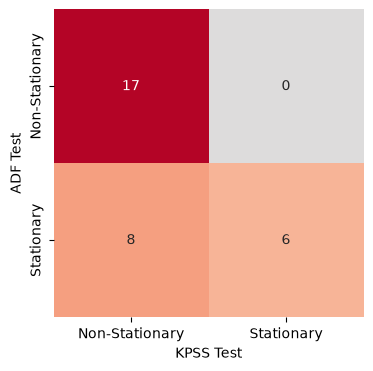

In [17]:
# Heatmap of number of features agreeing and disagreeing between ADF and KPSS tests

plot_data = stationarity_results.groupby(['adf_stationary', 'kpss_stationary']).size().unstack(fill_value=0)
plot_data = plot_data.rename(index={True: 'Stationary', False: 'Non-Stationary'},
                              columns={True: 'Stationary', False: 'Non-Stationary'}) # relabel True/False as stationary/non-stationary

plt.figure(figsize=(4, 4))
sns.heatmap(plot_data, annot=True, cmap='coolwarm', center=0, cbar=False)
plt.xlabel('KPSS Test')
plt.ylabel('ADF Test')
plt.savefig(f"Images/Stationarity Heatmap.png", bbox_inches='tight', dpi=300)
plt.show()


In [18]:
# Assign preliminary feature transformations based on stationarity results

"""
Check constant stationarity conclusion:
    If constant stationary, then no adjustment needed.
    If inconclusive, then inspect p-values, graph, and intuition to decide on adjustment.
    If constant non-stationary, then log-return if price or difference if other.
"""
prices = ['DXY Curncy', "GT10 Govt", "SPX Index", "ES1 Index", "MXWO Index", "CL1 Comdty", "CO1 Comdty"] # price series (will be log-returned rather than differenced)

Transformations = dict.fromkeys(All_Features_Weekly.columns)

for row in stationarity_results.itertuples():
    if row.conclusion == 'Stationary':
        Transformations[row.Index] = "No transformation"
        continue
    elif row.conclusion == 'Non-stationary (unit root)':
        if row.Index in prices:
            Transformations[row.Index] = 'Log-returns'
        else:
            Transformations[row.Index] = 'Difference'
    else:
        Transformations[row.Index] = 'Inconclusive'
print("Number of inconclusive features:", sum(1 for transformation in Transformations.values() if transformation == 'Inconclusive'))
display(Transformations)

Number of inconclusive features: 8


{'VIX Index': 'No transformation',
 'MOVE Index': 'Inconclusive',
 'DXY Curncy': 'Inconclusive',
 'FDTR Index': 'Difference',
 'FDFD Index': 'Difference',
 'GT10 Govt': 'Log-returns',
 'NAPMPMI Index': 'No transformation',
 'SPX Index': 'Log-returns',
 'ES1 Index': 'Log-returns',
 'MXWO Index': 'Log-returns',
 'CL1 Comdty': 'Log-returns',
 'CO1 Comdty': 'Log-returns',
 'CRK321M1 Index': 'Difference',
 'CLCO1 Index': 'Difference',
 'DSUPKERO Index': 'No transformation',
 'DSUPGASL Index': 'Inconclusive',
 'DOEICRP2 Index': 'Difference',
 'BAKETOT Index': 'Inconclusive',
 'BAKEGAS Index': 'Difference',
 'DOESCRUD Index': 'Difference',
 'DOESCROK Index': 'Difference',
 'DSUPCRUD Index': 'Difference',
 'DOEPGRIN Index': 'Inconclusive',
 'DOEPPERC Index': 'Inconclusive',
 'DSUPDIST Index': 'No transformation',
 'EUR Curncy': 'Inconclusive',
 'IP Index': 'Difference',
 'CAD Curncy': 'Difference',
 'INJCJC Index': 'No transformation',
 'EPUSTOT Index': 'Inconclusive',
 'CL1 H/L': 'No transfor

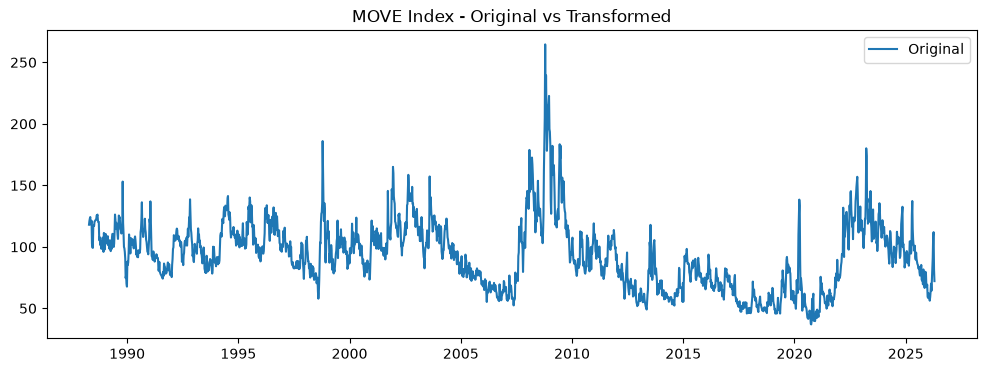

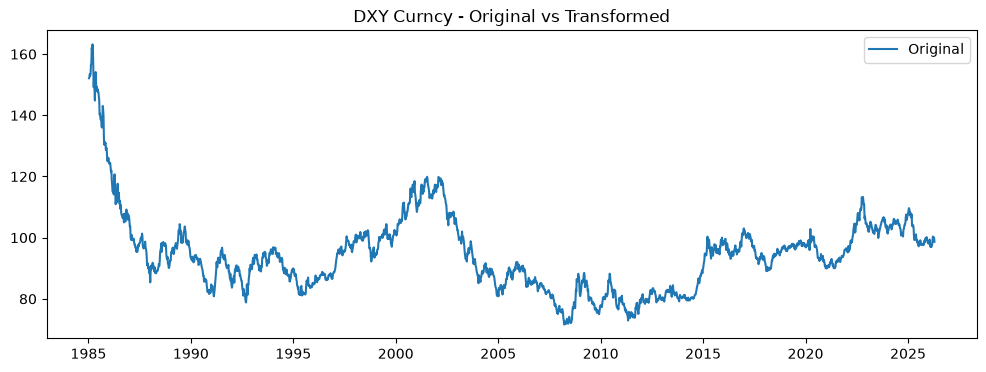

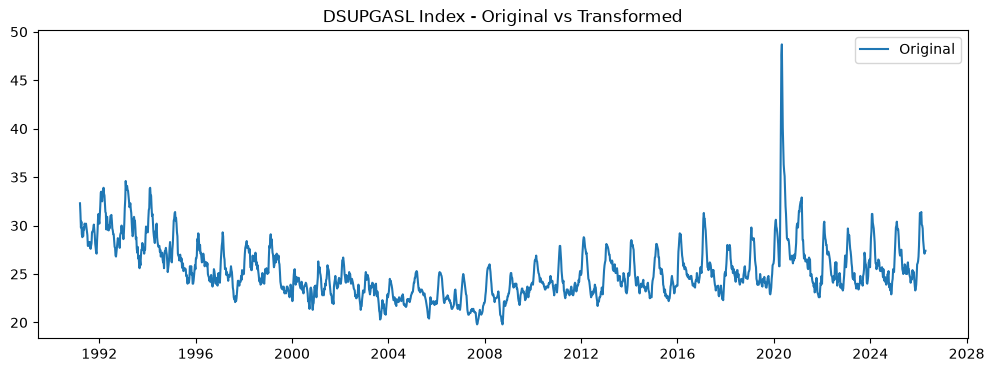

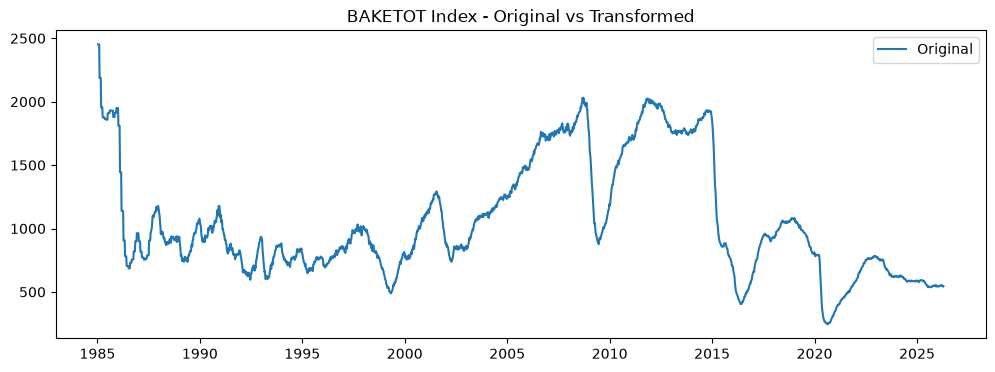

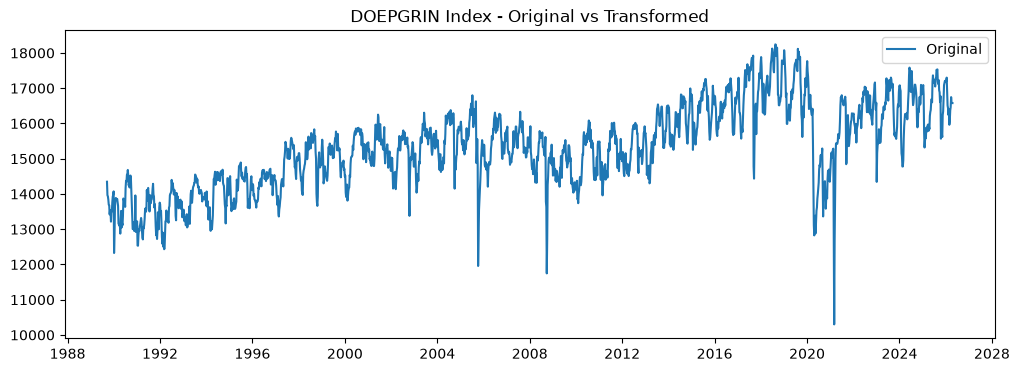

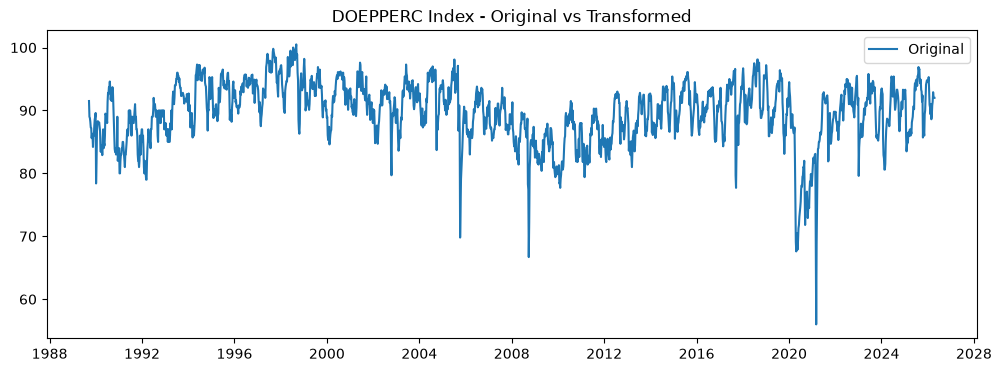

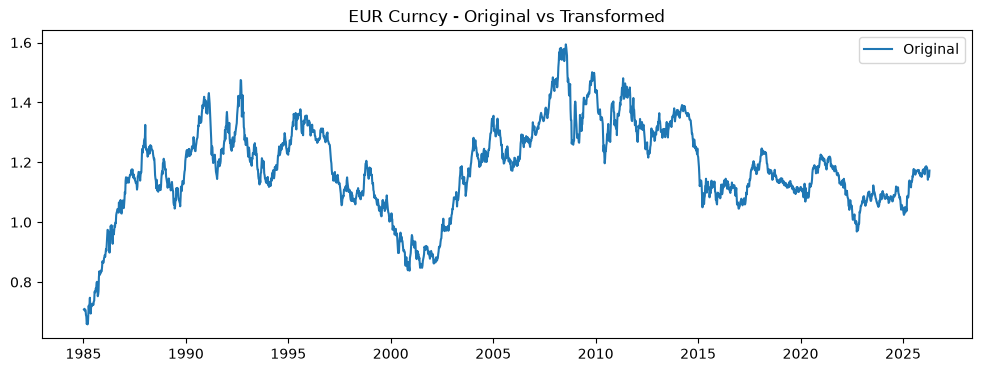

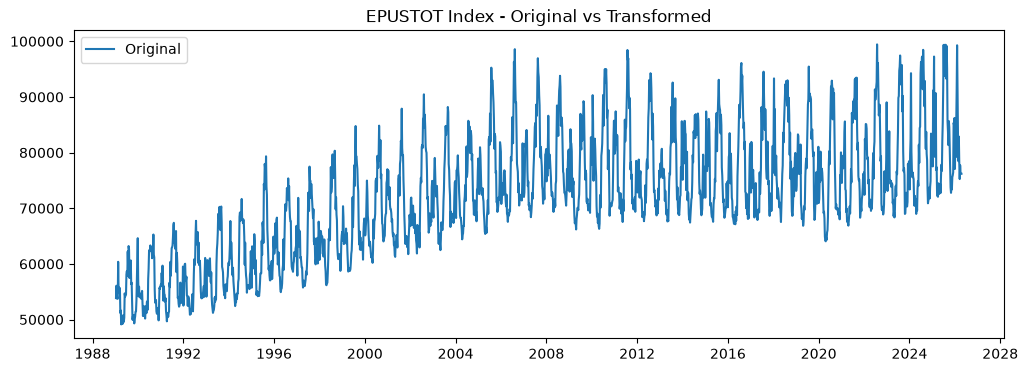

In [19]:
# Plots for features with inconclusive stationarity results
for feature in Transformations:
    if Transformations[feature] == 'Inconclusive':
        plt.figure(figsize=(12,4))
        plt.plot(All_Features_Weekly[feature], label='Original')
        plt.title(f"{feature} - Original vs Transformed")
        plt.legend()
    plt.show()

In [20]:
# Assign transformations for features with inconclusive stationarity results based on domain knowledge, inspection of the graphs, an inspection of p-values
Transformations["MOVE Index"] = "No transformation"
Transformations["DXY Curncy"] = "No transformation"
Transformations["DSUPGASL Index"] = "No transformation"
Transformations["BAKETOT Index"] = "Difference"
Transformations["DOEPGRIN Index"] = "Difference"
Transformations["DOEPPERC Index"] = "No transformation"
Transformations["EUR Curncy"] = "No transformation"
Transformations["EPUSTOT Index"] = "Difference"
display(Transformations)

if any (transformation == 'Inconclusive' for transformation in Transformations.values()):
    print(f"Some transformations still inconclusive: {', '.join([key for key, value in Transformations.items() if value == 'Inconclusive'])}")
else:
    print("All transformations confirmed.")


{'VIX Index': 'No transformation',
 'MOVE Index': 'No transformation',
 'DXY Curncy': 'No transformation',
 'FDTR Index': 'Difference',
 'FDFD Index': 'Difference',
 'GT10 Govt': 'Log-returns',
 'NAPMPMI Index': 'No transformation',
 'SPX Index': 'Log-returns',
 'ES1 Index': 'Log-returns',
 'MXWO Index': 'Log-returns',
 'CL1 Comdty': 'Log-returns',
 'CO1 Comdty': 'Log-returns',
 'CRK321M1 Index': 'Difference',
 'CLCO1 Index': 'Difference',
 'DSUPKERO Index': 'No transformation',
 'DSUPGASL Index': 'No transformation',
 'DOEICRP2 Index': 'Difference',
 'BAKETOT Index': 'Difference',
 'BAKEGAS Index': 'Difference',
 'DOESCRUD Index': 'Difference',
 'DOESCROK Index': 'Difference',
 'DSUPCRUD Index': 'Difference',
 'DOEPGRIN Index': 'Difference',
 'DOEPPERC Index': 'No transformation',
 'DSUPDIST Index': 'No transformation',
 'EUR Curncy': 'No transformation',
 'IP Index': 'Difference',
 'CAD Curncy': 'Difference',
 'INJCJC Index': 'No transformation',
 'EPUSTOT Index': 'Difference',
 'CL1

All transformations confirmed.


In [21]:
# Table showing stationarity test p-values and assigned transformations - for appendix
stationarity_and_transformations = stationarity_results[["adf_pval","kpss_pval"]].copy()
stationarity_and_transformations['Transformation'] = stationarity_and_transformations.index.map(Transformations)
stationarity_and_transformations.round(3)

,adf_pval,kpss_pval,Transformation
feature,,,
VIX Index,0.000,0.100,No transformation
MOVE Index,0.000,0.010,No transformation
DXY Curncy,0.000,0.010,No transformation
FDTR Index,0.129,0.010,Difference
FDFD Index,0.171,0.010,Difference
GT10 Govt,0.065,0.010,Log-returns
NAPMPMI Index,0.001,0.100,No transformation
SPX Index,1.000,0.010,Log-returns
ES1 Index,0.999,0.010,Log-returns


In [22]:
# Apply transformations based on the assigned transformations
All_Features_Weekly_Transformed = All_Features_Weekly.copy()
for feature in Transformations:
    if feature not in All_Features_Weekly.columns:
        continue
    elif Transformations[feature] == "No transformation":
        continue
    elif Transformations[feature] == "Log-returns":
        All_Features_Weekly_Transformed[feature] = log_return(All_Features_Weekly[feature], All_Features_Weekly[feature].shift(1))
    elif Transformations[feature] == "Difference":
        All_Features_Weekly_Transformed[feature] = All_Features_Weekly[feature].diff()
    else:
        print(f"{feature}: Transformation unknown, no transformation applied.")

In [23]:
# Re-run stationarity tests on transformed features to confirm stationarity
warnings.filterwarnings('ignore')  # KPSS throws InterpolationWarning for p-values at boundaries
Stationarity_results_2 = []
for col in All_Features_Weekly_Transformed.columns:
    Stationarity_results_2.append(stationarity_tests(All_Features_Weekly_Transformed[col], name=col))
Stationarity_results_2 = pd.DataFrame(Stationarity_results_2).set_index('feature')
display(Stationarity_results_2[["conclusion"]])

,conclusion
feature,
VIX Index,Stationary
MOVE Index,"Inconclusive (ADF rejects unit root, KPSS reje..."
DXY Curncy,"Inconclusive (ADF rejects unit root, KPSS reje..."
FDTR Index,Stationary
FDFD Index,Stationary
GT10 Govt,Stationary
NAPMPMI Index,Stationary
SPX Index,Stationary
ES1 Index,Stationary


### Feature selection

In [24]:
# Ensure feature selection is done on the training set only, to avoid data leakage into the test set
Test_set_start = '2020-01-01'
Feature_Selection_Data = All_Features_Weekly_Transformed[:Test_set_start]

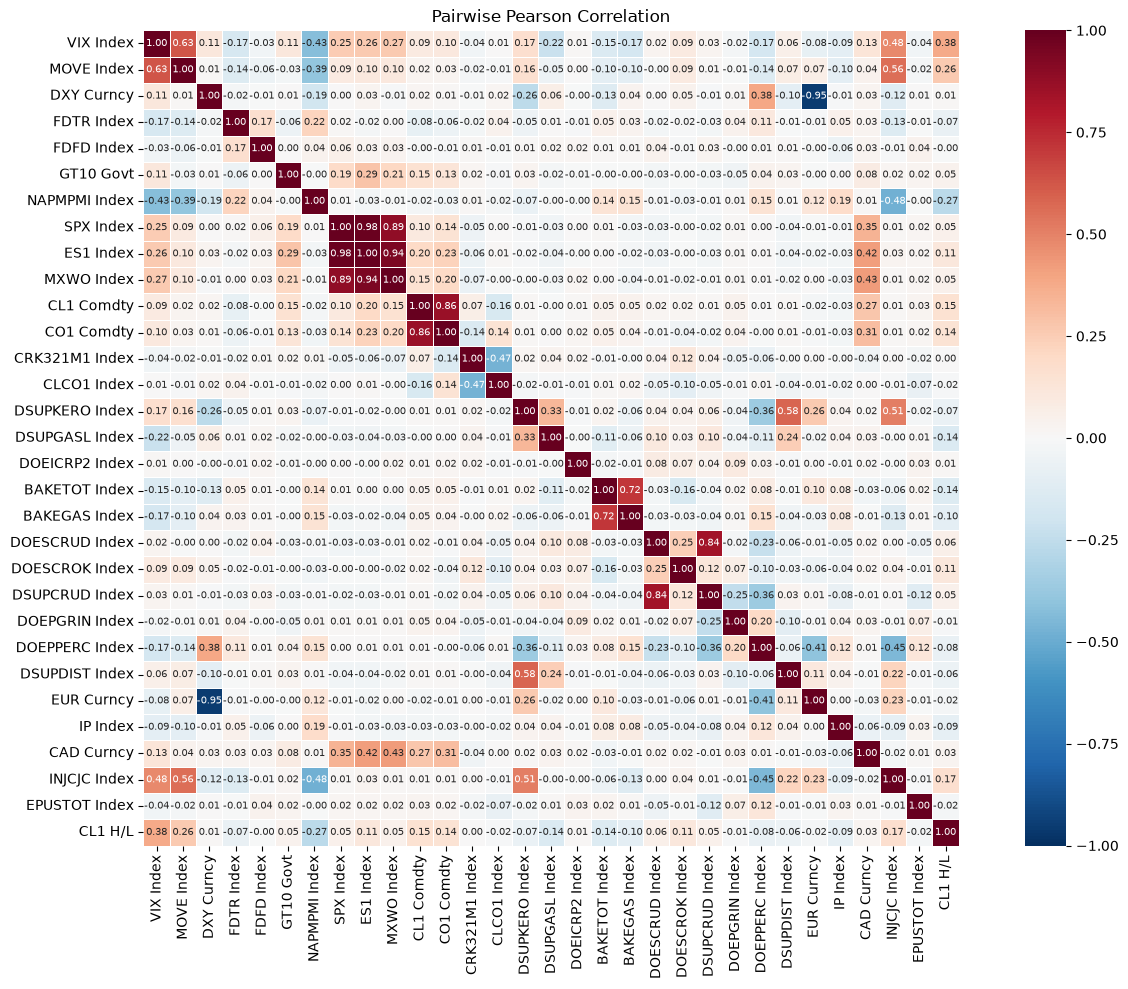

[('DXY Curncy', 'EUR Curncy', np.float64(-0.9548445964740482)),
 ('SPX Index', 'ES1 Index', np.float64(0.9848963079005586)),
 ('SPX Index', 'MXWO Index', np.float64(0.8877300313099182)),
 ('ES1 Index', 'MXWO Index', np.float64(0.9401527693225049)),
 ('CL1 Comdty', 'CO1 Comdty', np.float64(0.8612599168556483)),
 ('BAKETOT Index', 'BAKEGAS Index', np.float64(0.7169955058074924)),
 ('DOESCRUD Index', 'DSUPCRUD Index', np.float64(0.8400230987800257))]

In [25]:
# Pairwise correlations between features
correlation_matrix = Feature_Selection_Data.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Pairwise Pearson Correlation')
plt.tight_layout()
plt.show()

# Highly correlated pairs (|corr| > 0.7)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))
display(high_corr_pairs)

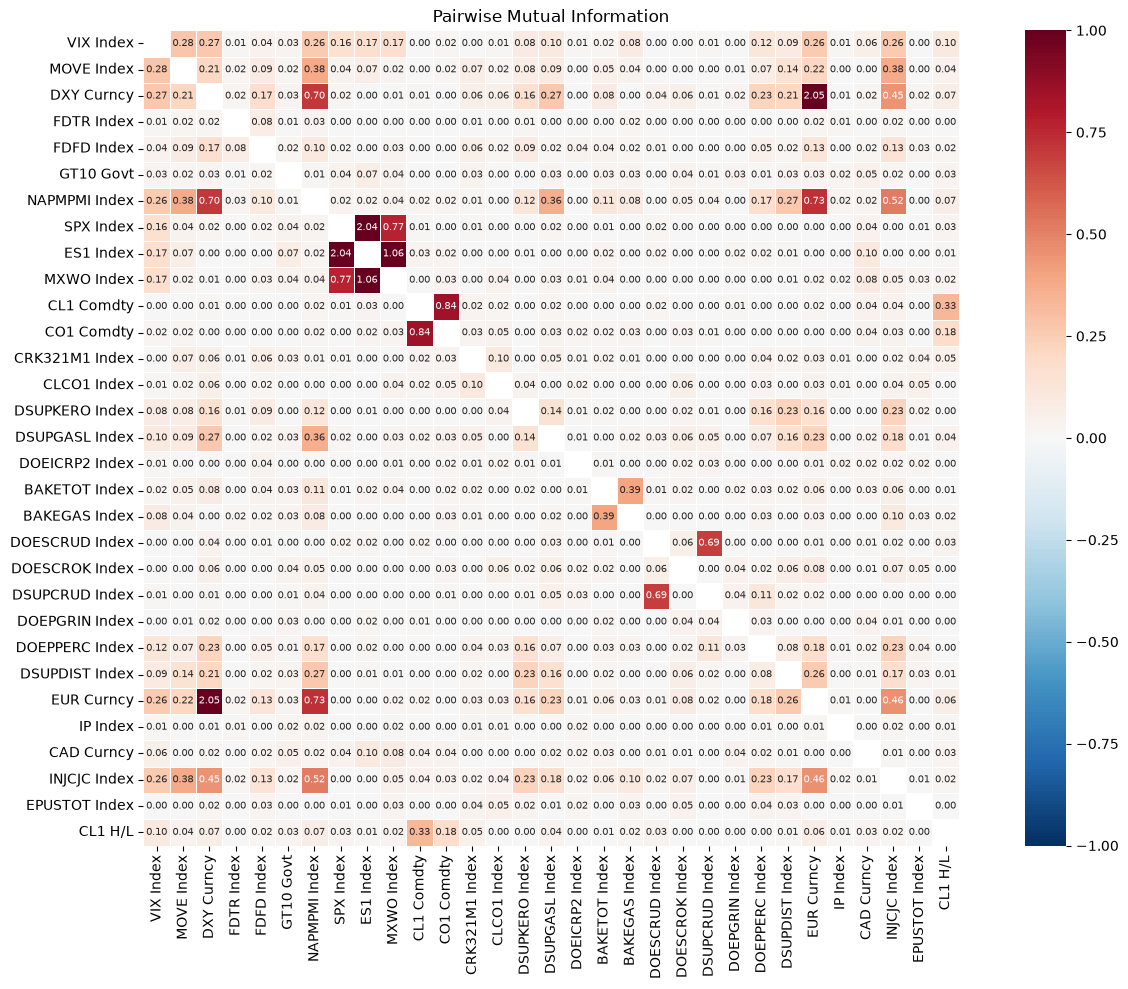

[('DXY Curncy', 'NAPMPMI Index', np.float64(0.7031790023119728)),
 ('DXY Curncy', 'EUR Curncy', np.float64(2.050701588432078)),
 ('NAPMPMI Index', 'EUR Curncy', np.float64(0.7294865477633077)),
 ('SPX Index', 'ES1 Index', np.float64(2.0377259411698923)),
 ('SPX Index', 'MXWO Index', np.float64(0.7710459986596705)),
 ('ES1 Index', 'MXWO Index', np.float64(1.06278039401731)),
 ('CL1 Comdty', 'CO1 Comdty', np.float64(0.8449892086321542)),
 ('DOESCRUD Index', 'DSUPCRUD Index', np.float64(0.6875390825931591))]

In [26]:
# Pairwise mutual information between features
mi_matrix = pd.DataFrame(index=Feature_Selection_Data.columns, columns=Feature_Selection_Data.columns, dtype=float)
for i in range(len(mi_matrix.columns)):
    for j in range(i+1, len(mi_matrix.columns)):
        pair = pd.concat([Feature_Selection_Data[Feature_Selection_Data.columns[i]], Feature_Selection_Data[Feature_Selection_Data.columns[j]]], axis=1).dropna()
        mi = mutual_info_regression(pair.iloc[:, 0].values.reshape(-1, 1), pair.iloc[:, 1].values, discrete_features=False)
        mi_matrix.loc[Feature_Selection_Data.columns[i], Feature_Selection_Data.columns[j]] = mi[0]
        mi_matrix.loc[Feature_Selection_Data.columns[j], Feature_Selection_Data.columns[i]] = mi[0]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    mi_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Pairwise Mutual Information')
plt.tight_layout()
plt.show()

# High mutual information pairs (MI > 0.6)
high_mi_pairs = []
for i in range(len(mi_matrix.columns)):
    for j in range(i+1, len(mi_matrix.columns)):
        if mi_matrix.iloc[i, j] > 0.6:
            high_mi_pairs.append((mi_matrix.columns[i], mi_matrix.columns[j], mi_matrix.iloc[i, j]))
display(high_mi_pairs)

In [27]:
# Correlation and mutual information with target

target_corr = Feature_Selection_Data.corrwith(Target_weekly_ret)

target_mi = []
for col in Feature_Selection_Data.columns:
    pair = pd.concat([Feature_Selection_Data[col], Target_weekly_ret], axis=1).dropna()
    mi = mutual_info_regression(pair.iloc[:, 0].values.reshape(-1, 1), pair.iloc[:, 1].values, n_neighbors=5)
    target_mi.append((col, target_corr[col], mi[0]))
    
# sort by absolute correlation
target_mi_df = pd.DataFrame(target_mi, columns=['feature', 'correlation_with_target', 'mutual_info_with_target'])
target_mi_df = target_mi_df.set_index('feature').sort_values(by='correlation_with_target', key=lambda x: x.abs(), ascending=False)
display(target_mi_df)

,correlation_with_target,mutual_info_with_target
feature,,
DOESCRUD Index,-0.079978,0.000000
IP Index,0.077412,0.000000
DOESCROK Index,-0.066092,0.000000
DSUPCRUD Index,-0.058793,0.019654
VIX Index,-0.056544,0.014691
DSUPKERO Index,-0.054344,0.002610
DSUPDIST Index,-0.045813,0.000000
BAKEGAS Index,0.043051,0.000000
INJCJC Index,-0.042563,0.033480


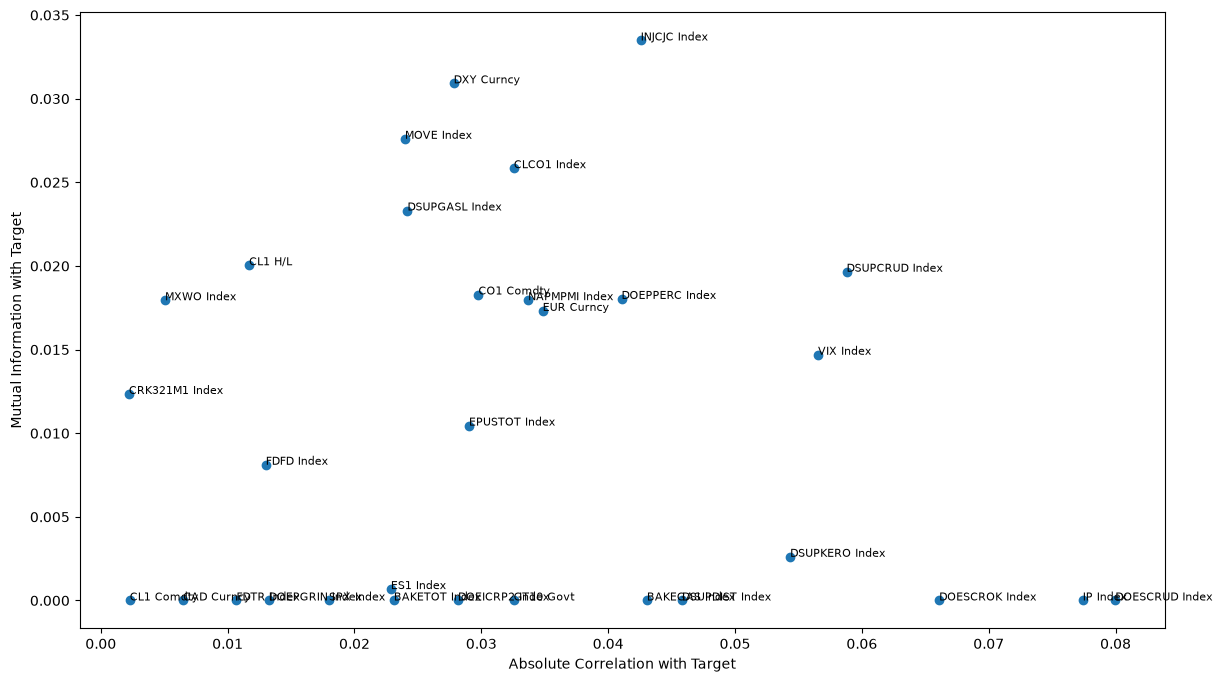

In [28]:
# Scatter plot of absolute correlation with target against mutual information with target
plt.figure(figsize=(14, 8))
plt.scatter(x=target_mi_df['correlation_with_target'].abs(), y=target_mi_df['mutual_info_with_target'])
plt.xlabel('Absolute Correlation with Target')
plt.ylabel('Mutual Information with Target')
for i, feature in enumerate(target_mi_df.index):
    plt.annotate(feature, (target_mi_df['correlation_with_target'].abs().iloc[i], target_mi_df['mutual_info_with_target'].iloc[i]), fontsize=8)
plt.show()

In [29]:
# Function to find correlated features using heirarchical clustering and connected components in a graph
def find_correlated_features(pairs, all_features):
    G = nx.Graph()
    G.add_nodes_from(all_features)
    for f1, f2, score in pairs:
        G.add_edge(f1, f2, weight=score)
    
    # Connected components = correlated clusters
    groups = [sorted(c) for c in nx.connected_components(G) if len(c) > 1]
    
    print(f"Found {len(groups)} correlated groups:\n")
    for i, group in enumerate(groups, 1):
        print(f"Group {i}:")
        for feat in group:
            print(f"  - {feat}")
        # Show pairwise scores within group
        for f1 in group:
            for f2 in group:
                if f1 < f2 and G.has_edge(f1, f2):
                    print(f"    {f1} <-> {f2}: {G[f1][f2]['weight']:.4f}")
        print()
    
    return groups

# High correlation groups
corr_groups = find_correlated_features(high_corr_pairs, Feature_Selection_Data.columns)

# High mutual information groups
mi_groups = find_correlated_features(high_mi_pairs, Feature_Selection_Data.columns)

Found 5 correlated groups:

Group 1:
  - DXY Curncy
  - EUR Curncy
    DXY Curncy <-> EUR Curncy: -0.9548

Group 2:
  - ES1 Index
  - MXWO Index
  - SPX Index
    ES1 Index <-> MXWO Index: 0.9402
    ES1 Index <-> SPX Index: 0.9849
    MXWO Index <-> SPX Index: 0.8877

Group 3:
  - CL1 Comdty
  - CO1 Comdty
    CL1 Comdty <-> CO1 Comdty: 0.8613

Group 4:
  - BAKEGAS Index
  - BAKETOT Index
    BAKEGAS Index <-> BAKETOT Index: 0.7170

Group 5:
  - DOESCRUD Index
  - DSUPCRUD Index
    DOESCRUD Index <-> DSUPCRUD Index: 0.8400

Found 4 correlated groups:

Group 1:
  - DXY Curncy
  - EUR Curncy
  - NAPMPMI Index
    DXY Curncy <-> EUR Curncy: 2.0507
    DXY Curncy <-> NAPMPMI Index: 0.7032
    EUR Curncy <-> NAPMPMI Index: 0.7295

Group 2:
  - ES1 Index
  - MXWO Index
  - SPX Index
    ES1 Index <-> MXWO Index: 1.0628
    ES1 Index <-> SPX Index: 2.0377
    MXWO Index <-> SPX Index: 0.7710

Group 3:
  - CL1 Comdty
  - CO1 Comdty
    CL1 Comdty <-> CO1 Comdty: 0.8450

Group 4:
  - DOESCRUD

In [30]:
# Final feature selection
features_to_keep = ["DSUPGASL Index", "DOESCRUD Index", "CL1 H/L", "VIX Index", "CL1 Comdty", "NAPMPMI Index", "IP Index", "DSUPKERO Index", "EPUSTOT Index", 'GT10 Govt', 'DOESCROK Index', 'DOEPGRIN Index', 'DOEPPERC Index', 'CRK321M1 Index', 'BAKETOT Index', "BAKEGAS Index"]

features_to_drop = [f for f in Feature_Selection_Data.columns if f not in features_to_keep]    
print(f"Features to drop: {sorted(features_to_drop)}")
All_Features_Weekly_Transformed_Filtered = All_Features_Weekly_Transformed.drop(columns=features_to_drop)
display(All_Features_Weekly_Transformed_Filtered)
features = All_Features_Weekly_Transformed_Filtered.columns.tolist()
print(features)

Features to drop: ['CAD Curncy', 'CLCO1 Index', 'CO1 Comdty', 'DOEICRP2 Index', 'DSUPCRUD Index', 'DSUPDIST Index', 'DXY Curncy', 'ES1 Index', 'EUR Curncy', 'FDFD Index', 'FDTR Index', 'INJCJC Index', 'MOVE Index', 'MXWO Index', 'SPX Index']


,VIX Index,GT10 Govt,NAPMPMI Index,CL1 Comdty,CRK321M1 Index,DSUPKERO Index,DSUPGASL Index,BAKETOT Index,BAKEGAS Index,DOESCRUD Index,DOESCROK Index,DOEPGRIN Index,DOEPPERC Index,IP Index,EPUSTOT Index,CL1 H/L
Date,,,,,,,,,,,,,,,,
1985-01-11,NaN,NaN,50.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.047693
1985-01-18,NaN,0.002849,50.6,-0.023161,NaN,NaN,NaN,0.0,NaN,4184.0,NaN,NaN,NaN,0.0000,NaN,0.013281
1985-01-25,NaN,0.014017,50.6,0.003499,NaN,NaN,NaN,0.0,NaN,2401.0,NaN,NaN,NaN,0.0000,NaN,0.019328
1985-02-01,NaN,0.029540,50.6,0.016886,NaN,NaN,NaN,0.0,NaN,-8590.0,NaN,NaN,NaN,0.0000,NaN,0.028116
1985-02-08,NaN,-0.021971,50.3,-0.057334,NaN,NaN,NaN,-264.0,NaN,-8458.0,NaN,NaN,NaN,-0.0094,NaN,0.058127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,27.19,-0.032790,52.4,-0.082426,5.235,26.5,27.9,2.0,1.0,6156.0,944.0,93.0,91.4,0.0000,-2886.0,0.167939
2026-03-27,26.78,-0.024020,52.4,0.003959,16.787,27.6,27.4,-1.0,-2.0,6926.0,3421.0,284.0,92.9,0.0000,2470.0,0.050266
2026-04-03,31.05,-0.010894,52.4,-0.013336,-9.511,27.1,27.1,-9.0,-4.0,5451.0,520.0,-155.0,92.1,0.0000,-1555.0,0.122751


['VIX Index', 'GT10 Govt', 'NAPMPMI Index', 'CL1 Comdty', 'CRK321M1 Index', 'DSUPKERO Index', 'DSUPGASL Index', 'BAKETOT Index', 'BAKEGAS Index', 'DOESCRUD Index', 'DOESCROK Index', 'DOEPGRIN Index', 'DOEPPERC Index', 'IP Index', 'EPUSTOT Index', 'CL1 H/L']


## Input Data

### Date Range

In [31]:
# Set overall start date based on the earliest start date of the remaining features
start_dates = All_Features_Weekly_Transformed_Filtered.apply(lambda col: col.first_valid_index()) # first non-NaN observation for each feature
start_dates = start_dates.rename("Start Date").to_frame().sort_values(by="Start Date", ascending=False)
display(start_dates)
Start_date = start_dates["Start Date"].max()
End_date = All_Features_Weekly_Transformed_Filtered.last_valid_index()
print(f"Final data range after filtering: {Start_date} to {End_date}")
print(f"Number of observations after filtering: {(All_Features_Weekly_Transformed_Filtered.index >= Start_date).sum()}")

All_Features_Weekly_Transformed_Filtered_Truncated = All_Features_Weekly_Transformed_Filtered[Start_date:End_date]
Target_weekly_ret_Truncated = Target_weekly_ret[Start_date:End_date]

,Start Date
DOESCROK Index,2004-04-23
DSUPKERO Index,1991-03-15
DSUPGASL Index,1991-03-15
VIX Index,1990-01-12
DOEPGRIN Index,1989-09-22
DOEPPERC Index,1989-09-15
EPUSTOT Index,1989-01-20
BAKEGAS Index,1987-07-31
CRK321M1 Index,1986-12-12
GT10 Govt,1985-01-18


Final data range after filtering: 2004-04-23 00:00:00 to 2026-04-17 00:00:00
Number of observations after filtering: 1148


In [32]:
Final_features = pd.DataFrame(All_Features_Weekly_Transformed_Filtered_Truncated.columns).set_index(0)
Final_features.index.name = "Feature"
Final_features["Index Description"] = Final_features.index.map(Feature_Name_Map)
Final_features

,Index Description
Feature,
VIX Index,VIX Index
GT10 Govt,10Y Treasury Yield
NAPMPMI Index,US Purchasing Managers Index
CL1 Comdty,WTI Price
CRK321M1 Index,321 Crack Spread
DSUPKERO Index,Kerosene Days of Supply
DSUPGASL Index,Gasoline Days of Supply
BAKETOT Index,Active US Oil & Gas Rigs
BAKEGAS Index,Active US Gas Rigs


In [33]:
save_data = False # Set to True to save the final input and target data to CSV files

if save_data:
    All_Features_Weekly_Transformed_Filtered_Truncated.to_csv("Outputs/Data/Input Data.csv")
    Target_weekly_ret_Truncated.to_csv("Outputs/Data/Target Data.csv")

### Test-train split

In [34]:
# Create 2 test sets based on cut-off dates
Test1_date = pd.Timestamp('2020-01-01')
Test2_date = pd.Timestamp('2024-01-01')
End_date = pd.Timestamp('2025-12-31')

X_Train = All_Features_Weekly_Transformed_Filtered_Truncated[All_Features_Weekly_Transformed_Filtered_Truncated.index < Test1_date]
X_Test1 = All_Features_Weekly_Transformed_Filtered_Truncated[(All_Features_Weekly_Transformed_Filtered_Truncated.index >= Test1_date) & (All_Features_Weekly_Transformed_Filtered_Truncated.index < Test2_date)]
X_Test2 = All_Features_Weekly_Transformed_Filtered_Truncated[(All_Features_Weekly_Transformed_Filtered_Truncated.index >= Test2_date) & (All_Features_Weekly_Transformed_Filtered_Truncated.index <= End_date)]

Y_Train = Target_weekly_ret_Truncated[Target_weekly_ret_Truncated.index < Test1_date]
Y_Test1 = Target_weekly_ret_Truncated[(Target_weekly_ret_Truncated.index >= Test1_date) & (Target_weekly_ret_Truncated.index < Test2_date)]
Y_Test2 = Target_weekly_ret_Truncated[(Target_weekly_ret_Truncated.index >= Test2_date) & (Target_weekly_ret_Truncated.index <= End_date)]

print(f"Train features shape: {X_Train.shape}")
print(f"Test1 features shape: {X_Test1.shape}")
print(f"Test2 features shape: {X_Test2.shape}")

Train features shape: (819, 16)
Test1 features shape: (209, 16)
Test2 features shape: (104, 16)


In [35]:
# Check balance of target variable in train and test sets
print("Train target balance:", (Y_Train>0).astype(int).mean().round(4)*100, "%")
print("Test1 target balance:", (Y_Test1>0).astype(int).mean().round(4)*100, "%")
print("Test2 target balance:", (Y_Test2>0).astype(int).mean().round(4)*100, "%")

Train target balance: 51.4 %
Test1 target balance: 51.67 %
Test2 target balance: 47.12 %


In [36]:
# Rescale features using StandardScaler
scaler = StandardScaler()
X_Train_scaled = pd.DataFrame(scaler.fit_transform(X_Train), index=X_Train.index, columns=X_Train.columns) # Only fit on training data, but apply to all sets
X_Test1_scaled = pd.DataFrame(scaler.transform(X_Test1), index=X_Test1.index, columns=X_Test1.columns)
X_Test2_scaled = pd.DataFrame(scaler.transform(X_Test2), index=X_Test2.index, columns=X_Test2.columns)

# Models

## Model Definitions

In [37]:
def build_results_df(dates, actuals, preds, feature_names, shap_values=None,
                     lime_values=None, winit_values=None, tsmule_values=None):

    df = pd.DataFrame(index=dates)
    df.index.name = 'date'

    # Predictions
    df['Actual']        = actuals
    df['Pred']          = preds
    df['Pred_Dir'] = (np.sign(preds) > 0).astype(int)
    df['Correct']       = np.sign(preds) == np.sign(actuals)
    df['Abs Error'] = np.abs(df['Pred'] - df['Actual'])
    df['Squared Error'] = (df['Pred'] - df['Actual']) ** 2

    # SHAP
    if shap_values is not None:
        for i, f in enumerate(feature_names):
            df[f'shap__{f}'] = shap_values[:, i]

    # LIME (optional)
    if lime_values is not None:
        for i, f in enumerate(feature_names):
            df[f'lime__{f}'] = lime_values[:, i]

    # WinIT (LSTM only, optional)
    if winit_values is not None:
        for i, f in enumerate(feature_names):
            df[f'winit__{f}'] = winit_values[:, i]

    # TS-MULE (LSTM only, optional)
    if tsmule_values is not None:
        for i, f in enumerate(feature_names):
            df[f'tsmule__{f}'] = tsmule_values[:, i]

    return df


def display_results(performance_metrics, title="Results"):
    print(f"--- {title} ---")
    print(f"Directional Accuracy: {performance_metrics['Directional Accuracy']:.4f}")
    print(f"Directional Accuracy p-value: {performance_metrics['Dir Acc p-value']:.4f}")
    print(f"MSE: {performance_metrics['MSE']:.6f}")
    print(f"MAE: {performance_metrics['MAE']:.6f}")
    print(f"ROC-AUC: {performance_metrics['ROC-AUC']:.4f}")
    print(f"F1 Score: {performance_metrics['F1 Score']:.4f}")
    print("Confusion Matrix:")
    print(performance_metrics["Confusion Matrix"])
    print("Classification Report:")
    print(performance_metrics["Classification Report"])


def p_test(preds_dir, targets_dir, verbose=False):
    p = targets_dir.mean()
    n = len(preds_dir)          # total predictions
    k = sum(preds_dir == targets_dir)  # correct
    if verbose:
        print(f"{k} correct out of {n} predictions.")

    p_val = binomtest(k, n, p=p, alternative='greater')
    return p_val

### OLS

In [38]:
def train_ols(X_Train_ols, Y_Train, OLS_PARAMS):
    X_Train_scaled_const = sm.add_constant(X_Train_ols)
    model = sm.OLS(Y_Train, X_Train_scaled_const).fit()
    return model

def evaluate_ols(ols_model, X, Y):
    X_const = sm.add_constant(X)
    preds = ols_model.predict(X_const)

    dir_preds   = (np.sign(preds)   > 0).astype(int)
    dir_targets = (np.sign(Y) > 0).astype(int)

    performance_metrics = {
        "MSE": mean_squared_error(Y, preds),
        "MAE": mean_absolute_error(Y, preds),
        "Directional Accuracy": accuracy_score(dir_targets, dir_preds),
        "ROC-AUC": roc_auc_score(dir_targets, preds),
        "F1 Score": f1_score(dir_targets, dir_preds, zero_division=0),
        "Confusion Matrix": confusion_matrix(dir_targets, dir_preds),
        "Classification Report": classification_report(dir_targets, dir_preds, target_names=["Down (0)", "Up (1)"], zero_division=0),
        "Dir Acc p-value": p_test(dir_preds, dir_targets).pvalue
    }

    return preds, dir_preds, performance_metrics

### XGBoost

In [39]:
# Function to train the XGBoost model
def train_xgb(X_Train_lagged, y_Train_lagged, XGB_PARAMS):

    xgb_kwargs = {
    'n_estimators':     XGB_PARAMS['n_estimators'],
    'max_depth':        XGB_PARAMS['max_depth'],
    'learning_rate':    XGB_PARAMS['learning_rate'],
    'subsample':        XGB_PARAMS['subsample'],
    'colsample_bytree': XGB_PARAMS['colsample_bytree'],
    }
    
    model = XGBRegressor(**xgb_kwargs)
    model.fit(X_Train_lagged, y_Train_lagged)
    return model

# Function to evaluate the XGBoost model
def evaluate_xgb(xgb_model, X_lagged, Y_lagged):
    preds = xgb_model.predict(X_lagged)

    dir_preds   = (np.sign(preds)   > 0).astype(int)
    dir_targets = (np.sign(Y_lagged) > 0).astype(int)

    performance_metrics = {
        "MSE": mean_squared_error(Y_lagged, preds),
        "MAE": mean_absolute_error(Y_lagged, preds),
        "Directional Accuracy": accuracy_score(dir_targets, dir_preds),
        "ROC-AUC": roc_auc_score(dir_targets, preds),
        "F1 Score": f1_score(dir_targets, dir_preds, zero_division=0),
        "Confusion Matrix": confusion_matrix(dir_targets, dir_preds),
        "Classification Report": classification_report(dir_targets, dir_preds, target_names=["Down (0)", "Up (1)"], zero_division=0),
        "Dir Acc p-value": p_test(dir_preds, dir_targets).pvalue
    }

    return preds, dir_preds, performance_metrics

### LSTM

In [40]:
# Function to create overlapping sequences for LSTM input
def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int):
    """Convert flat arrays into overlapping (X_seq, y) pairs."""
    X_seq, y_seq = [], []
    for i in range(len(y) - seq_len + 1):
        X_seq.append(X.iloc[i : i + seq_len])
        y_seq.append(y.iloc[i + seq_len - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    dates = X.index[seq_len - 1:]
    return X_seq, y_seq, dates

# Define the LSTM model class
class LSTMNet(nn.Module):
    """
    Stacked LSTM matching the Keras structure: Dropout applied after
    EVERY layer's output (including the final layer, before the Dense
    head), not just between layers as nn.LSTM(num_layers=...) would do.
    """
    def __init__(self, input_size: int, LSTM_PARAMS: dict):
        super().__init__()
        self.num_layers = LSTM_PARAMS['NUM_LAYERS']
        self.lstm_layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()

        in_size = input_size
        for _ in range(self.num_layers):
            self.lstm_layers.append(
                nn.LSTM(in_size, LSTM_PARAMS['HIDDEN_SIZE'], batch_first=True)
            )
            self.dropout_layers.append(nn.Dropout(LSTM_PARAMS['DROPOUT']))
            in_size = LSTM_PARAMS['HIDDEN_SIZE']

        self.fc = nn.Linear(LSTM_PARAMS['HIDDEN_SIZE'], 1)

    def forward(self, x):
        for lstm, drop in zip(self.lstm_layers, self.dropout_layers):
            x, _ = lstm(x)          # (batch, seq_len, hidden)
            x = drop(x)
        x = x[:, -1, :]              # equivalent to Keras return_sequences=False on last layer
        return self.fc(x).squeeze(-1)
# Function to build the LSTM model
def build_model(input_size: int, LSTM_PARAMS: dict, device=device) -> nn.Module:
    return LSTMNet(input_size, LSTM_PARAMS).to(device)

# Function to train the LSTM model
def train_lstm(X_train_seq, y_train_seq, LSTM_PARAMS, verbose=0, device=device):
    model = build_model(input_size=X_train_seq.shape[2], LSTM_PARAMS=LSTM_PARAMS, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # Keras validation_split (with shuffle=False) takes the LAST fraction
    # of the data, in original order — replicated here explicitly.
    n = len(X_train_seq)
    n_val = int(round(n * LSTM_PARAMS['VALIDATION_SPLIT']))
    n_train = n - n_val

    X_tr = torch.as_tensor(X_train_seq[:n_train], dtype=torch.float32, device=device)
    y_tr = torch.as_tensor(y_train_seq[:n_train], dtype=torch.float32, device=device)
    X_val = torch.as_tensor(X_train_seq[n_train:], dtype=torch.float32, device=device)
    y_val = torch.as_tensor(y_train_seq[n_train:], dtype=torch.float32, device=device)

    batch_size = LSTM_PARAMS['BATCH_SIZE']
    n_batches = int(np.ceil(n_train / batch_size))

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(LSTM_PARAMS['N_EPOCHS']):
        model.train()
        for b in range(n_batches):          # sequential batches — no shuffling, as required for time series
            start, end = b * batch_size, (b + 1) * batch_size
            xb, yb = X_tr[start:end], y_tr[start:end]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if verbose:
            print(f"Epoch {epoch + 1}: val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= LSTM_PARAMS['PATIENCE']:
                break

    if best_state is not None:               # restore_best_weights=True equivalent
        model.load_state_dict(best_state)

    return model

# Function to evaluate the LSTM model
def evaluate_lstm(lstm_model, X_seq, y_seq, device=device):
    lstm_model.eval()
    with torch.no_grad():
        X_t = torch.as_tensor(X_seq, dtype=torch.float32, device=device)
        preds = lstm_model(X_t).cpu().numpy().flatten()

    dir_preds = (np.sign(preds) > 0).astype(int)
    dir_targets = (np.sign(y_seq) > 0).astype(int)

    performance_metrics = {
        "MSE": mean_squared_error(y_seq, preds),
        "MAE": mean_absolute_error(y_seq, preds),
        "Directional Accuracy": accuracy_score(dir_targets, dir_preds),
        "ROC-AUC": roc_auc_score(dir_targets, preds),
        "F1 Score": f1_score(dir_targets, dir_preds, zero_division=0),
        "Confusion Matrix": confusion_matrix(dir_targets, dir_preds),
        "Classification Report": classification_report(
            dir_targets, dir_preds, target_names=["Down (0)", "Up (1)"], zero_division=0
        ),
        "Dir Acc p-value": p_test(dir_preds, dir_targets).pvalue
    }

    return preds, dir_preds, performance_metrics

### TabPFN

In [41]:
# Function to train the TabPFN model
def train_tabpfn(X_Train_lagged, y_Train_lagged, TABPFN_PARAMS):

    tabpfn_kwargs = {
        'fit_mode':     TABPFN_PARAMS['fit_mode'],
    }

    model = TabPFNRegressor(**tabpfn_kwargs)
    model.fit(X_Train_lagged, y_Train_lagged)
    return model

# Function to evaluate the TabPFN model
def evaluate_tabpfn(tabpfn_model, X_lagged, Y_lagged):
    preds = tabpfn_model.predict(X_lagged)

    dir_preds   = (np.sign(preds)   > 0).astype(int)
    dir_targets = (np.sign(Y_lagged) > 0).astype(int)

    performance_metrics = {
        "MSE": mean_squared_error(Y_lagged, preds),
        "MAE": mean_absolute_error(Y_lagged, preds),
        "Directional Accuracy": accuracy_score(dir_targets, dir_preds),
        "ROC-AUC": roc_auc_score(dir_targets, preds),
        "F1 Score": f1_score(dir_targets, dir_preds, zero_division=0),
        "Confusion Matrix": confusion_matrix(dir_targets, dir_preds),
        "Classification Report": classification_report(dir_targets, dir_preds, target_names=["Down (0)", "Up (1)"], zero_division=0),
        "Dir Acc p-value": p_test(dir_preds, dir_targets).pvalue
    }

    return preds, dir_preds, performance_metrics

# Wrapper class for TabPFN model to handle scaled input features
class TabPFN_SCALED_WRAPPER(nn.Module):
    def forward(self, x):
        x_raw = scaler.inverse_transform(x)
        return TABPFN_MODEL.predict(x_raw)

## HPO

In [197]:
#### HPO Controls ###
use_saved_params = True # Set to True to use saved parameters, False to run hyperparameter search
save_new_params = False # Set to True to save new optimal parameters, False to skip saving

In [189]:
# Function to generate walk-forward folds for cross-validation using an expanding window approach
def gen_folds(X, Y, n_folds=5, min_train_size=200):
    """
    Yields (X_train, Y_train, X_val, Y_val) for each fold using an expanding window.
    Val windows are contiguous, non-overlapping blocks after min_train_size.
    """
    n = len(Y)
    val_block_size = (n - min_train_size) // n_folds

    for fold in range(n_folds):
        train_end = min_train_size + fold * val_block_size
        val_start = train_end
        val_end = val_start + val_block_size if fold < n_folds - 1 else n

        X_train, Y_train = X.iloc[:train_end], Y.iloc[:train_end]
        X_val, Y_val     = X.iloc[val_start:val_end], Y.iloc[val_start:val_end]

        if len(X_val) == 0:
            continue

        yield X_train, Y_train, X_val, Y_val


# Function to perform hyperparameter optimization (HPO) using cross-validation
def HPO(param_grid, prep_fn, train_fn, eval_fn,
                     X, Y, n_folds=5, min_train_size=200, verbose=False):
    """
    param_grid : dict of hyperparameter lists, e.g. {'max_depth': [3,5], ...}
    prep_fn    : (X_train, Y_train, X_val, Y_val, params) -> (X_tr, Y_tr, X_v, Y_v)
                 handles lagging/sequencing/scaling specific to the model
    train_fn   : (X_tr, Y_tr, params) -> model
    eval_fn    : (model, X_v, Y_v) -> performance_metrics dict (from your evaluate_xgb/evaluate_lstm/evaluate_tabpfn)

    Returns a results DataFrame, one row per combo, with mean±std metrics across folds.
    """
    all_results = []
    grid = list(ParameterGrid(param_grid))
    print(f"Running HPO for {len(grid)} hyperparameter combinations with {n_folds} folds each...")

    for i, combo in enumerate(grid):
        fold_metrics = []

        for X_train, Y_train, X_val, Y_val in gen_folds(X, Y, n_folds, min_train_size):
            X_train, Y_train, X_val, Y_val = prep_fn(X_train, Y_train, X_val, Y_val, combo) # prep data
            model = train_fn(X_train, Y_train, combo) # train model
            _, _, metrics = eval_fn(model, X_val, Y_val) #evaluate model

            fold_metrics.append({
                'MSE': metrics['MSE'],
                'Directional Accuracy': metrics['Directional Accuracy'],
            })

        fold_df = pd.DataFrame(fold_metrics)
        result_row = {
            **combo,
            'MSE_mean': fold_df['MSE'].mean(),
            'MSE_std': fold_df['MSE'].std(),
            'DirAcc_mean': fold_df['Directional Accuracy'].mean(),
            'DirAcc_std': fold_df['Directional Accuracy'].std(),
            'n_folds': len(fold_df),
        }
        all_results.append(result_row)

        if verbose:
            print(f"[{i+1}/{len(grid)}] {combo} -> "
                  f"MSE={result_row['MSE_mean']:.6f}, DirAcc={result_row['DirAcc_mean']:.4f}")
            
    results = pd.DataFrame(all_results)

    # Identify optimal hyperparameters
    best_row = results['DirAcc_mean'].idxmax()
    optimal_params_dict = {p: results.loc[best_row, p].item() if isinstance(results.loc[best_row, p], (np.floating, np.integer, np.bool_)) else results.loc[best_row, p] for p in param_grid.keys()}
    print(f"Optimal hyperparameters based on DirAcc_mean: {optimal_params_dict}")
    return results, optimal_params_dict

# Function to save optimal hyperparameters to a JSON file
def save_optimal_params(best_params, path):
    with open(path, 'w') as f:
        json.dump(best_params, f, indent=2)

### Load

In [190]:
# Load saved optimal hyperparameters and HPO results
if use_saved_params:
    with open('Outputs/HPO/Optimal Params XGBoost.json', 'r') as f:
        optimal_params_xgb = json.load(f)
        print("XGB Optimal Parameters", optimal_params_xgb)
    with open('Outputs/HPO/Optimal Params LSTM.json', 'r') as f:
        optimal_params_lstm = json.load(f)
        print("LSTM Optimal Parameters", optimal_params_lstm)
    with open('Outputs/HPO/Optimal Params TabPFN.json', 'r') as f:
        optimal_params_tabpfn = json.load(f)
        print("TabPFN Optimal Parameters", optimal_params_tabpfn)
    
    xgb_hpo_results = pd.read_csv('Outputs/HPO/HPO Results XGBoost.csv')
    lstm_hpo_results = pd.read_csv('Outputs/HPO/HPO Results LSTM.csv')
    tabpfn_hpo_results = pd.read_csv('Outputs/HPO/HPO Results TabPFN.csv')

### XGBoost

In [199]:
# Function to prepare data for XGBoost model (no pre-processing needed for XGBoost)
def prep_fn_xgb(X_train, Y_train, X_val, Y_val, params):
    return X_train, Y_train, X_val, Y_val

# Run HPO for XGBoost
if not use_saved_params:

    XGB_PARAM_GRID = {
        'n_estimators':     [100, 150, 200],
        'max_depth':        [3, 4, 5],
        'learning_rate':    [0.05],
        'subsample':        [0.8],
        'colsample_bytree': [0.8],
    }

    xgb_hpo_results, optimal_params_xgb = HPO(
        XGB_PARAM_GRID,
        prep_fn_xgb, train_xgb, evaluate_xgb,
        X_Train, Y_Train,
        n_folds=4, min_train_size=200, verbose=True
    )

<Axes: title={'center': 'XGBoost HPO: Directional Accuracy vs max_depth'}, xlabel='max_depth'>

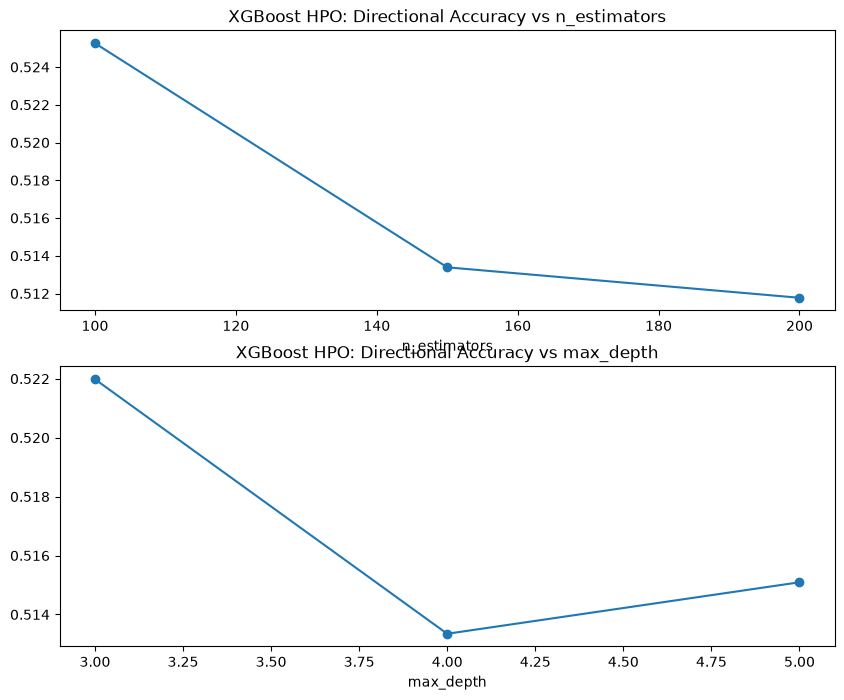

In [46]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
# look at trend over n_estimator values by averaging across all other hyperparameter combinations, also add error bars for std deviation
xgb_hpo_results.groupby('n_estimators')['DirAcc_mean'].mean().plot(marker='o', title='XGBoost HPO: Directional Accuracy vs n_estimators', ax=axs[0])
#xgb_hpo_results.groupby('n_estimators')['DirAcc_mean'].mean().plot(marker='o', yerr=xgb_hpo_results.groupby('n_estimators')['DirAcc_std'].mean(), title='XGBoost HPO: Directional Accuracy vs n_estimators', capsize=5, ax=axs[0])

#separate plots for each hyperparameter to visualize trends and error bars
# look at trend over max_depth values by averaging across all other hyperparameter combinations, also add error bars for std deviation
xgb_hpo_results.groupby('max_depth')['DirAcc_mean'].mean().plot(marker='o', title='XGBoost HPO: Directional Accuracy vs max_depth', ax=axs[1])
#xgb_hpo_results.groupby('max_depth')['DirAcc_mean'].mean().plot(marker='o', yerr=xgb_hpo_results.groupby('max_depth')['DirAcc_std'].mean(), title='XGBoost HPO: Directional Accuracy vs max_depth', capsize=5, ax=axs[1])

<Axes: xlabel='max_depth', ylabel='n_estimators'>

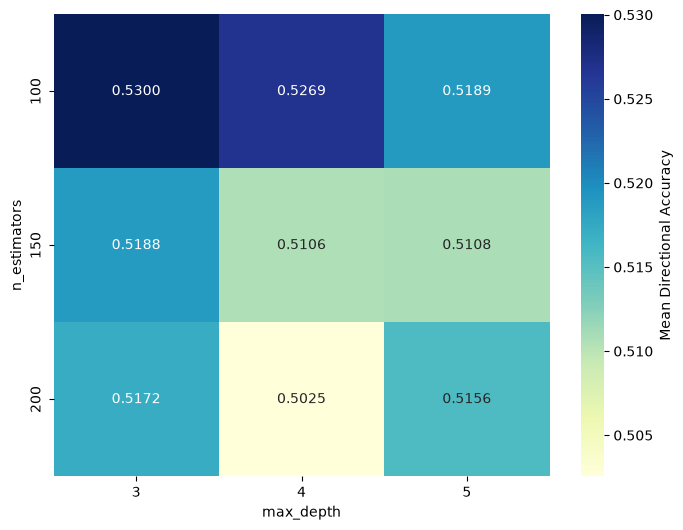

In [47]:
#heatmap of all hyperparameter combinations and their mean directional accuracy
lstm_hpo_pivot = xgb_hpo_results.pivot_table(index='n_estimators', columns='max_depth', values='DirAcc_mean')
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_hpo_pivot, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean Directional Accuracy'})

### LSTM

In [200]:
# Function to prepare data for LSTM model (scaling and sequencing)
def prep_fn_lstm(X_train, Y_train, X_val, Y_val, params):
    # scaling fit on this fold's train only — avoids leakage across folds
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

    X_train_seq, Y_train_seq, _ = make_sequences(X_train_scaled, Y_train, params['SEQ_LEN'])
    X_val_seq,  Y_val_seq, _  = make_sequences(X_val_scaled,   Y_val,   params['SEQ_LEN'])
    return X_train_seq, Y_train_seq, X_val_seq, Y_val_seq

if not use_saved_params:

    LSTM_PARAM_GRID = {
        'HIDDEN_SIZE':      [8, 16, 32],
        'DROPOUT':          [0.2],
        'SEQ_LEN':          [6, 8],
        'NUM_LAYERS':       [2, 3],
        'BATCH_SIZE':       [32],
        'N_EPOCHS':         [100],
        'PATIENCE':         [15],
        'VALIDATION_SPLIT': [0.2],
    }

    lstm_hpo_results, optimal_params_lstm = HPO(
        LSTM_PARAM_GRID, prep_fn_lstm, train_lstm, evaluate_lstm,
        X_Train, Y_Train, n_folds=5, min_train_size=100, verbose=True
    )


<Axes: title={'center': 'LSTM HPO: Directional Accuracy vs Sequence Length'}, xlabel='SEQ_LEN'>

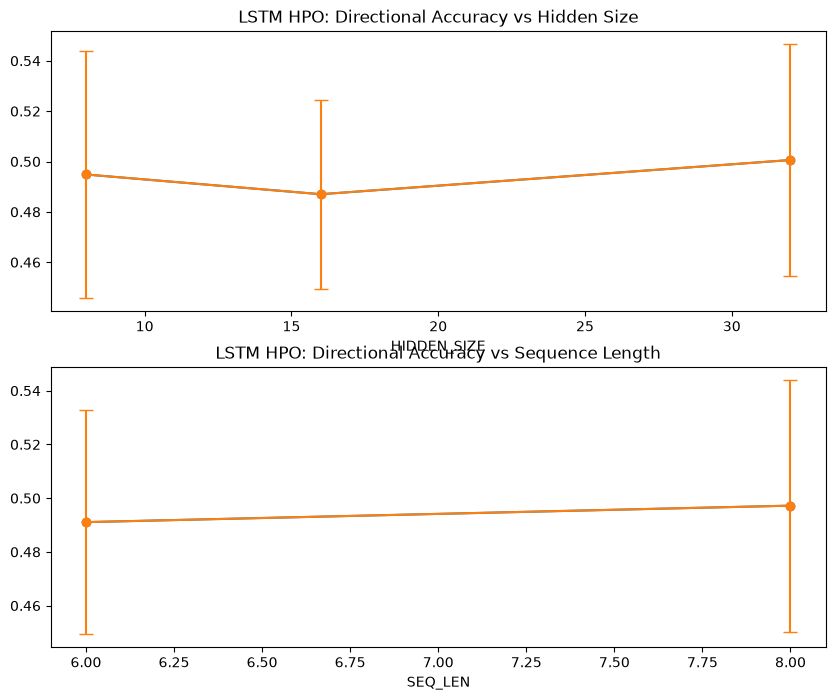

In [49]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
# look at trend over n_estimator values by averaging across all other hyperparameter combinations, also add error bars for std deviation
lstm_hpo_results.groupby('HIDDEN_SIZE')['DirAcc_mean'].mean().plot(marker='o', title='LSTM HPO: Directional Accuracy vs Hidden Size', ax=axs[0])
lstm_hpo_results.groupby('HIDDEN_SIZE')['DirAcc_mean'].mean().plot(marker='o', yerr=lstm_hpo_results.groupby('HIDDEN_SIZE')['DirAcc_std'].mean(), title='LSTM HPO: Directional Accuracy vs Hidden Size', capsize=5, ax=axs[0])

#separate plots for each hyperparameter to visualize trends and error bars
# look at trend over max_depth values by averaging across all other hyperparameter combinations, also add error bars for std deviation
lstm_hpo_results.groupby('SEQ_LEN')['DirAcc_mean'].mean().plot(marker='o', title='LSTM HPO: Directional Accuracy vs Sequence Length', ax=axs[1])
lstm_hpo_results.groupby('SEQ_LEN')['DirAcc_mean'].mean().plot(marker='o', yerr=lstm_hpo_results.groupby('SEQ_LEN')['DirAcc_std'].mean(), title='LSTM HPO: Directional Accuracy vs Sequence Length', capsize=5, ax=axs[1])

Text(0.5, 1.0, 'LSTM HPO: Directional Accuracy Heatmap')

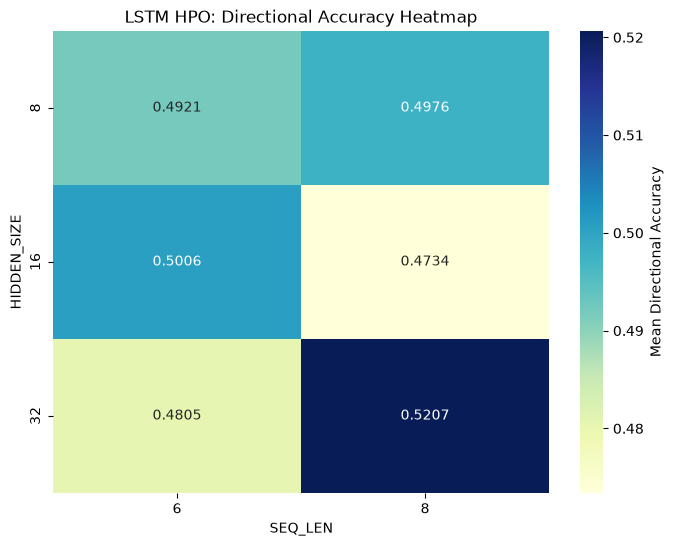

In [50]:
# heatmap of all hyperparameter combinations and their mean directional accuracy
lstm_hpo_pivot = lstm_hpo_results.pivot_table(index='HIDDEN_SIZE', columns='SEQ_LEN', values='DirAcc_mean')
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_hpo_pivot, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean Directional Accuracy'})
plt.title('LSTM HPO: Directional Accuracy Heatmap')

### TabPFN

In [198]:
# Function to prepare data for TabPFN model (no pre-processing needed for TabPFN)
def prep_fn_tabpfn(X_train, Y_train, X_val, Y_val, params):
    return X_train, Y_train, X_val, Y_val

if not use_saved_params:

    TABPFN_PARAM_GRID = {
        'fit_mode':     ["fit_with_cache"],
        'N_LAGS':       [1],
    }

    tabpfn_hpo_results, optimal_params_tabpfn = HPO(
        TABPFN_PARAM_GRID, prep_fn_tabpfn, train_tabpfn, evaluate_tabpfn,
        X_Train, Y_Train, n_folds=5, min_train_size=100, verbose=True
    )

### Save

In [52]:
if save_new_params:
    # Save HPO results to CSV files
    xgb_hpo_results.to_csv('Outputs/HPO/HPO Results XGBoost.csv', index=False)
    lstm_hpo_results.to_csv('Outputs/HPO/HPO Results LSTM.csv', index=False)
    tabpfn_hpo_results.to_csv('Outputs/HPO/HPO Results TabPFN.csv', index=False)
    # Save optimal parameters to JSON files
    save_optimal_params(optimal_params_xgb, 'Outputs/HPO/Optimal Params XGBoost.json')
    save_optimal_params(optimal_params_lstm, 'Outputs/HPO/Optimal Params LSTM.json')
    save_optimal_params(optimal_params_tabpfn, 'Outputs/HPO/Optimal Params TabPFN.json')

## Final Models


In [53]:
### Model Training Controles ###
use_saved_models = True # Set to True to use saved models, False to train new models
save_new_models = False # Set to True to save new trained models, False to skip saving

### OLS

In [54]:
# Train OLS model
OLS_PARAMS = {}
X_Train_ols, Y_Train_ols = X_Train_scaled, Y_Train
OLS_MODEL = train_ols(X_Train_ols, Y_Train_ols, OLS_PARAMS)
print(OLS_MODEL.summary())

                            OLS Regression Results                            
Dep. Variable:         BCOMENTR Index   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.972
Date:                Sat, 05 Sep 2026   Prob (F-statistic):             0.0127
Time:                        01:25:52   Log-Likelihood:                 1602.8
No. Observations:                 819   AIC:                            -3172.
Df Residuals:                     802   BIC:                            -3092.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0003      0.001     -0.

In [55]:
# Evaluate OLS model on Test1 set
X_Test1_ols, Y_Test1_ols = X_Test1_scaled, Y_Test1
test1_preds_ols, test1_dir_preds_ols, ols_test1_performance = evaluate_ols(OLS_MODEL, X_Test1_ols, Y_Test1)
display_results(ols_test1_performance, title="OLS Test1 Performance")

--- OLS Test1 Performance ---
Directional Accuracy: 0.5024
Directional Accuracy p-value: 0.6861
MSE: 0.002115
MAE: 0.034960
ROC-AUC: 0.4796
F1 Score: 0.5667
Confusion Matrix:
[[37 64]
 [40 68]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.37      0.42       101
      Up (1)       0.52      0.63      0.57       108

    accuracy                           0.50       209
   macro avg       0.50      0.50      0.49       209
weighted avg       0.50      0.50      0.49       209



### XGBoost

In [56]:
# XGBoost parameters
xgb_params = optimal_params_xgb
print(xgb_params)

# Prepare data for XGBoost model
X_Train_xgb, Y_Train_xgb, train_dates_xgb = X_Train_scaled, Y_Train, X_Train_scaled.index

# Train XGBoost model
if not use_saved_models:
    XGB_MODEL = train_xgb(X_Train_xgb, Y_Train_xgb, xgb_params)

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'N_LAGS': 1}


In [57]:
# Load and/or save XGBoost model

# Load
if use_saved_models:
    with open('Outputs/Models/XGB PARAMETERS.pkl', 'rb') as f:
        xgb_params = pickle.load(f)
    XGB_MODEL = XGBRegressor(**xgb_params)  # or XGBClassifier, matching original
    XGB_MODEL.load_model('Outputs/Models/XGB MODEL.json')
    print("Loaded")

# Save
if save_new_models:
    XGB_MODEL.save_model('Outputs/Models/XGB MODEL.json')
    with open('Outputs/Models/XGB PARAMETERS.pkl', 'wb') as f:
        pickle.dump(xgb_params, f)
    print("Saved")

# Print parameters
print(f"XGB Parameters: {xgb_params}")

Loaded
XGB Parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'N_LAGS': 1}


In [58]:
# Evaluate XGBoost model
train_preds_xgb, train_preds_dir_xgb, xgb_train_performance = evaluate_xgb(
    XGB_MODEL,
    X_Train_xgb, Y_Train_xgb
)
display_results(xgb_train_performance, "Train Results")
xgb_results_train = build_results_df(train_dates_xgb, Y_Train_xgb, train_preds_xgb, features)

X_Test1_xgb, Y_Test1_xgb, test1_dates_xgb = X_Test1_scaled, Y_Test1, X_Test1_scaled.index
test1_preds_xgb, test1_preds_dir_xgb, xgb_test1_performance = evaluate_xgb(
    XGB_MODEL,
    X_Test1_xgb, Y_Test1_xgb
)
display_results(xgb_test1_performance, "Test Results")
XGB_RESULTS_TEST1 = build_results_df(test1_dates_xgb, Y_Test1_xgb, test1_preds_xgb, features)

--- Train Results ---
Directional Accuracy: 0.7143
Directional Accuracy p-value: 0.0000
MSE: 0.000791
MAE: 0.022131
ROC-AUC: 0.7980
F1 Score: 0.7266
Confusion Matrix:
[[274 124]
 [110 311]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.71      0.69      0.70       398
      Up (1)       0.71      0.74      0.73       421

    accuracy                           0.71       819
   macro avg       0.71      0.71      0.71       819
weighted avg       0.71      0.71      0.71       819

--- Test Results ---
Directional Accuracy: 0.5837
Directional Accuracy p-value: 0.0306
MSE: 0.002004
MAE: 0.033562
ROC-AUC: 0.5337
F1 Score: 0.6420
Confusion Matrix:
[[44 57]
 [30 78]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.59      0.44      0.50       101
      Up (1)       0.58      0.72      0.64       108

    accuracy                           0.58       209
   macro avg       0.59      0.58 

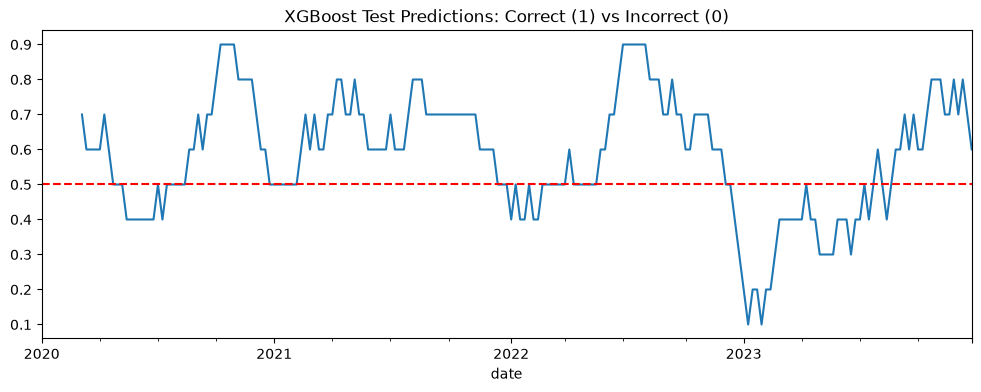

In [59]:
# Plot rolling mean of directional accuracy over time
XGB_RESULTS_TEST1["Correct"].astype(int).rolling(window=10).mean().plot(figsize=(12, 4), title="XGBoost Test Predictions: Correct (1) vs Incorrect (0)", legend=False)
plt.axhline(0.5, color='red', linestyle='--', label='50%') # add line for 50%

### LSTM

In [60]:
# LSTM parameters
lstm_params = optimal_params_lstm
print(lstm_params)

# Prepare LSTM training data
X_Train_lstm, Y_Train_lstm, train_dates_lstm = make_sequences(X_Train_scaled, Y_Train, lstm_params['SEQ_LEN'])

# Train LSTM model
if not use_saved_models:
    LSTM_MODEL = train_lstm(X_Train_lstm, Y_Train_lstm, lstm_params, verbose=1)

{'HIDDEN_SIZE': 32, 'DROPOUT': 0.2, 'SEQ_LEN': 8, 'NUM_LAYERS': 2, 'BATCH_SIZE': 32, 'N_EPOCHS': 100, 'PATIENCE': 15, 'VALIDATION_SPLIT': 0.2}


In [61]:
# Load and/or save LSTM model

# Load
if use_saved_models:
    saved_lstm_model = torch.load('Outputs/Models/LSTM MODEL.pt', map_location='cpu')
    lstm_input_size = saved_lstm_model['input_size']
    lstm_params = saved_lstm_model['LSTM_PARAMS']
    LSTM_MODEL = build_model(
        input_size=lstm_input_size,
        LSTM_PARAMS=lstm_params,
    )
    LSTM_MODEL.load_state_dict(saved_lstm_model['state_dict'])
    LSTM_MODEL.eval()
    print("Loaded")

# Save
if save_new_models:
    lstm_input_size = X_Train_lstm.shape[2]
    torch.save({
        'state_dict': LSTM_MODEL.state_dict(),
        'LSTM_PARAMS': lstm_params,
        'input_size': X_Train_lstm.shape[2],
    }, 'Outputs/Models/LSTM MODEL.pt')
    print("Saved")

# Print input size and parameters
if use_saved_models or save_new_models: print(f"Input size: {lstm_input_size}")
print(f"LSTM Parameters: {lstm_params}")

Loaded
Input size: 16
LSTM Parameters: {'HIDDEN_SIZE': 32, 'DROPOUT': 0.2, 'SEQ_LEN': 8, 'NUM_LAYERS': 2, 'BATCH_SIZE': 32, 'N_EPOCHS': 100, 'PATIENCE': 15, 'VALIDATION_SPLIT': 0.2}


In [62]:
# Evaluate LSTM model

train_preds_lstm, train_preds_dir_lstm, lstm_train_performance = evaluate_lstm(
    LSTM_MODEL, X_Train_lstm, Y_Train_lstm
)
display_results(lstm_train_performance, "Train Results")
lstm_results_train = build_results_df(train_dates_lstm, Y_Train_lstm, train_preds_lstm, features)


X_Test1_lstm, Y_Test1_lstm, test1_dates_lstm = make_sequences(X_Test1_scaled, Y_Test1, lstm_params['SEQ_LEN'])
test1_preds_lstm, test1_preds_dir_lstm, lstm_test1_performance = evaluate_lstm(
    LSTM_MODEL, X_Test1_lstm, Y_Test1_lstm
)
display_results(lstm_test1_performance, "Test Results")
LSTM_RESULTS_TEST1 = build_results_df(test1_dates_lstm, Y_Test1_lstm, test1_preds_lstm, features)

--- Train Results ---
Directional Accuracy: 0.5924
Directional Accuracy p-value: 0.0000
MSE: 0.001069
MAE: 0.025443
ROC-AUC: 0.6251
F1 Score: 0.6217
Confusion Matrix:
[[209 185]
 [146 272]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.59      0.53      0.56       394
      Up (1)       0.60      0.65      0.62       418

    accuracy                           0.59       812
   macro avg       0.59      0.59      0.59       812
weighted avg       0.59      0.59      0.59       812

--- Test Results ---
Directional Accuracy: 0.5693
Directional Accuracy p-value: 0.0903
MSE: 0.002035
MAE: 0.033284
ROC-AUC: 0.5373
F1 Score: 0.6478
Confusion Matrix:
[[35 62]
 [25 80]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.58      0.36      0.45        97
      Up (1)       0.56      0.76      0.65       105

    accuracy                           0.57       202
   macro avg       0.57      0.56 

In [63]:
# Directional accuracy by period

def da_by_period(df, freq):
    """freq: 'YE' for yearly, '6ME' for half-yearly, 'QE' for quarterly"""
    return (df['Correct']
            .resample(freq)
            .agg(['sum', 'count'])
            .rename(columns={'sum': 'correct', 'count': 'total'})
            .assign(directional_accuracy=lambda x: x['correct'] / x['total']))

print("=== Yearly ===")
print(da_by_period(LSTM_RESULTS_TEST1, 'YE'))

print("\n=== Half-Yearly ===")
print(da_by_period(LSTM_RESULTS_TEST1, '6ME'))

=== Yearly ===
            correct  total  directional_accuracy
date                                            
2020-12-31       26     45              0.577778
2021-12-31       29     53              0.547170
2022-12-31       29     52              0.557692
2023-12-31       31     52              0.596154

=== Half-Yearly ===
            correct  total  directional_accuracy
date                                            
2020-02-29        1      2              0.500000
2020-08-31       17     26              0.653846
2021-02-28       13     26              0.500000
2021-08-31       17     26              0.653846
2022-02-28       12     26              0.461538
2022-08-31       13     26              0.500000
2023-02-28       14     26              0.538462
2023-08-31       15     26              0.576923
2024-02-29       13     18              0.722222


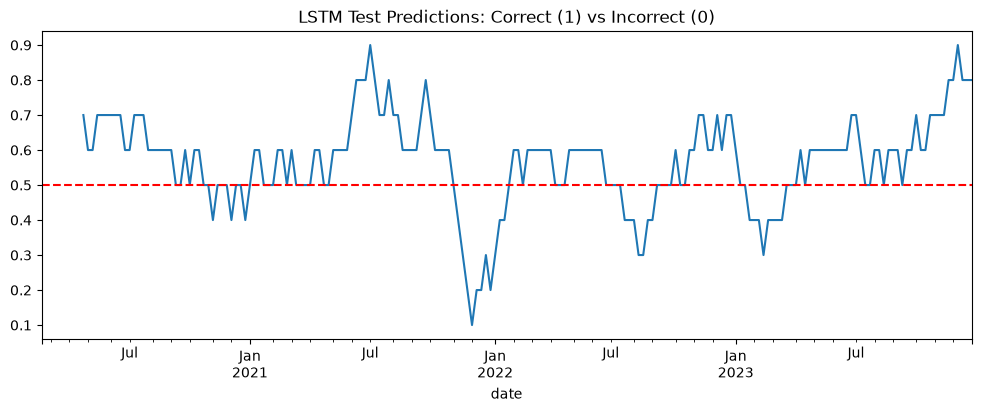

In [64]:
# Plot rolling mean of directional accuracy over time
LSTM_RESULTS_TEST1["Correct"].astype(int).rolling(window=10).mean().plot(figsize=(12, 4), title="LSTM Test Predictions: Correct (1) vs Incorrect (0)", legend=False)
plt.axhline(0.5, color='red', linestyle='--', label='50%') # add line for 50%

### TabPFN

In [65]:
# TabPFN parameters
tabpfn_params = optimal_params_tabpfn
print(f"TabPFN Parameters: {tabpfn_params}")

# Prepare training data for TabPFN model 
X_Train_tabpfn, Y_Train_tabpfn, train_dates_tabpfn = X_Train, Y_Train, X_Train.index
if not use_saved_models:
    TABPFN_MODEL = train_tabpfn(X_Train_tabpfn, Y_Train_tabpfn, tabpfn_params)

TabPFN Parameters: {'fit_mode': 'fit_with_cache', 'N_LAGS': 1}


In [66]:
# Load and/or save TabPFN model

# Load
if use_saved_models:
    with open('Outputs/Models/TABPFN MODEL.pkl', 'rb') as f:
        TABPFN_MODEL = pickle.load(f)
    print("Loaded")

# Save
if save_new_models:
    with open('Outputs/Models/TABPFN MODEL.pkl', 'wb') as f:
        pickle.dump(TABPFN_MODEL, f)
    print("Saved")

Loaded


In [67]:
# Evaluate TabPFN model

X_Train_tabpfn, Y_Train_tabpfn, train_dates_tabpfn = X_Train, Y_Train, X_Train.index
train_preds_tabpfn, train_preds_dir_tabpfn, tabpfn_train_performance = evaluate_tabpfn(
    TABPFN_MODEL,
    X_Train_tabpfn, Y_Train_tabpfn
)
display_results(tabpfn_train_performance, "Train Results")
tabpfn_results_train = build_results_df(train_dates_tabpfn, Y_Train_tabpfn, train_preds_tabpfn, features)

X_Test1_tabpfn, Y_Test1_tabpfn, test1_dates_tabpfn = X_Test1, Y_Test1, X_Test1.index
test1_preds_tabpfn, test1_preds_dir_tabpfn, tabpfn_test1_performance = evaluate_tabpfn(
    TABPFN_MODEL,
    X_Test1_tabpfn, Y_Test1_tabpfn
)
display_results(tabpfn_test1_performance, "Test Results")
TABPFN_RESULTS_TEST1 = build_results_df(test1_dates_tabpfn, Y_Test1_tabpfn, test1_preds_tabpfn, features)

--- Train Results ---
Directional Accuracy: 0.8449
Directional Accuracy p-value: 0.0000
MSE: 0.000795
MAE: 0.020513
ROC-AUC: 0.9345
F1 Score: 0.8590
Confusion Matrix:
[[305  93]
 [ 34 387]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.90      0.77      0.83       398
      Up (1)       0.81      0.92      0.86       421

    accuracy                           0.84       819
   macro avg       0.85      0.84      0.84       819
weighted avg       0.85      0.84      0.84       819

--- Test Results ---
Directional Accuracy: 0.5455
Directional Accuracy p-value: 0.2234
MSE: 0.001967
MAE: 0.033398
ROC-AUC: 0.5183
F1 Score: 0.6091
Confusion Matrix:
[[40 61]
 [34 74]]
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.54      0.40      0.46       101
      Up (1)       0.55      0.69      0.61       108

    accuracy                           0.55       209
   macro avg       0.54      0.54 

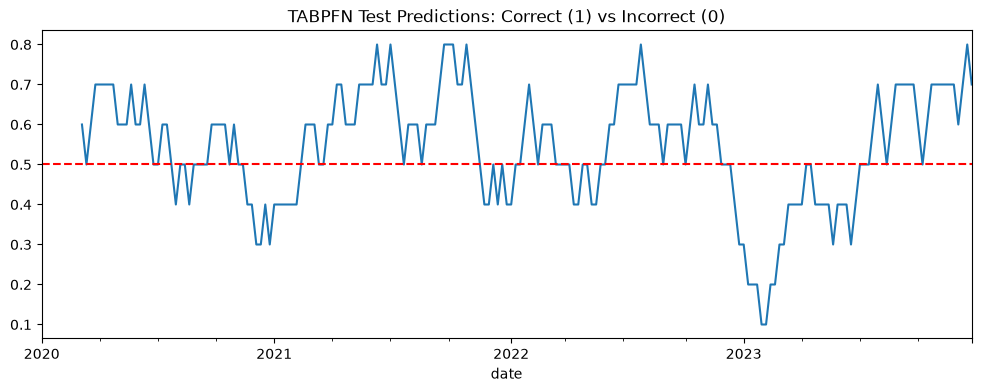

In [68]:
# Plot rolling mean of directional accuracy over time
TABPFN_RESULTS_TEST1["Correct"].astype(int).rolling(window=10).mean().plot(figsize=(12, 4), title="TABPFN Test Predictions: Correct (1) vs Incorrect (0)", legend=False)
plt.axhline(0.5, color='red', linestyle='--', label='50%') # add line for 50%

### Model Performance

In [161]:
# Out-of-sample model performance summary
model_performance = pd.DataFrame(
    {"XGBoost": [xgb_test1_performance['Directional Accuracy'], xgb_test1_performance['Dir Acc p-value']/100, xgb_test1_performance['MSE']*10, xgb_test1_performance['MAE'], xgb_test1_performance['ROC-AUC']],
     "LSTM": [lstm_test1_performance['Directional Accuracy'], lstm_test1_performance['Dir Acc p-value']/100, lstm_test1_performance['MSE']*10, lstm_test1_performance['MAE'], lstm_test1_performance['ROC-AUC']],
     "TabPFN": [tabpfn_test1_performance['Directional Accuracy'], tabpfn_test1_performance['Dir Acc p-value']/100, tabpfn_test1_performance['MSE']*10, tabpfn_test1_performance['MAE'], tabpfn_test1_performance['ROC-AUC']],
    }, index=["Directional Accuracy (%)", "Directional Accuracy p-value", "MSE (x 10^3)", "MAE (x 10^2)", "ROC-AUC (x 10^2)"]
)*100
display(model_performance.round(2))

,XGBoost,LSTM,TabPFN
Directional Accuracy (%),58.37,56.93,54.55
Directional Accuracy p-value,0.03,0.09,0.22
MSE (x 10^3),2.00,2.03,1.97
MAE (x 10^2),3.36,3.33,3.34
ROC-AUC (x 10^2),53.37,53.73,51.83


# XAI Explanations

In [253]:
### XAI (and model predictions) Controls ###

use_saved_xai = False # Set to True to use saved XAI results, False to run XAI analysis
save_xai = False # Set to True to save XAI results and model predictions, False to skip saving

## SHAP

In [254]:
shap_features_lags = [f"shap__{f}__lag{t}" for f in features for t in range(lstm_params['SEQ_LEN'], 0, -1)]
shap_features = [f"shap__{f}" for f in features]
shap_lags = [f"shap__lag{t}" for t in range(lstm_params['SEQ_LEN'], 0, -1)]

### XGBoost

In [255]:
def compute_xgb_shap(results_df, X_Train_xgb, X_Test1_xgb, xgb_model):
    def model_predict_xgb(X):
        return xgb_model.predict(X)

    np.random.seed(42)
    shap_background_xgb = shap.kmeans(X_Train_xgb, 50)
    explainer_xgb  = shap.KernelExplainer(model_predict_xgb, shap_background_xgb)
    shap_values_xgb = explainer_xgb.shap_values(X_Test1_xgb, nsamples=500) # shape: (n_test_samples, n_features)

    for i, f in enumerate(features):
        results_df[f'shap__{f}'] = shap_values_xgb[:, i]

    return results_df

### LSTM

In [256]:
def compute_lstm_shap(results_df, X_Train_lstm, X_Test1_lstm, lstm_model, seq_len):
    lstm_model.eval()
    # KernelSHAP requires a function that takes a 2D array
    def model_predict(X_flat):
        X_3d = X_flat.reshape(len(X_flat), seq_len, -1)   # unflatten back to 3D
        X_t = torch.as_tensor(X_3d, dtype=torch.float32, device=device)
        with torch.no_grad():
            preds = lstm_model(X_t)
        return preds.cpu().numpy().flatten()
    
    X_Test1_lstm_flat = X_Test1_lstm.reshape(len(X_Test1_lstm), -1) # flatten to 2D for KernelSHAP

    np.random.seed(42)
    shap_background_lstm = shap.kmeans(X_Train_lstm.reshape(len(X_Train_lstm), -1), 50)
    shap_explainer_lstm = shap.KernelExplainer(model_predict, shap_background_lstm)

    shap_values_lstm = shap_explainer_lstm.shap_values(X_Test1_lstm_flat, nsamples=1000) # shape: (n_test_samples, seq_len * n_features)
    shap_lstm_3d = shap_values_lstm.reshape(len(shap_values_lstm), seq_len, -1) # shape: (n_test_samples, seq_len, n_features)

    for i, f in enumerate(features):
        for lag in range(seq_len, 0, -1):
            results_df[f'shap__{f}__lag{lag}'] = shap_lstm_3d[:, seq_len - lag, i]

    for i, f in enumerate(features):
        results_df[f'shap__{f}'] = shap_lstm_3d.sum(axis=1)[:,i]

    for lag in range(seq_len, 0, -1):
        results_df[f'shap__lag{lag}'] = shap_lstm_3d.sum(axis=2)[:, seq_len - lag]

    return results_df, shap_lstm_3d

### TabPFN

In [257]:
def compute_tabpfn_shap(results_df, X_Train_scaled, X_Test1_scaled, tabpfn_model):
    TABPFN_MODEL_SCALED = TabPFN_SCALED_WRAPPER()
    X_Train_tabpfn_scaled = X_Train_scaled
    X_Test1_tabpfn_scaled = X_Test1_scaled

    explainer_tabpfn = get_tabpfn_imputation_explainer(
        model=TABPFN_MODEL_SCALED,
        data=X_Train_tabpfn_scaled,
        index="SV",
        max_order=1,
    )
    shap_values_tabpfn = shapiq_to_shap_explanation(
        explainer=explainer_tabpfn,
        X=X_Test1_tabpfn_scaled,
        budget=512,
        feature_names=features,
    ).values #shap_values_tabpfn shape: (n_test_samples, n_features)
    
    for i, f in enumerate(features):
        results_df[f'shap__{f}'] = shap_values_tabpfn[:, i]

    return results_df

## LIME

In [258]:
lime_features_lags = [f"lime__{f}__lag{t}" for f in features for t in range(lstm_params["SEQ_LEN"], 0, -1)]
lime_features = [f"lime__{f}" for f in features]
lime_lags = [f"lime__lag{t}" for t in range(lstm_params["SEQ_LEN"], 0, -1)]

### XGBoost

In [259]:
def compute_xgb_lime(results_df, X_Train_xgb, X_Test1_xgb, xgb_model):
    # LIME requires a callable prediction function
    def predict_fn(x):
        return xgb_model.predict(x)
    
    lime_explainer_xgb = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_xgb.values,
        feature_names=X_Train_xgb.columns.tolist(),
        mode='regression',
        discretize_continuous=False,
        random_state=42
    )
    lime_xgb = []
    for i in range(len(X_Test1_xgb)):
        if i+1 % 20 == 0:
            print(f"Explaining row {i+1}/{len(X_Test1_xgb)}")
        exp = lime_explainer_xgb.explain_instance(X_Test1_xgb.iloc[i].values, predict_fn, num_features=len(features))
        
        arr = np.zeros(len(features))
        for feature_id, importance in exp.local_exp[1]:
            arr[feature_id] = importance
        lime_xgb.append(arr)
        
    for i, f in enumerate(features):
        results_df[f'lime__{f}'] = np.array(lime_xgb)[:, i]

    return results_df

### LSTM

In [260]:
def compute_lstm_lime(results_df, X_Train_lstm, X_Test1_lstm, lstm_model, seq_len):
    X_Train_lstm_flat = X_Train_lstm.reshape(len(X_Train_lstm), -1)
    X_Test1_lstm_flat = X_Test1_lstm.reshape(len(X_Test1_lstm), -1)
    lime_feature_names = [f"{f}__lag{seq_len - t}" for t in range(seq_len) for f in features]

    # LIME requires a callable prediction function that takes a 2D array
    def model_predict(x):
        X_3d = x.reshape(len(x), seq_len, -1)
        X_t = torch.as_tensor(X_3d, dtype=torch.float32, device=device)
        with torch.no_grad():
            preds = lstm_model(X_t)
        return preds.cpu().numpy().flatten()
    
    lime_explainer_lstm = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_lstm_flat,
        feature_names=lime_feature_names,
        mode='regression',
        discretize_continuous=False,
        random_state=42
    )
    lstm_model.eval()
    lime_values_lstm = []
    for i in range(len(X_Test1_lstm_flat)):
        if (i + 1) % 20 == 0 or i == 0:
            print(f"Explaining instance {i+1}/{len(X_Test1_lstm_flat)}...")

        exp = lime_explainer_lstm.explain_instance(
            X_Test1_lstm_flat[i], model_predict,
            num_features=len(lime_feature_names)
    )

        arr = np.zeros(len(lime_feature_names))
        for feature_id, importance in exp.local_exp[1]:
            arr[feature_id] = importance
        lime_values_lstm.append(arr)

    lime_values_lstm = np.array(lime_values_lstm) # shape: (n_test_samples, seq_len * n_features)
    lime_lstm_3d = lime_values_lstm.reshape(len(lime_values_lstm), seq_len, -1) # shape: (n_test_samples, seq_len, n_features)

    for i, f in enumerate(features):
        for lag in range(seq_len, 0, -1):
            results_df[f'lime__{f}__lag{lag}'] = lime_lstm_3d[:, seq_len - lag, i]

    for i, f in enumerate(features):
        results_df[f'lime__{f}'] = np.abs(lime_lstm_3d.sum(axis=1)[:, i])

    for lag in range(seq_len, 0, -1):
        results_df[f'lime__lag{lag}'] = np.abs(lime_lstm_3d.sum(axis=2)[:, seq_len - lag])

    return results_df, lime_lstm_3d

### TabPFN

In [261]:
def compute_tabpfn_lime(results_df, X_Train_scaled, X_Test1_scaled, tabpfn_model):
    X_Train_tabpfn_scaled = X_Train_scaled
    X_Test1_tabpfn_scaled = X_Test1_scaled

    # LIME requires a callable prediction function that takes a 2D array
    def predict_fn(x_scaled):
        x_raw = scaler.inverse_transform(x_scaled) # convert scaled features back to original scale
        x_df = pd.DataFrame(x_raw, columns=features)
        return tabpfn_model.predict(x_df)
    
    lime_explainer_tabpfn = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_tabpfn_scaled.values,
        feature_names=features,
        mode='regression',
        discretize_continuous=False,
        random_state=42
    )
    lime_tabpfn = []
    for i in range(len(X_Test1_tabpfn_scaled)):
        if (i+1) % 20 == 0 or i == 0:
            print(f"Explaining instance {i+1}/{len(X_Test1_tabpfn_scaled)}...")

        exp = lime_explainer_tabpfn.explain_instance(X_Test1_tabpfn_scaled.iloc[i].values, predict_fn, num_features=len(X_Train.columns), num_samples=500)
        
        arr = np.zeros(len(features))
        for feature_id, importance in exp.local_exp[1]:
            arr[feature_id] = importance
        lime_tabpfn.append(arr)
        
    for i, f in enumerate(features):
        results_df[f'lime__{f}'] = np.array(lime_tabpfn)[:, i]

    return results_df

## WinIT (LSTM)

In [262]:
winit_features_lags = [f"winit__{f}__lag{t}" for f in features for t in range(lstm_params["SEQ_LEN"], 0, -1)]
winit_features = [f"winit__{f}" for f in features]
winit_lags = [f"winit__lag{t}" for t in range(lstm_params["SEQ_LEN"], 0, -1)]

In [263]:
class WinIT:
    def __init__(self, model, data, seq_len):
        self.model = model
        self.data = torch.as_tensor(data, dtype=torch.float32)   # accepts numpy or tensor input
        self.seq_len = seq_len

    def _compute_metric(self, p_y_exp, p_y_hat):
        # prediction-difference metric (regression case)
        return torch.abs(p_y_hat - p_y_exp).sum(dim=-1)

    def _generate_counterfactuals(self, batch_size, feature_index):
        choices = self.data[:, :, feature_index].reshape(-1)
        idx = torch.randint(len(choices), (batch_size * self.seq_len,))
        return choices[idx].reshape(batch_size, self.seq_len)

    def _format_output(self, outputs):
        return outputs.reshape(outputs.shape[0], 1, -1)  # (batch, pred_len=1, 1)

    def attribute(self, inputs, verbose=False):
        self.model.eval()
        with torch.no_grad():
            y_original = self._format_output(self.model(inputs))
            batch_size, seq_len, n_features = inputs.shape
            iS_old = torch.zeros(batch_size, 1, seq_len, n_features, device=inputs.device)

            for feature in range(n_features):
                cloned = inputs.clone()
                cf = self._generate_counterfactuals(batch_size, feature).to(inputs.device)
                for t in reversed(range(seq_len)):
                    if verbose and(t % 10 == 0 or t == seq_len - 1):
                        print(f"Computing for feature {feature + 1} lag {seq_len - t}...")
                    cloned[:, t, feature] = cf[:, t]
                    y_perturbed = self._format_output(self.model(cloned))
                    iS_old[:, :, t, feature] = self._compute_metric(y_original, y_perturbed)
                del cloned; gc.collect()

            # forward difference — no flip, no shift
            iS_old[:, :, :-1, :] -= iS_old[:, :, 1:, :]
            return iS_old

In [264]:
def compute_winit_lstm(results_df, X_Train_lstm, X_Test1_lstm, lstm_model, seq_len):
    X_Train_tensor = torch.tensor(X_Train_lstm, dtype=torch.float32).to(device)
    X_Test1_tensor  = torch.tensor(X_Test1_lstm,  dtype=torch.float32).to(device)

    winit = WinIT(model=lstm_model, data=X_Train_tensor, seq_len=seq_len)

    winit_lstm = winit.attribute(X_Test1_tensor, verbose=True)
    winit_lstm = winit_lstm.squeeze(1).cpu()
    winit_lstm_3d = np.array(winit_lstm) # shape: (n_test_samples, seq_len, n_features)

    for i, f in enumerate(features):
        for lag in range(seq_len, 0, -1):
            results_df[f'winit__{f}__lag{lag}'] = winit_lstm_3d[:, seq_len - lag, i]

    for i, f in enumerate(features):
        results_df[f'winit__{f}'] = np.abs(winit_lstm_3d.sum(axis=1)[:,i])

    for lag in range(seq_len, 0, -1):
        results_df[f'winit__lag{lag}'] = np.abs(winit_lstm_3d.sum(axis=2)[:, seq_len - lag])

    return results_df, winit_lstm_3d

## Load and Save

In [265]:
# Load and/or compute XAI results
if use_saved_xai:
    XGB_RESULTS_TEST1 = pd.read_csv('Outputs/Model Results/XGB RESULTS TEST1.csv', index_col=0, parse_dates=True)
    LSTM_RESULTS_TEST1 = pd.read_csv('Outputs/Model Results/LSTM RESULTS TEST1.csv', index_col=0, parse_dates=True)
    TABPFN_RESULTS_TEST1 = pd.read_csv('Outputs/Model Results/TABPFN RESULTS TEST1.csv', index_col=0, parse_dates=True)

elif not use_saved_xai:
    print("--- Computing SHAP for XGBoost... ---")
    XGB_RESULTS_TEST1 = compute_xgb_shap(XGB_RESULTS_TEST1, X_Train_xgb, X_Test1_xgb, XGB_MODEL)
    print("--- Computing LIME for XGBoost... ---")
    XGB_RESULTS_TEST1 = compute_xgb_lime(XGB_RESULTS_TEST1, X_Train_xgb, X_Test1_xgb, XGB_MODEL)

    print("--- Computing SHAP for LSTM... ---")
    LSTM_RESULTS_TEST1, shap_lstm_3d_test1 = compute_lstm_shap(LSTM_RESULTS_TEST1, X_Train_lstm, X_Test1_lstm, LSTM_MODEL, lstm_params['SEQ_LEN'])
    print("--- Computing LIME for LSTM... ---")
    LSTM_RESULTS_TEST1, lime_lstm_3d_test1 = compute_lstm_lime(LSTM_RESULTS_TEST1, X_Train_lstm, X_Test1_lstm, LSTM_MODEL, lstm_params["SEQ_LEN"])
    print("--- Computing WinIT for LSTM... ---")
    LSTM_RESULTS_TEST1, winit_lstm_3d_test1 = compute_winit_lstm(LSTM_RESULTS_TEST1, X_Train_lstm, X_Test1_lstm, LSTM_MODEL, lstm_params["SEQ_LEN"])

    print("--- Computing SHAP for TabPFN... ---")
    TABPFN_RESULTS_TEST1 = compute_tabpfn_shap(TABPFN_RESULTS_TEST1, X_Train_scaled, X_Test1_scaled, TABPFN_MODEL)
    print("--- Computing LIME for TabPFN... ---")
    TABPFN_RESULTS_TEST1 = compute_tabpfn_lime(TABPFN_RESULTS_TEST1, X_Train_scaled, X_Test1_scaled, TABPFN_MODEL)

--- Computing SHAP for XGBoost... ---


100%|██████████| 209/209 [00:01<00:00, 164.72it/s]


--- Computing LIME for XGBoost... ---
--- Computing SHAP for LSTM... ---


100%|██████████| 202/202 [00:06<00:00, 33.13it/s]


--- Computing LIME for LSTM... ---
Explaining instance 1/202...
Explaining instance 20/202...
Explaining instance 40/202...
Explaining instance 60/202...
Explaining instance 80/202...
Explaining instance 100/202...
Explaining instance 120/202...
Explaining instance 140/202...
Explaining instance 160/202...
Explaining instance 180/202...
Explaining instance 200/202...
--- Computing WinIT for LSTM... ---
Computing for feature 1 lag 1...
Computing for feature 1 lag 8...
Computing for feature 2 lag 1...
Computing for feature 2 lag 8...
Computing for feature 3 lag 1...
Computing for feature 3 lag 8...
Computing for feature 4 lag 1...
Computing for feature 4 lag 8...
Computing for feature 5 lag 1...
Computing for feature 5 lag 8...
Computing for feature 6 lag 1...
Computing for feature 6 lag 8...
Computing for feature 7 lag 1...
Computing for feature 7 lag 8...
Computing for feature 8 lag 1...
Computing for feature 8 lag 8...
Computing for feature 9 lag 1...
Computing for feature 9 lag 8...


In [266]:
if save_xai:
    XGB_RESULTS_TEST1.to_csv('Outputs/XGB_RESULTS_TEST1.csv')
    LSTM_RESULTS_TEST1.to_csv('Outputs/LSTM_RESULTS_TEST1.csv')
    TABPFN_RESULTS_TEST1.to_csv('Outputs/TABPFN_RESULTS_TEST1.csv')

# XAI Evaluation

## Load

XAI evaluation can take >10mins even on high-end GPUs.

In [84]:
### XAI Evaluation Controls ###
use_saved_xai_eval = False # Set to True to use saved XAI evaluation results, False to run XAI evaluation
# XAI evaluation results are saved if save_xai = True and used_saved_xai_eval = False.

In [85]:
# Load xai eval results specifically if not already loaded from saved xai results.
if use_saved_xai_eval and not use_saved_xai:
    xai_eval_cols_xgb_tabpfn = ['Faithfulness_SHAP', 'Faithfulness_LIME', "Lipschitz_SHAP", "Lipschitz_LIME"]
    xai_eval_cols_data = pd.read_csv('Outputs/Model Results/XGB RESULTS TEST1.csv', index_col=0, parse_dates=True)[xai_eval_cols_xgb_tabpfn]
    XGB_RESULTS_TEST1[xai_eval_cols_xgb_tabpfn] = xai_eval_cols_data

    xai_eval_cols_lstm = ['Faithfulness_SHAP', 'Faithfulness_LIME', "Faithfulness_WinIT", "Lipschitz_SHAP", "Lipschitz_LIME", "Lipschitz_WinIT"]
    xai_eval_cols_data = pd.read_csv('Outputs/Model Results/LSTM RESULTS TEST1.csv', index_col=0, parse_dates=True)[xai_eval_cols_lstm]
    LSTM_RESULTS_TEST1[xai_eval_cols_lstm] = xai_eval_cols_data

    xai_eval_cols_data = pd.read_csv('Outputs/Model Results/TABPFN RESULTS TEST1.csv', index_col=0, parse_dates=True)[xai_eval_cols_xgb_tabpfn]
    TABPFN_RESULTS_TEST1[xai_eval_cols_xgb_tabpfn] = xai_eval_cols_data

## Quantus Wrappers

In [86]:
np.random.seed(42)
torch.manual_seed(42)

# Quantus has restrictions that require some manipulation for compatibility.
    # It only accepts PyTorch models. The XGBoost and TabPFN models are wrapped in torch.nn modules (the LSTM model is already PyTorch).
    # It takes 3D input data, intended for image-like inputs. The inputs are reshaped to have a fake channel dimension (except for the LSTM model which is already 3D).
    # It requires a y_batch of class indices to know which output class to explain. Since the models are regression models, a dummy "class 0" index is used for all samples.

# XGBoost wrapper
    # Quantus requires a PyTorch model.
    # Input data is reshaped to have a fake channel dimension, which the wrapper undoes before passing to the XGBoost model.
class XGBWrapper(nn.Module):
    def __init__(self, booster):
        super().__init__()
        self.booster = booster

    def forward(self, x):
        x_np = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
        x_np = x_np.reshape(x_np.shape[0], -1)  # undo the fake channel dim
        preds = self.booster.predict(x_np)
        return torch.tensor(preds, dtype=torch.float32).reshape(-1, 1)
XGB_MODEL_NN = XGBWrapper(XGB_MODEL)
XGB_MODEL_NN.eval()

# LSTM wrapper
    # Output of LSTM is (batch, seq_len, 1) but Quantus expects (batch, 1, 1). The wrapper squeezes the seq_len dimension.
class LSTMOutputAdapter(nn.Module):
    def __init__(self, lstm_model):
        super().__init__()
        self.lstm_model = lstm_model

    def forward(self, x):
        out = self.lstm_model(x)
        if out.dim() == 1:
            out = out.unsqueeze(1)
        return out
LSTM_MODEL_NN = LSTMOutputAdapter(LSTM_MODEL)
LSTM_MODEL_NN.eval()

# TabPFN wrapper
    # Quantus requires a PyTorch model.
    # Input data is reshaped to have a fake channel dimension, which the wrapper undoes before passing to the TabPFN model.
    # This also handles the unscaling of the input data, since TabPFN was trained on raw (unscaled) data.
class TabPFN_Quantus_Wrapper(nn.Module):
    def __init__(self, model, feature_names, scaler):
        super().__init__()
        self.model = model
        self.feature_names = feature_names
        self.scaler = scaler

    def forward(self, x):
        x_np = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
        x_np = x_np.reshape(x_np.shape[0], -1)
        x_raw = self.scaler.inverse_transform(x_np)          # scaled -> raw
        x_df = pd.DataFrame(x_raw, columns=self.feature_names)
        preds = self.model.predict(x_df)
        return torch.tensor(preds, dtype=torch.float32).reshape(-1, 1)
TABPFN_MODEL_NN = TabPFN_Quantus_Wrapper(TABPFN_MODEL, feature_names=X_Test1_tabpfn.columns.tolist(), scaler=scaler)
TABPFN_MODEL_NN.eval()

X_Test1_xgb_numpy = X_Test1_xgb.to_numpy().astype(np.float32)
X_Test1_xgb_numpy = X_Test1_xgb_numpy.reshape(X_Test1_xgb_numpy.shape[0], 1, -1) # fake channel input dimension
y_batch_xgb = np.zeros(X_Test1_xgb_numpy.shape[0], dtype=int) # dummy class indices

y_batch_lstm = np.zeros(X_Test1_lstm.shape[0], dtype=int) # dummy class indices

X_Test1_tabpfn_numpy = X_Test1_scaled.to_numpy().astype(np.float32)
X_Test1_tabpfn_numpy = X_Test1_tabpfn_numpy.reshape(X_Test1_tabpfn_numpy.shape[0], 1, -1) # fake channel input dimension
y_batch_tabpfn = np.zeros(X_Test1_tabpfn_numpy.shape[0], dtype=int) # dummy class indices

## Faithfulness

In [87]:
# Initialise Quantus Faithfulness Correlation metric
faithfulness_correlation = quantus.FaithfulnessCorrelation(
    nr_runs=100,          # number of random feature subsets sampled per instance
    subset_size=4,        # features removed per run — keep well below n_features
    perturb_baseline="mean",
    return_aggregate=False,
    abs=False,
    normalise=True,
    disable_warnings=True,
)

In [88]:
# Compute Faithfulness Correlation for XGBoost SHAP and LIME attributions
if not use_saved_xai_eval:
    a_batch = np.array(XGB_RESULTS_TEST1[shap_features])
    a_batch_q = a_batch.reshape(a_batch.shape[0], 1, -1)
    faithfulness_shap_xgb = faithfulness_correlation(
        model=XGB_MODEL_NN,
        x_batch=X_Test1_xgb_numpy,
        y_batch=y_batch_xgb,
        a_batch=a_batch_q,
        channel_first=True,
    )
XGB_RESULTS_TEST1["Faithfulness_SHAP"] = faithfulness_shap_xgb
print(f"\nMean faithfulness correlation: {XGB_RESULTS_TEST1['Faithfulness_SHAP'].mean():.4f}")

if not use_saved_xai_eval:
    a_batch_lime = np.array(XGB_RESULTS_TEST1[lime_features]).astype(np.float32)
    a_batch_lime_q = a_batch_lime.reshape(a_batch_lime.shape[0], 1, -1)
    faithfulness_lime_xgb = faithfulness_correlation(
        model=XGB_MODEL_NN,
        x_batch=X_Test1_xgb_numpy,
        y_batch=y_batch_xgb,
        a_batch=a_batch_lime_q,
        channel_first=True,
    )
    XGB_RESULTS_TEST1["Faithfulness_LIME"] = faithfulness_lime_xgb
print(f"\nMean faithfulness correlation: {XGB_RESULTS_TEST1['Faithfulness_LIME'].mean():.4f}")


Mean faithfulness correlation: 0.8082

Mean faithfulness correlation: 0.0225


In [89]:
# Compute Faithfulness Correlation for LSTM SHAP, LIME, and WinIT attributions
if not use_saved_xai_eval:
    a_batch_lstm = np.array(LSTM_RESULTS_TEST1[shap_features_lags]).reshape(len(LSTM_RESULTS_TEST1), len(features), lstm_params["SEQ_LEN"]).transpose(0, 2, 1)  
    faithfulness_shap_lstm = faithfulness_correlation(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=a_batch_lstm, channel_first=True, device=device
    )
    LSTM_RESULTS_TEST1["Faithfulness_SHAP"] = faithfulness_shap_lstm
print(f"\nMean faithfulness correlation: {LSTM_RESULTS_TEST1['Faithfulness_SHAP'].mean():.4f}")

if not use_saved_xai_eval:
    a_batch_lstm = np.array(LSTM_RESULTS_TEST1[lime_features_lags]).reshape(len(LSTM_RESULTS_TEST1), len(features), lstm_params["SEQ_LEN"]).transpose(0, 2, 1)  
    faithfulness_lime_lstm = faithfulness_correlation(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=a_batch_lstm, channel_first=True, device=device
    )
    LSTM_RESULTS_TEST1["Faithfulness_LIME"] = faithfulness_lime_lstm
print(f"\nMean faithfulness correlation: {LSTM_RESULTS_TEST1['Faithfulness_LIME'].mean():.4f}")

if not use_saved_xai_eval:
    a_batch_lstm = np.array(LSTM_RESULTS_TEST1[winit_features_lags]).reshape(len(LSTM_RESULTS_TEST1), len(features), lstm_params["SEQ_LEN"]).transpose(0, 2, 1)  
    faithfulness_winit_lstm = faithfulness_correlation(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=a_batch_lstm, channel_first=True, device=device
    )
    LSTM_RESULTS_TEST1["Faithfulness_WinIT"] = faithfulness_winit_lstm
print(f"\nMean faithfulness correlation: {LSTM_RESULTS_TEST1['Faithfulness_WinIT'].mean():.4f}")


Mean faithfulness correlation: 0.7339

Mean faithfulness correlation: -0.0714

Mean faithfulness correlation: 0.0129


In [90]:
# Compute Faithfulness Correlation for TabPFN SHAP and LIME attributions
if not use_saved_xai_eval:
    a_batch = np.array(TABPFN_RESULTS_TEST1[shap_features])  # shape (n_instances, n_features)
    a_batch_q = a_batch.reshape(a_batch.shape[0], 1, -1)
    faithfulness_shap_tabpfn = faithfulness_correlation(
        model=TABPFN_MODEL_NN,
        x_batch=X_Test1_tabpfn_numpy,
        y_batch=y_batch_tabpfn,
    a_batch=a_batch_q,
    channel_first=True,
    device=device
    )
    TABPFN_RESULTS_TEST1["Faithfulness_SHAP"] = faithfulness_shap_tabpfn
print(f"\nMean faithfulness correlation: {TABPFN_RESULTS_TEST1['Faithfulness_SHAP'].mean():.4f}")

if not use_saved_xai_eval:
    a_batch_lime = np.array(TABPFN_RESULTS_TEST1[lime_features]).astype(np.float32)   # shape (n_instances, n_features)
    a_batch_lime_q = a_batch_lime.reshape(a_batch_lime.shape[0], 1, -1)
    faithfulness_lime_tabpfn = faithfulness_correlation(
        model=TABPFN_MODEL_NN,
        x_batch=X_Test1_tabpfn_numpy,   # same reshaped input as the SHAP run
        y_batch=y_batch_tabpfn,
        a_batch=a_batch_lime_q,
        channel_first=True,
        device=device
    )
    TABPFN_RESULTS_TEST1["Faithfulness_LIME"] = faithfulness_lime_tabpfn
print(f"\nMean faithfulness correlation: {TABPFN_RESULTS_TEST1['Faithfulness_LIME'].mean():.4f}")



Mean faithfulness correlation: 0.9131

Mean faithfulness correlation: 0.0196


In [91]:
# Faithfulness Correlation results summary
global_faithfulness_results = pd.DataFrame({
    "XGBoost": [XGB_RESULTS_TEST1["Faithfulness_SHAP"].mean(), XGB_RESULTS_TEST1["Faithfulness_LIME"].mean(), None],
    "LSTM": [LSTM_RESULTS_TEST1["Faithfulness_SHAP"].mean(), LSTM_RESULTS_TEST1["Faithfulness_LIME"].mean(), LSTM_RESULTS_TEST1["Faithfulness_WinIT"].mean()],
    "TabPFN": [TABPFN_RESULTS_TEST1["Faithfulness_SHAP"].mean(), TABPFN_RESULTS_TEST1["Faithfulness_LIME"].mean(), None],
}, index=["SHAP", "LIME", "WinIT"])
display(round(global_faithfulness_results, 3))

,XGBoost,LSTM,TabPFN
SHAP,0.808,0.734,0.913
LIME,0.022,-0.071,0.020
WinIT,NaN,0.013,NaN


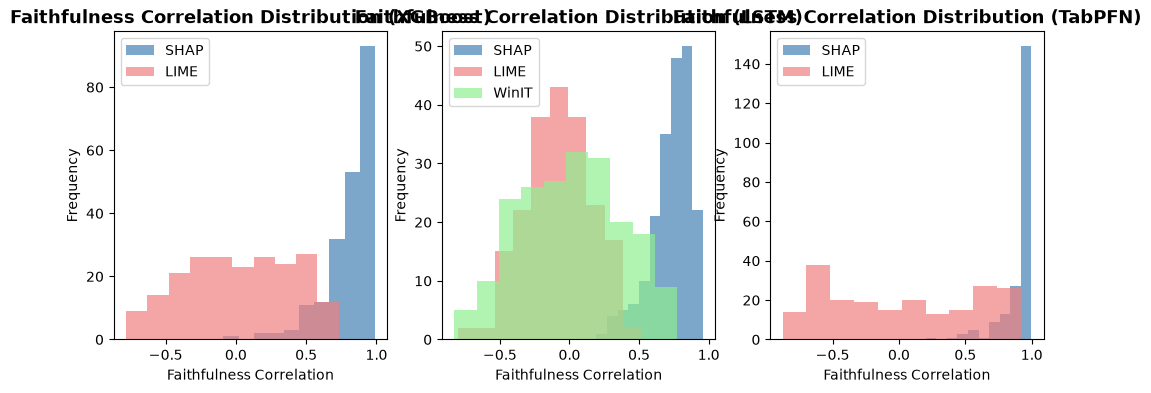

In [92]:
# Plots of Faithfulness Correlation distributions across methods for each model

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].hist(XGB_RESULTS_TEST1["Faithfulness_SHAP"], label='SHAP', color='steelblue', alpha=0.7)
axs[0].hist(XGB_RESULTS_TEST1["Faithfulness_LIME"], label='LIME', color='lightcoral', alpha=0.7)
axs[0].set_title('Faithfulness Correlation Distribution (XGBoost)', fontsize=13, fontweight='bold')
axs[0].set_xlabel('Faithfulness Correlation')
axs[0].set_ylabel('Frequency')
axs[0].legend()

axs[1].hist(LSTM_RESULTS_TEST1["Faithfulness_SHAP"], label='SHAP', color='steelblue', alpha=0.7)
axs[1].hist(LSTM_RESULTS_TEST1["Faithfulness_LIME"], label='LIME', color='lightcoral', alpha=0.7)
axs[1].hist(LSTM_RESULTS_TEST1["Faithfulness_WinIT"], label='WinIT', color='lightgreen', alpha=0.7)
axs[1].set_title('Faithfulness Correlation Distribution (LSTM)', fontsize=13, fontweight='bold')
axs[1].set_xlabel('Faithfulness Correlation')
axs[1].set_ylabel('Frequency')
axs[1].legend()

axs[2].hist(TABPFN_RESULTS_TEST1["Faithfulness_SHAP"], label='SHAP', color='steelblue', alpha=0.7)
axs[2].hist(TABPFN_RESULTS_TEST1["Faithfulness_LIME"], label='LIME', color='lightcoral', alpha=0.7)
axs[2].set_title('Faithfulness Correlation Distribution (TabPFN)', fontsize=13, fontweight='bold')
axs[2].set_xlabel('Faithfulness Correlation')
axs[2].set_ylabel('Frequency')
axs[2].legend()

## Local Lipschitz

In [93]:
# XAI Explanation Functions for Quantus stability metrics

shap_background_xgb = shap.kmeans(X_Train_xgb, 50)
def shap_explain_func(model, inputs, targets, **kwargs):
    x_flat = inputs.reshape(inputs.shape[0], -1)
    predict_fn = lambda x: model.booster.predict(x)
    expl = shap.KernelExplainer(predict_fn, shap_background_xgb)
    vals = expl.shap_values(x_flat, nsamples=500, silent=True)
    return np.array(vals)

shap_background_lstm = shap.kmeans(X_Train_lstm.reshape(X_Train_lstm.shape[0], -1), 50)
def shap_explain_func_lstm(model, inputs, targets, **kwargs):
    n_timesteps, n_features = X_Test1_lstm.shape[1], X_Test1_lstm.shape[2]

    def predict_fn(x_np):
        x_3d = x_np.reshape(-1, n_timesteps, n_features)   # undo SHAP's flattening
        with torch.no_grad():
            out = model(torch.tensor(x_3d, dtype=torch.float32).to(device))
        return out.detach().cpu().numpy().reshape(-1)

    expl = shap.KernelExplainer(predict_fn, shap_background_lstm)
    x_flat = inputs.reshape(inputs.shape[0], -1)
    vals = expl.shap_values(x_flat, nsamples=100, silent=True)
    return np.array(vals).reshape(inputs.shape)   # back to (n, timesteps, features) for Quantus

TABPFN_MODEL_SCALED = TabPFN_SCALED_WRAPPER()
def shap_explain_func_tabpfn(model, inputs, targets, **kwargs):
    x_flat = inputs.reshape(inputs.shape[0], -1)
    explainer_tabpfn = get_tabpfn_imputation_explainer(
            model=TABPFN_MODEL_SCALED,
            data=X_Train_scaled,       # background data
            index="SV",         # plain Shapley values (no interactions)
            max_order=1,
        )
    shap_vals = shapiq_to_shap_explanation(
        explainer=explainer_tabpfn,
        X=x_flat,
        budget=512,
        feature_names=features,
    ).values
    return np.array(shap_vals)

lime_explainer_xgb = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_xgb.values,
        feature_names=X_Train_xgb.columns.tolist(),
        mode='regression',           # not 'classification' — you're predicting returns
        discretize_continuous=False,
        random_state=42
    )
def lime_explain_func(model, inputs, targets, **kwargs):
    x_flat = inputs.reshape(inputs.shape[0], -1)
    attrs = []
    for i in range(x_flat.shape[0]):
        exp = lime_explainer_xgb.explain_instance(x_flat[i], model.booster.predict, num_features=len(features))
        arr = np.zeros(len(features))
        for idx, weight in exp.local_exp[1]:
            arr[idx] = weight
        attrs.append(arr)
    return np.array(attrs)

lime_explainer_lstm = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_lstm.reshape(X_Train_lstm.shape[0], -1),
        #feature_names=[f"{f}__lag{seq_len - t}" for t in range(seq_len) for f in features],
        mode='regression',
        discretize_continuous=False,   # matches XGB/TabPFN convention — see note on lag-binning caveat
        random_state=42
    )
def lime_explain_func_lstm(model, inputs, targets, **kwargs):
    n_timesteps, n_features = X_Test1_lstm.shape[1], X_Test1_lstm.shape[2]
    n_flat = n_timesteps * n_features
    
    x_flat = inputs.reshape(inputs.shape[0], -1)

    def predict_fn(x_np):
        x_3d = x_np.reshape(-1, n_timesteps, n_features)   # undo LIME's flattening
        with torch.no_grad():
            out = model(torch.tensor(x_3d, dtype=torch.float32).to(device))
        return out.detach().cpu().numpy().reshape(-1)

    attrs = []
    for i in range(x_flat.shape[0]):
        exp = lime_explainer_lstm.explain_instance(x_flat[i], predict_fn, num_features=n_flat)
        arr = np.zeros(n_flat)
        for idx, weight in exp.local_exp[1]:   # label=1 — matches as_list() sign convention
            arr[idx] = weight
        attrs.append(arr)

    return np.array(attrs).reshape(inputs.shape)

lime_explainer_tabpfn = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_Train_scaled.values,
        feature_names=features,
        mode='regression',           # not 'classification' — you're predicting returns
        discretize_continuous=False,
        random_state=42
    )
def lime_explain_func_tabpfn(model, inputs, targets, **kwargs):
    x_flat = inputs.reshape(inputs.shape[0], -1)

    def predict_fn(x_scaled):
        x_raw = model.scaler.inverse_transform(x_scaled)
        x_df = pd.DataFrame(x_raw, columns=model.feature_names)
        return model.model.predict(x_df)

    attrs = []
    for i in range(x_flat.shape[0]):
        exp = lime_explainer_tabpfn.explain_instance(
            x_flat[i], predict_fn, num_features=len(features), num_samples=500
        )
        arr = np.zeros(len(features))
        for feature_id, importance in exp.local_exp[1]:   # label=1 — matches as_list() sign convention
            arr[feature_id] = importance
        attrs.append(arr)

    return np.array(attrs)


def winit_explain_func_lstm(model, inputs, targets, **kwargs):
    n_timesteps = X_Test1_lstm.shape[1]

    x_t = torch.tensor(inputs, dtype=torch.float32, device=device)
    winit_explainer = WinIT(model, data=X_Train_lstm, seq_len=n_timesteps)  # numpy in, no manual conversion
    attr = winit_explainer.attribute(x_t)
    return attr.detach().cpu().numpy().squeeze(1)

In [94]:
# Initialise Quantus Local Lipschitz Estimate metric
local_lipschitz = quantus.LocalLipschitzEstimate(
    nr_samples=10,
    perturb_std=0.05,       # note: different param name than MaxSensitivity's lower_bound
    return_aggregate=False,
    disable_warnings=True,
    normalise=True,
)

In [95]:
if not use_saved_xai_eval:
    local_lipschitz_shap_xgb = local_lipschitz(
        model=XGB_MODEL_NN, x_batch=X_Test1_xgb_numpy, y_batch=y_batch_xgb,
        a_batch=None, explain_func=shap_explain_func, channel_first=True,
    )
    XGB_RESULTS_TEST1["Lipschitz_SHAP"] = local_lipschitz_shap_xgb
print(f"\nMean SHAP stability score: {np.mean(XGB_RESULTS_TEST1['Lipschitz_SHAP']):.4f}")

if not use_saved_xai_eval:
    local_lipschitz_lime_xgb = local_lipschitz(
        model=XGB_MODEL_NN, x_batch=X_Test1_xgb_numpy, y_batch=y_batch_xgb,
        a_batch=None, explain_func=lime_explain_func, channel_first=True,
    )
    XGB_RESULTS_TEST1["Lipschitz_LIME"] = local_lipschitz_lime_xgb
print(f"\nMean LIME stability score: {np.mean(XGB_RESULTS_TEST1['Lipschitz_LIME']):.4f}")


Mean SHAP stability score: 0.9186

Mean LIME stability score: 1.0521


In [96]:
if not use_saved_xai_eval:
    local_lipschitz_shap_lstm = local_lipschitz(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=None, explain_func=shap_explain_func_lstm, channel_first=True,
    )
    LSTM_RESULTS_TEST1["Lipschitz_SHAP"] = local_lipschitz_shap_lstm
print(f"\nMean SHAP stability score: {np.mean(LSTM_RESULTS_TEST1['Lipschitz_SHAP']):.4f}")

if not use_saved_xai_eval:
    local_lipschitz_lime_lstm = local_lipschitz(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=None, explain_func=lime_explain_func_lstm, channel_first=True,
    )
    LSTM_RESULTS_TEST1["Lipschitz_LIME"] = local_lipschitz_lime_lstm
print(f"\nMean LIME stability score: {np.mean(LSTM_RESULTS_TEST1['Lipschitz_LIME']):.4f}")

if not use_saved_xai_eval:
    local_lipschitz_winit_lstm = local_lipschitz(
        model=LSTM_MODEL_NN, x_batch=X_Test1_lstm, y_batch=y_batch_lstm,
        a_batch=None, explain_func=winit_explain_func_lstm, channel_first=True,
    )
    LSTM_RESULTS_TEST1["Lipschitz_WinIT"] = local_lipschitz_winit_lstm
print(f"\nMean WinIT stability score: {np.mean(LSTM_RESULTS_TEST1['Lipschitz_WinIT']):.4f}")


Mean SHAP stability score: 1.5056

Mean LIME stability score: 0.5034

Mean WinIT stability score: 1.3358


In [97]:
if not use_saved_xai_eval:
    local_lipschitz_shap_tabpfn = local_lipschitz(
        model=TABPFN_MODEL_NN, x_batch=X_Test1_tabpfn_numpy, y_batch=y_batch_tabpfn,
        a_batch=None, explain_func=shap_explain_func_tabpfn, channel_first=True,
    )
    TABPFN_RESULTS_TEST1["Lipschitz_SHAP"] = local_lipschitz_shap_tabpfn
print(f"\nMean SHAP stability score: {np.mean(TABPFN_RESULTS_TEST1['Lipschitz_SHAP']):.4f}")

if not use_saved_xai_eval:
    local_lipschitz_lime_tabpfn = local_lipschitz(
        model=TABPFN_MODEL_NN, x_batch=X_Test1_tabpfn_numpy, y_batch=y_batch_tabpfn,
        a_batch=None, explain_func=lime_explain_func_tabpfn, channel_first=True,
    )
    TABPFN_RESULTS_TEST1["Lipschitz_LIME"] = local_lipschitz_lime_tabpfn
print(f"\nMean LIME stability score: {np.mean(TABPFN_RESULTS_TEST1['Lipschitz_LIME']):.4f}")


Mean SHAP stability score: 0.2775

Mean LIME stability score: 1.0283


In [98]:
if not use_saved_xai_eval:
    local_lipschitz_results = pd.DataFrame({
        "XGBoost": [XGB_RESULTS_TEST1["Lipschitz_SHAP"].mean(), XGB_RESULTS_TEST1["Lipschitz_LIME"].mean(), None],
        "LSTM": [LSTM_RESULTS_TEST1["Lipschitz_SHAP"].mean(), LSTM_RESULTS_TEST1["Lipschitz_LIME"].mean(), LSTM_RESULTS_TEST1["Lipschitz_WinIT"].mean()],
        "TabPFN": [TABPFN_RESULTS_TEST1["Lipschitz_SHAP"].mean(), TABPFN_RESULTS_TEST1["Lipschitz_LIME"].mean(), None],
    }, index=["SHAP", "LIME", "WinIT"])
    display(local_lipschitz_results.round(3))

,XGBoost,LSTM,TabPFN
SHAP,0.919,1.506,0.278
LIME,1.052,0.503,1.028
WinIT,NaN,1.336,NaN


## Save

In [99]:
if save_xai and not use_saved_xai_eval:
    XGB_RESULTS_TEST1.to_csv('Outputs/Model Results/XGB_RESULTS_TEST1.csv')
    LSTM_RESULTS_TEST1.to_csv('Outputs/Model Results/LSTM_RESULTS_TEST1.csv')
    TABPFN_RESULTS_TEST1.to_csv('Outputs/Model Results/TABPFN_RESULTS_TEST1.csv')

    global_faithfulness_results.to_csv("Outputs/XAI Evaluation/Faithfulness Results.csv", index=True)
    local_lipschitz_results.to_csv("Outputs/XAI Evaluation/Stability Results.csv", index=True)

# Global Analysis

## SHAP

### XGBoost

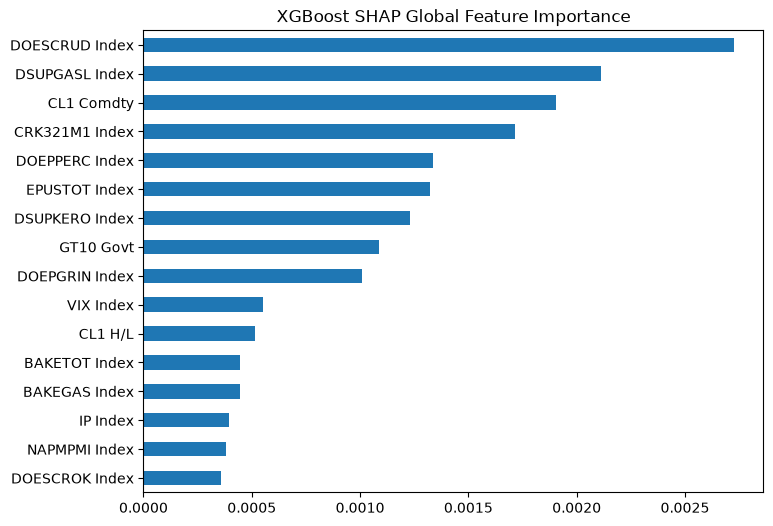

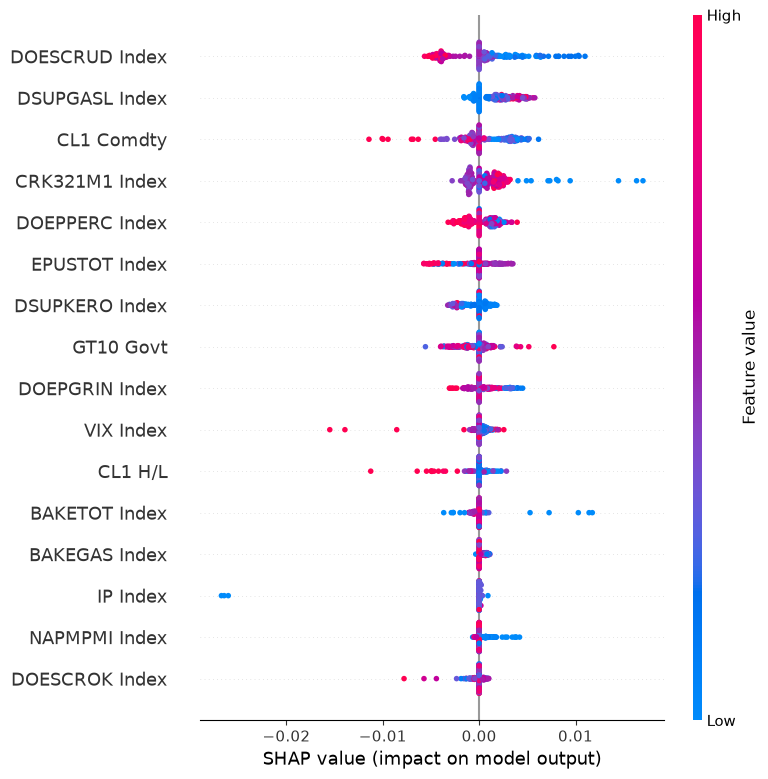

In [100]:
# Global SHAP importance for XGBoost

global_shap_xgb = XGB_RESULTS_TEST1[shap_features].abs().mean()
global_shap_xgb.index = features
global_shap_xgb.sort_values(ascending=True, inplace=True)
global_shap_xgb.plot(kind='barh', figsize=(8, 6), title="XGBoost SHAP Global Feature Importance")
plt.show()

shap.summary_plot(XGB_RESULTS_TEST1[shap_features].values, features=X_Test1, feature_names=features)

### LSTM

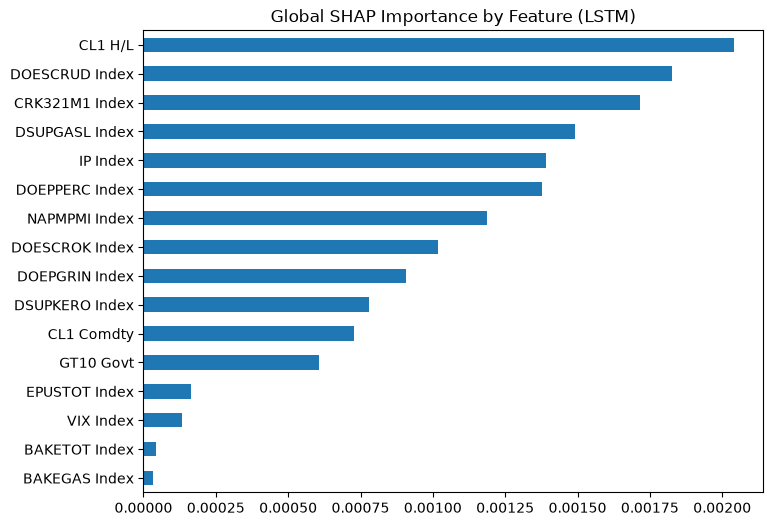

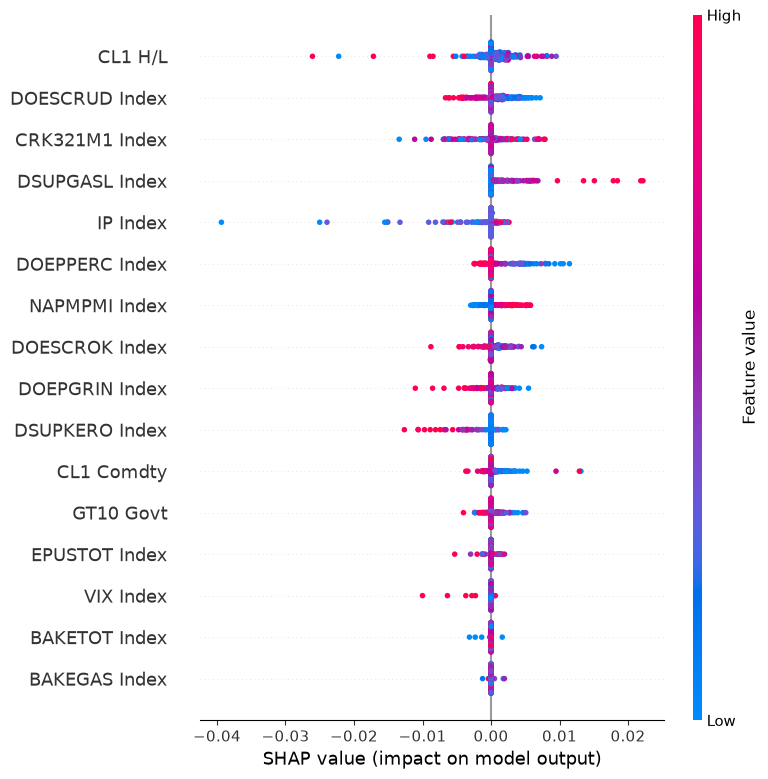

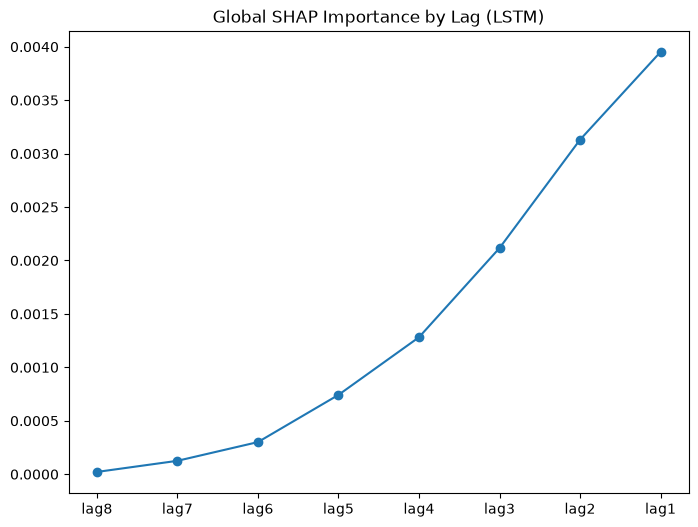

In [101]:
# Global SHAP importance for LSTM

shap_lstm_3d_test1 = np.array(LSTM_RESULTS_TEST1[shap_features_lags]).reshape(len(LSTM_RESULTS_TEST1), lstm_params["SEQ_LEN"], len(features))
shap_lstm_by_feature_signed = shap_lstm_3d_test1.sum(axis=1) # Aggregate SHAP values across all lags for each feature
shap_lstm_by_lag_signed = shap_lstm_3d_test1.sum(axis=2) # Aggregate SHAP values across all features for each lag

global_shap_lstm_by_feature = LSTM_RESULTS_TEST1[shap_features].abs().mean()
global_shap_lstm_by_feature.index = features
global_shap_lstm_by_feature.sort_values(ascending=True, inplace=True)
global_shap_lstm_by_feature.plot.barh(x='feature', y='mean_abs_shap', figsize=(8, 6), title='Global SHAP Importance by Feature (LSTM)')
plt.show()
shap.summary_plot(LSTM_RESULTS_TEST1[shap_features].values, features=X_Test1_lstm[:, -1, :], feature_names=features)

global_shap_lstm_by_lag = LSTM_RESULTS_TEST1[shap_lags].abs().mean()
global_shap_lstm_by_lag.index = [f'lag{t}' for t in range(lstm_params["SEQ_LEN"], 0, -1)]
global_shap_lstm_by_lag.plot(x='lag', y='mean_abs_shap', figsize=(8, 6), title='Global SHAP Importance by Lag (LSTM)', marker='o')
plt.show()

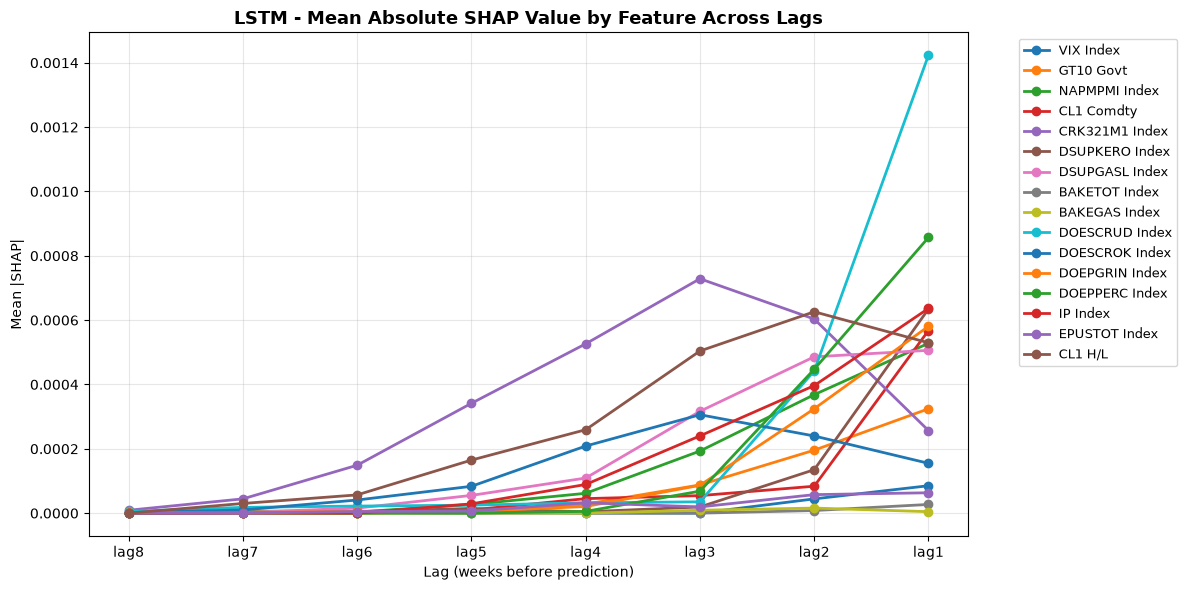

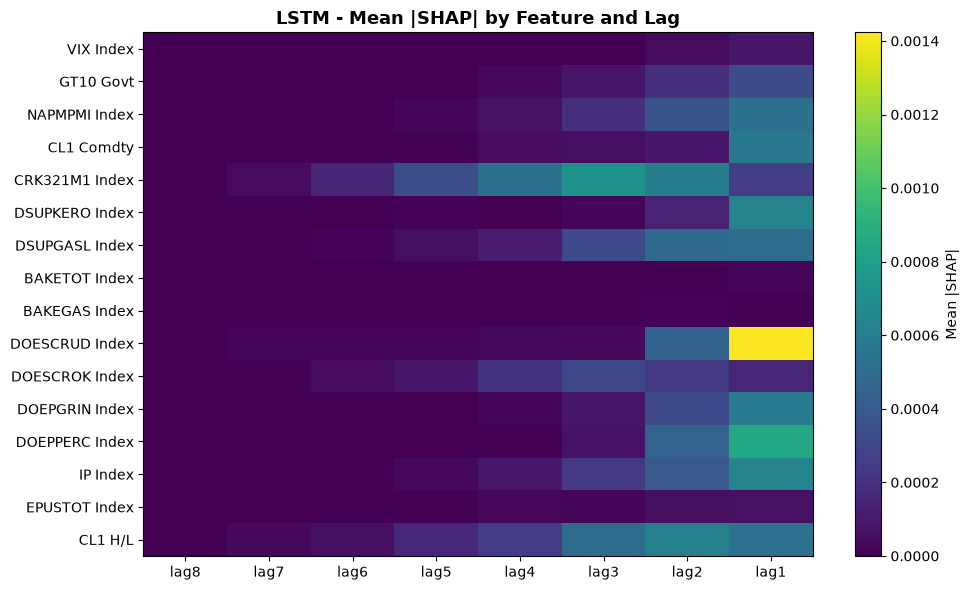

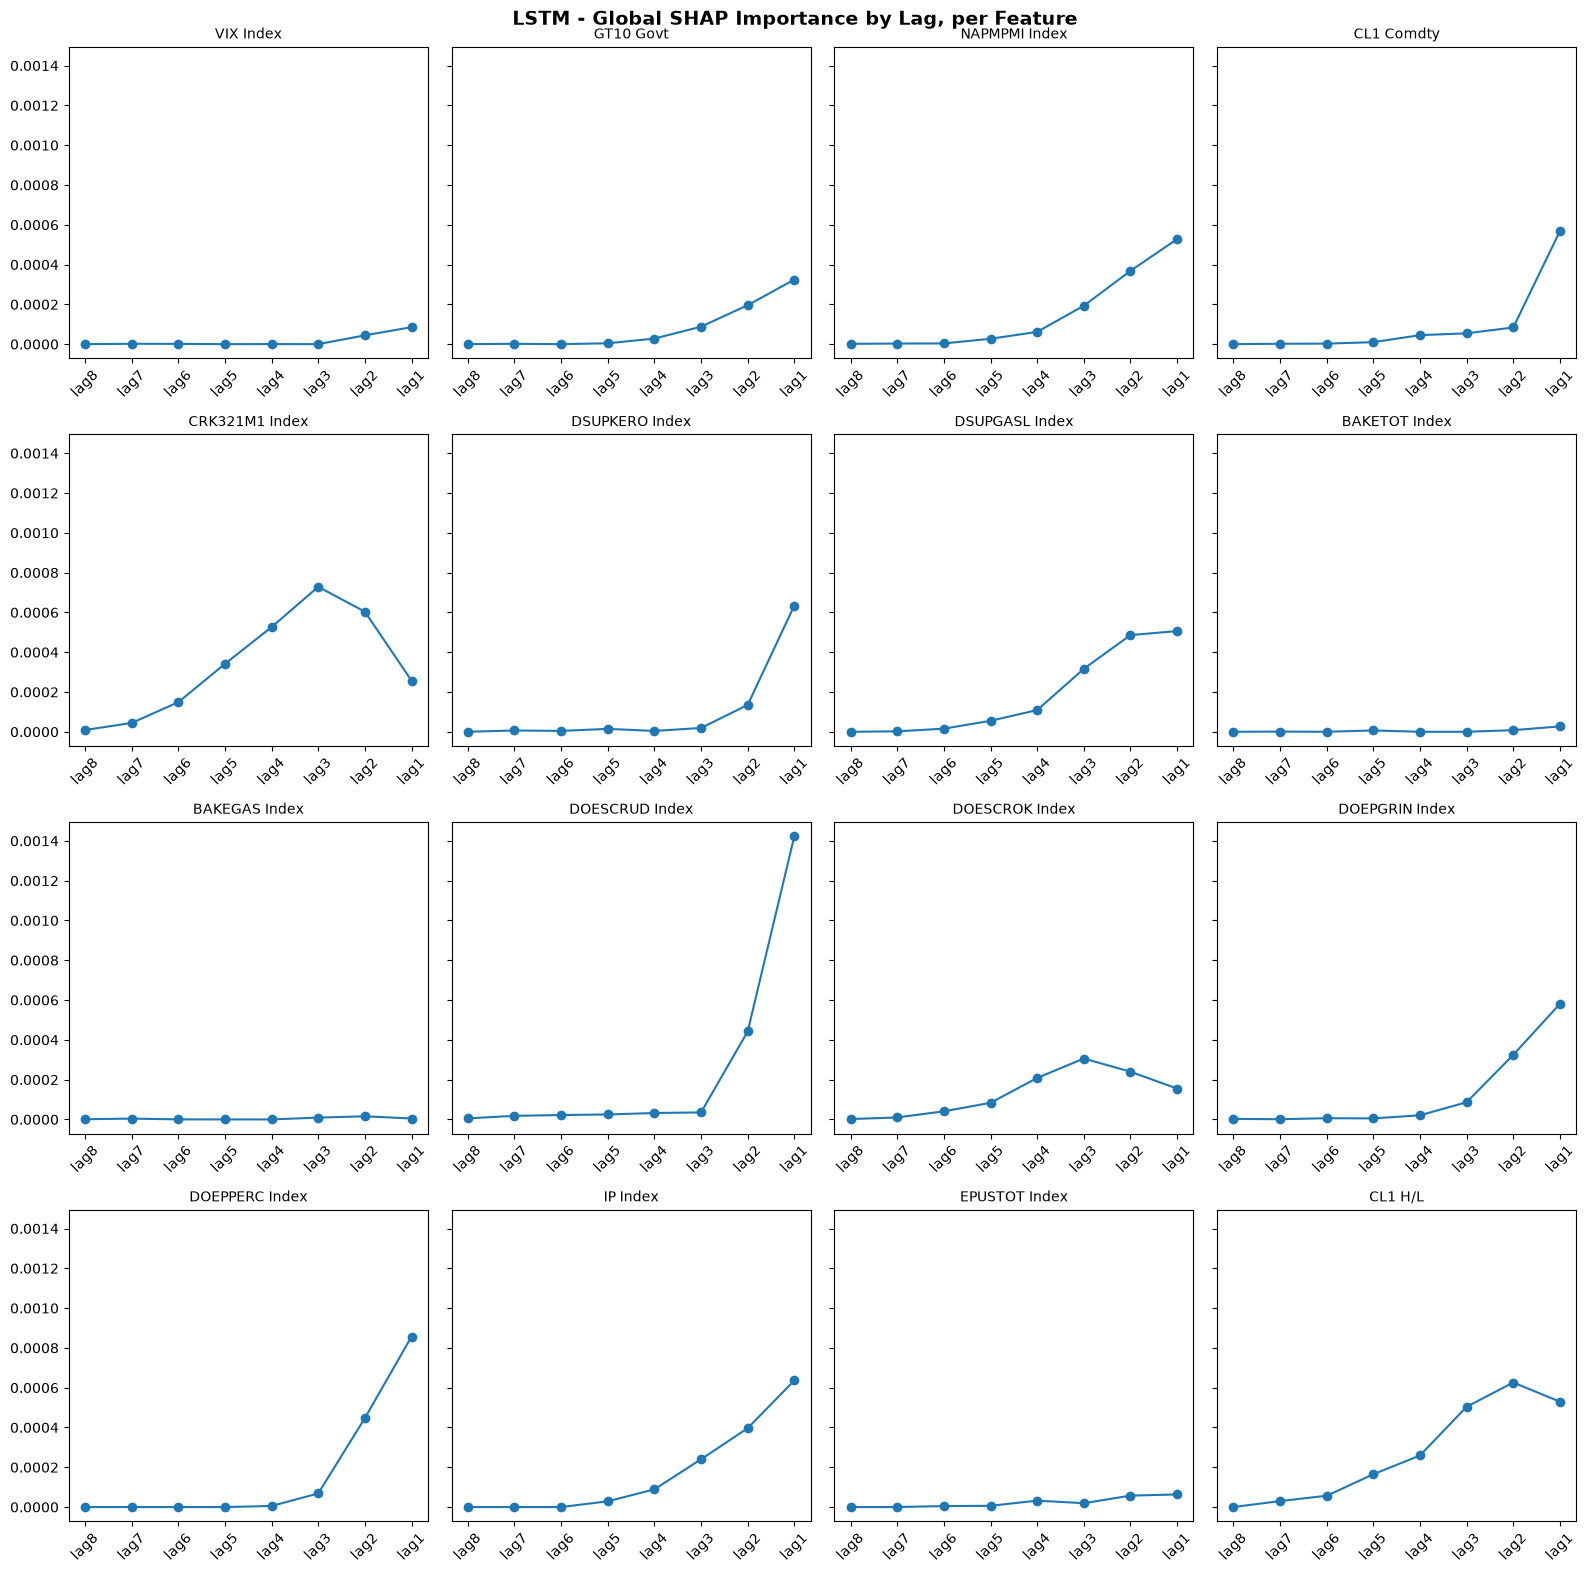

In [102]:
# Global SHAP importance by feature and lag (LSTM)
lags = list(range(lstm_params["SEQ_LEN"], 0, -1))  # oldest (lag 8) to most recent (lag 1)

shap_by_feature_lag = pd.DataFrame({
    f: [LSTM_RESULTS_TEST1[f'shap__{f}__lag{lag}'].abs().mean() for lag in lags]
    for f in features
}, index=[f'lag {lag}' for lag in lags])

# Line plots
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(lags))
for feature in features:
    ax.plot(x, shap_by_feature_lag[feature], marker='o', linewidth=2, label=feature)
ax.set_title('LSTM - Mean Absolute SHAP Value by Feature Across Lags', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag (weeks before prediction)')
ax.set_ylabel('Mean |SHAP|')
ax.set_xticks(x)
ax.set_xticklabels([f'lag{lag}' for lag in lags])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(shap_by_feature_lag.T, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([f'lag{lag}' for lag in lags])
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)
ax.set_title('LSTM - Mean |SHAP| by Feature and Lag', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()

# Individual bar plots
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
lags = range(lstm_params["SEQ_LEN"], 0, -1)   # lag8 → lag1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True)
axes = axes.flatten()

for idx, f in enumerate(features):
    ax = axes[idx]
    lag_means = [
        LSTM_RESULTS_TEST1[f'shap__{f}__lag{lag}'].abs().mean()
        for lag in lags
    ]
    ax.plot([f'lag{lag}' for lag in lags], lag_means, marker='o')
    ax.set_title(f, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('LSTM - Global SHAP Importance by Lag, per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

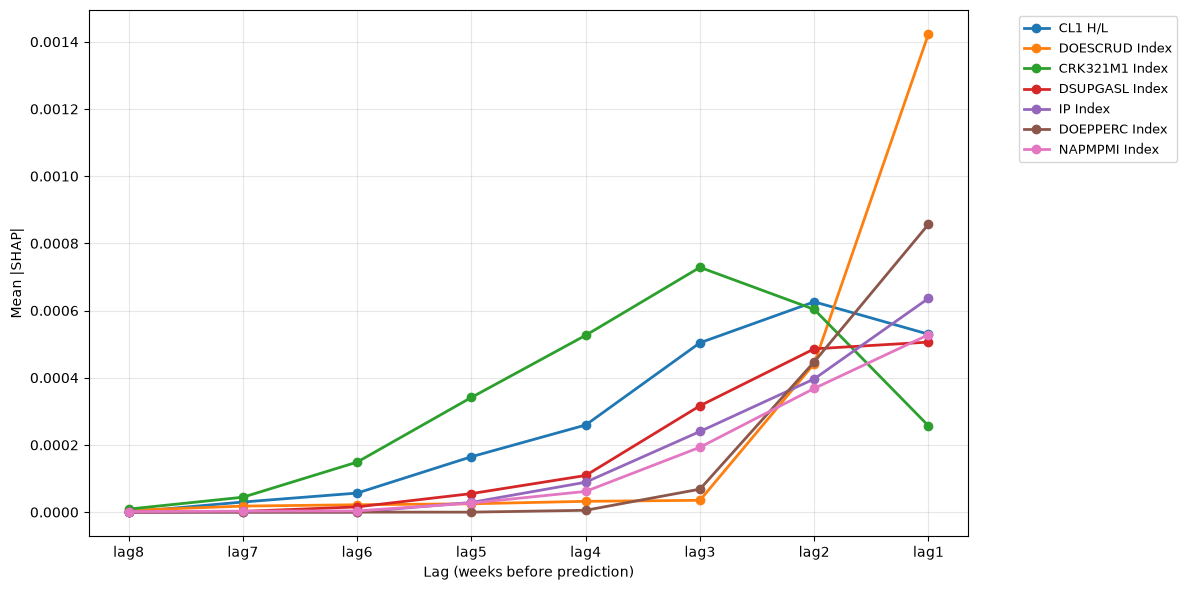

In [103]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(lags))
for feature in global_shap_lstm_by_feature[:8:-1].index:
    ax.plot(x, shap_by_feature_lag[feature], marker='o', linewidth=2, label=feature)
ax.set_xlabel('Lag (weeks before prediction)')
ax.set_ylabel('Mean |SHAP|')
ax.set_xticks(x)
ax.set_xticklabels([f'lag{lag}' for lag in lags])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Images/LSTM SHAP Importance by Lag Top 8 Features.png', dpi=300)
plt.show()

### TabPFN

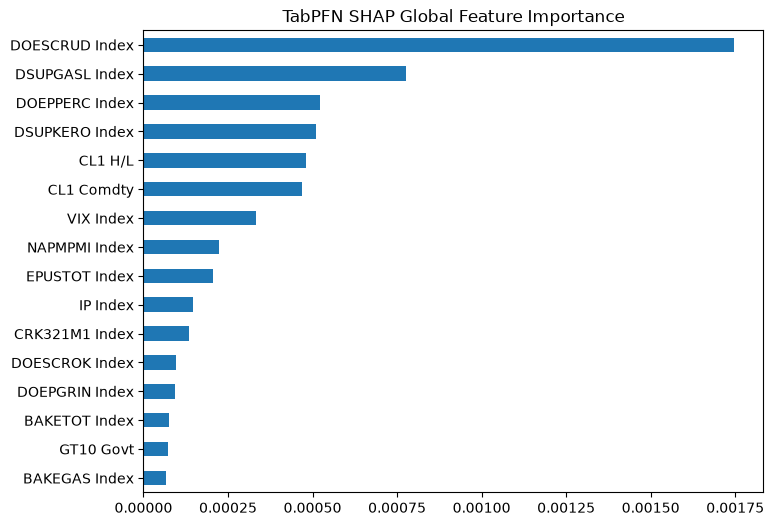

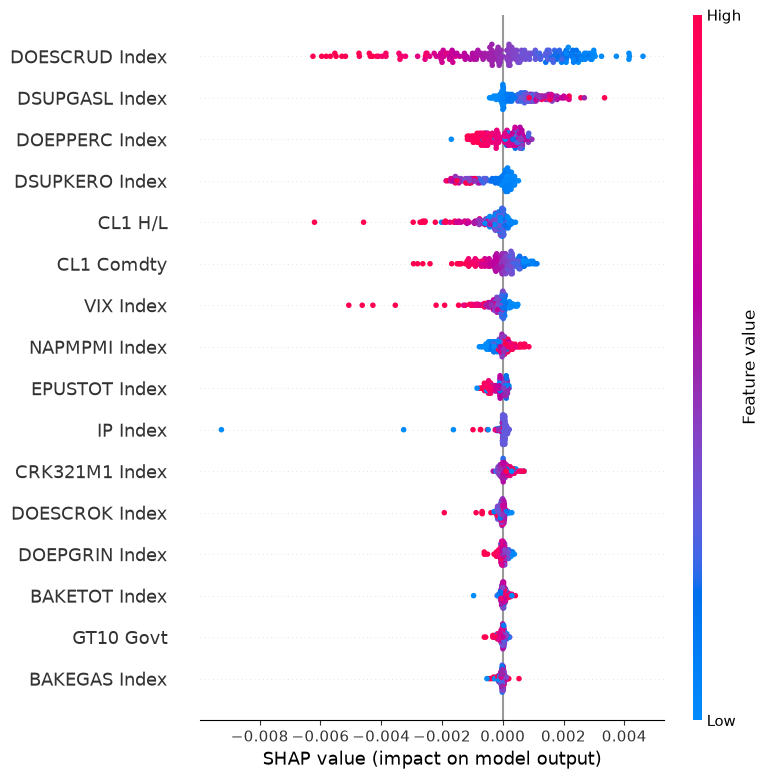

In [104]:
# Global SHAP importance for TabPFN

global_shap_tabpfn = TABPFN_RESULTS_TEST1[shap_features].abs().mean()
global_shap_tabpfn.index = features
global_shap_tabpfn.sort_values(ascending=True, inplace=True)
global_shap_tabpfn.plot(kind='barh', figsize=(8, 6), title="TabPFN SHAP Global Feature Importance")
plt.show()

shap.summary_plot(TABPFN_RESULTS_TEST1[shap_features].values, features=X_Test1, feature_names=features)

### Cross-Model Agreement

,XGBoost,LSTM,TabPFN
1,DOESCRUD Index,CL1 H/L,DOESCRUD Index
2,DSUPGASL Index,DOESCRUD Index,DSUPGASL Index
3,CL1 Comdty,CRK321M1 Index,DOEPPERC Index
4,CRK321M1 Index,DSUPGASL Index,DSUPKERO Index
5,DOEPPERC Index,IP Index,CL1 H/L
6,EPUSTOT Index,DOEPPERC Index,CL1 Comdty
7,DSUPKERO Index,NAPMPMI Index,VIX Index
8,GT10 Govt,DOESCROK Index,NAPMPMI Index
9,DOEPGRIN Index,DOEPGRIN Index,EPUSTOT Index
10,VIX Index,DSUPKERO Index,IP Index


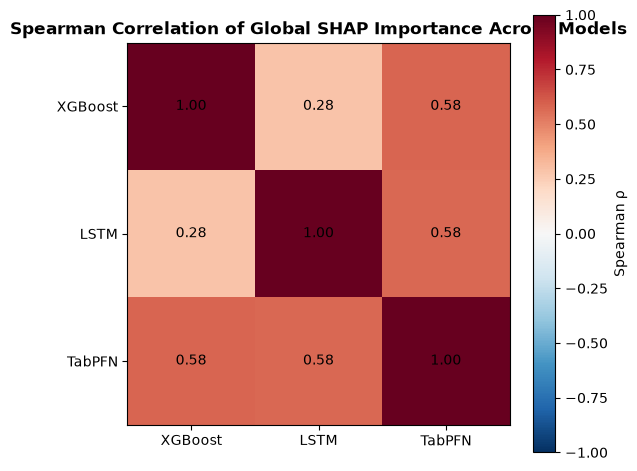

XGBoost vs LSTM: rho=0.282, p=0.289
XGBoost vs TabPFN: rho=0.582, p=0.018
LSTM vs TabPFN: rho=0.576, p=0.019


In [105]:
# Cross-model agreement in SHAP importance rankings
global_shap = pd.DataFrame({
    'XGBoost':     global_shap_xgb,
    'LSTM':    global_shap_lstm_by_feature,
    'TabPFN':  global_shap_tabpfn,
})
global_shap_rankings = pd.DataFrame({
    'XGBoost': global_shap_xgb.index,
    'LSTM': global_shap_lstm_by_feature.index,
    'TabPFN': global_shap_tabpfn.index,
})
global_shap_rankings = global_shap_rankings.apply(lambda x: x[::-1])
global_shap_rankings.index = range(1, len(global_shap_rankings) + 1)
display(global_shap_rankings)

corr_matrix = global_shap.corr(method='spearman') # spearman correlation for rank-based agreement

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Spearman Correlation of Global SHAP Importance Across Models', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Spearman ρ')
plt.tight_layout()
plt.show()

# p-values
for m1, m2 in combinations(global_shap.columns, 2):
    rho, p = spearmanr(global_shap[m1], global_shap[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

## LIME

### XGBoost

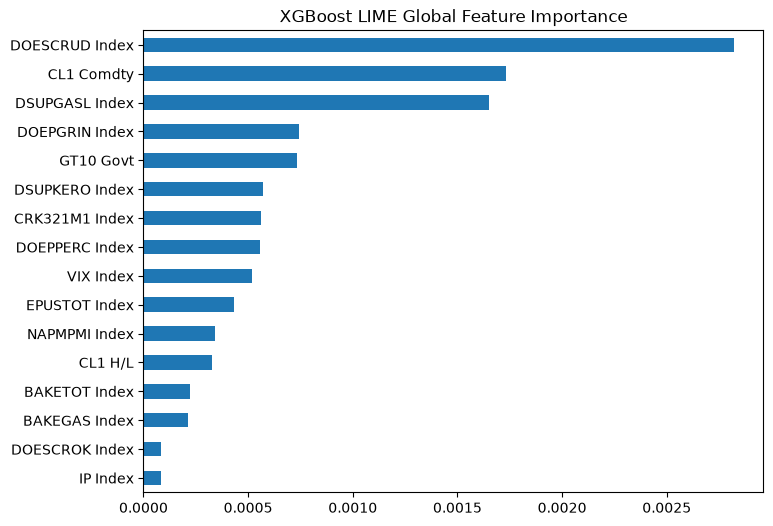

In [106]:
# Global LIME importance for XGBoost
global_lime_xgb = XGB_RESULTS_TEST1[lime_features].abs().mean()
global_lime_xgb.index = features
global_lime_xgb.sort_values(ascending=True, inplace=True)
global_lime_xgb.plot(kind='barh', figsize=(8, 6), title="XGBoost LIME Global Feature Importance")
plt.show()

### LSTM

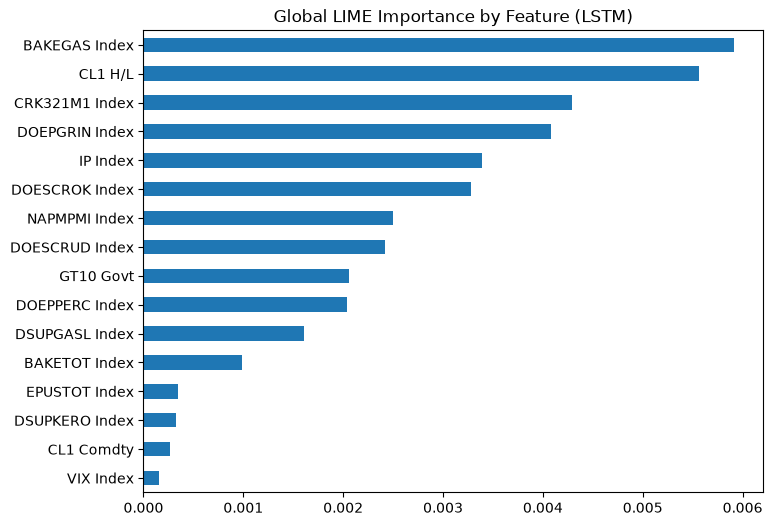

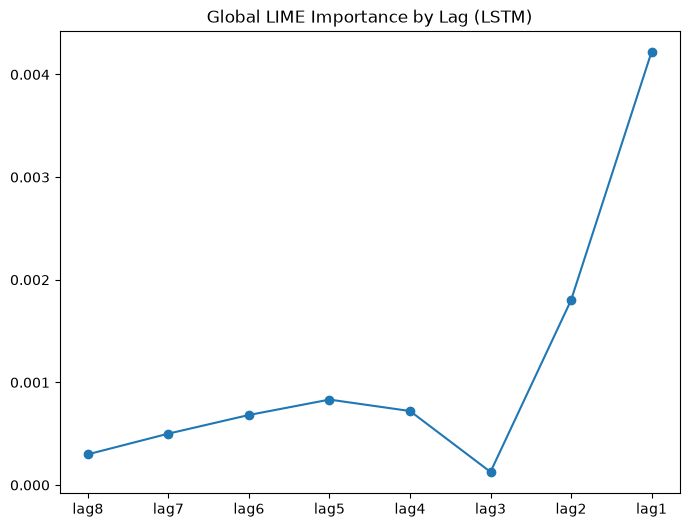

In [107]:
# Global LIME importance for LSTM

lime_lstm_3d_test1 = np.array(LSTM_RESULTS_TEST1[lime_features_lags]).reshape(len(LSTM_RESULTS_TEST1), lstm_params["SEQ_LEN"], len(features))
lime_lstm_by_feature_signed = lime_lstm_3d_test1.sum(axis=1)
lime_lstm_by_lag_signed = lime_lstm_3d_test1.sum(axis=2)

global_lime_lstm_by_feature = LSTM_RESULTS_TEST1[lime_features].mean()
global_lime_lstm_by_feature.index = features
global_lime_lstm_by_feature.sort_values(ascending=True, inplace=True)
global_lime_lstm_by_feature.plot.barh(x='feature', y='mean_abs_lime', figsize=(8, 6), title='Global LIME Importance by Feature (LSTM)')
plt.show()

global_lime_lstm_by_lag = LSTM_RESULTS_TEST1[lime_lags].mean()
global_lime_lstm_by_lag.index = [f'lag{t}' for t in range(lstm_params["SEQ_LEN"], 0, -1)]
global_lime_lstm_by_lag.plot(x='lag', y='mean_abs_lime', figsize=(8, 6), title='Global LIME Importance by Lag (LSTM)', marker='o')
plt.show()

### TabPFN

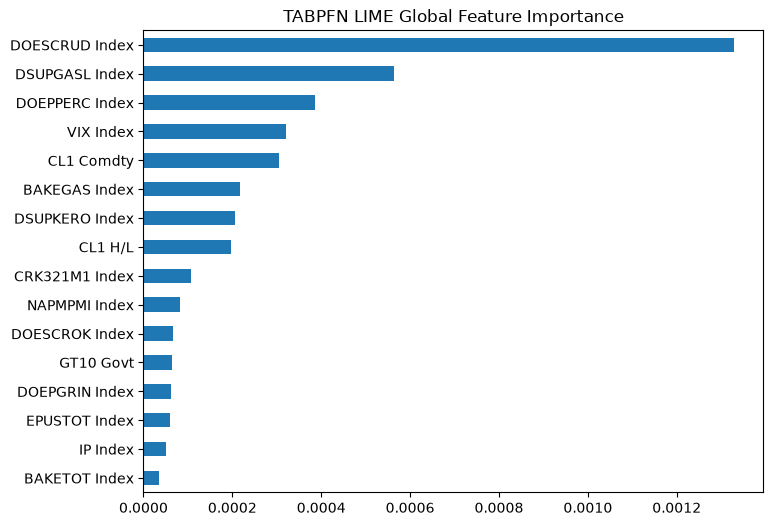

In [108]:
# Global LIME importance for TabPFN
global_lime_tabpfn = TABPFN_RESULTS_TEST1[lime_features].abs().mean()
global_lime_tabpfn.index = features
global_lime_tabpfn.sort_values(ascending=True, inplace=True)
global_lime_tabpfn.plot(kind='barh', figsize=(8, 6), title="TABPFN LIME Global Feature Importance")
plt.show()

### Cross-Model Agreement

,XGBoost,LSTM,TabPFN
1,DOESCRUD Index,BAKEGAS Index,DOESCRUD Index
2,CL1 Comdty,CL1 H/L,DSUPGASL Index
3,DSUPGASL Index,CRK321M1 Index,DOEPPERC Index
4,DOEPGRIN Index,DOEPGRIN Index,VIX Index
5,GT10 Govt,IP Index,CL1 Comdty
6,DSUPKERO Index,DOESCROK Index,BAKEGAS Index
7,CRK321M1 Index,NAPMPMI Index,DSUPKERO Index
8,DOEPPERC Index,DOESCRUD Index,CL1 H/L
9,VIX Index,GT10 Govt,CRK321M1 Index
10,EPUSTOT Index,DOEPPERC Index,NAPMPMI Index


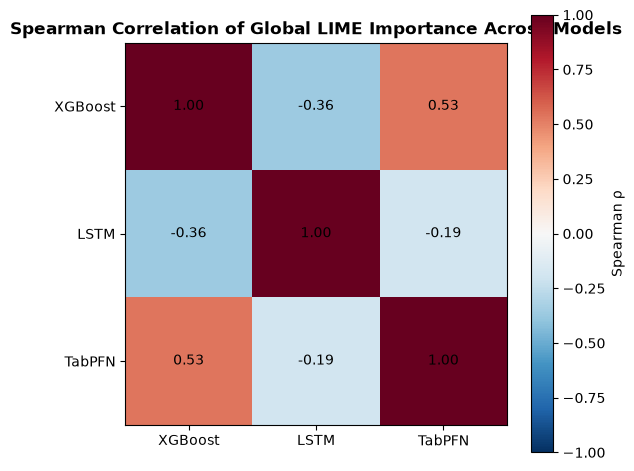

XGBoost vs LSTM: rho=-0.365, p=0.165
XGBoost vs TabPFN: rho=0.532, p=0.034
LSTM vs TabPFN: rho=-0.191, p=0.478


In [109]:
# Cross-model agreement in LIME importance rankings

global_lime = pd.DataFrame({
    'XGBoost': global_lime_xgb,
    'LSTM':    global_lime_lstm_by_feature,
    'TabPFN':  global_lime_tabpfn,
})
global_lime_rankings = pd.DataFrame({
    'XGBoost': global_lime_xgb.index,
    'LSTM': global_lime_lstm_by_feature.index,
    'TabPFN': global_lime_tabpfn.index,
})
global_lime_rankings = global_lime_rankings.apply(lambda x: x[::-1])
global_lime_rankings.index = range(1, len(global_lime_rankings) + 1)
display(global_lime_rankings)

corr_matrix = global_lime.corr(method='spearman') # spearman correlation for rank-based agreement

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Spearman Correlation of Global LIME Importance Across Models', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Spearman ρ')
plt.tight_layout()
plt.show()

# p-values
for m1, m2 in combinations(global_lime.columns, 2):
    rho, p = spearmanr(global_lime[m1], global_lime[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

## WinIT (LSTM)

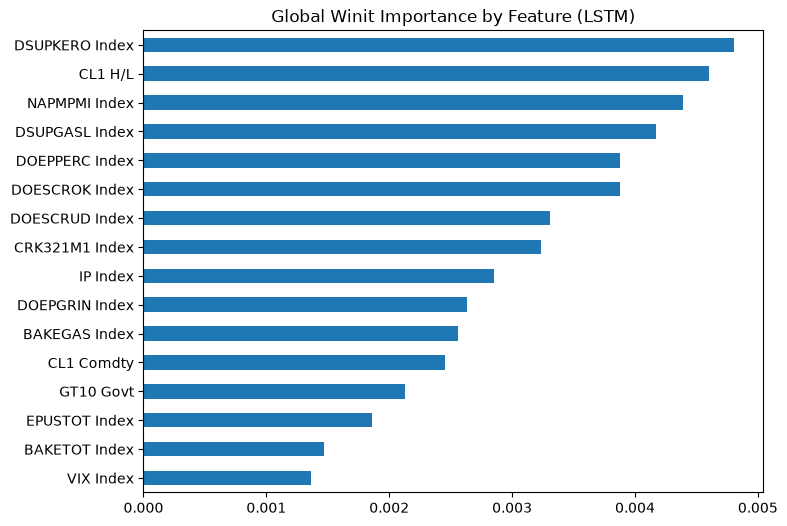

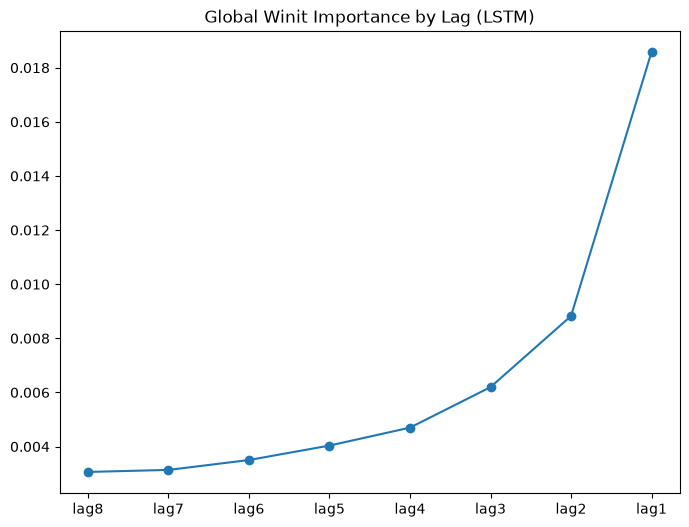

In [110]:
# Global WinIT importance for LSTM

winit_lstm_3d_test1 = np.array(LSTM_RESULTS_TEST1[winit_features_lags]).reshape(len(LSTM_RESULTS_TEST1), lstm_params["SEQ_LEN"], len(features))
winit_lstm_by_feature_signed = winit_lstm_3d_test1.sum(axis=1)
winit_lstm_by_lag_signed = winit_lstm_3d_test1.sum(axis=2)

global_winit_lstm_by_feature = LSTM_RESULTS_TEST1[winit_features].mean()
global_winit_lstm_by_feature.index = features
global_winit_lstm_by_feature.sort_values(ascending=True, inplace=True)
global_winit_lstm_by_feature.plot.barh(x='feature', y='mean_abs_winit', figsize=(8, 6), title='Global Winit Importance by Feature (LSTM)')
plt.show()

global_winit_lstm_by_lag = LSTM_RESULTS_TEST1[winit_lags].mean()
global_winit_lstm_by_lag.index = [f'lag{t}' for t in range(lstm_params["SEQ_LEN"], 0, -1)]
global_winit_lstm_by_lag.plot(x='lag', y='mean_abs_winit', figsize=(8, 6), title='Global Winit Importance by Lag (LSTM)', marker='o')
plt.show()

## Cross-Method Agreement

In [111]:
# Cross-method agreement in feature importance rankings for XGBoost - SHAP vs LIME

global_xgb = pd.DataFrame({
    "SHAP": global_shap_xgb,
    "LIME": global_lime_xgb
})
global_xgb_rankings = pd.DataFrame({
    'SHAP': global_shap_xgb.index,
    'LIME': global_lime_xgb.index
})
global_xgb_rankings = global_xgb_rankings.apply(lambda x: x[::-1])
global_xgb_rankings.index = range(1, len(global_xgb_rankings) + 1)
display(global_xgb_rankings)

# p-values
for m1, m2 in combinations(global_xgb.columns, 2):
    rho, p = spearmanr(global_xgb[m1], global_xgb[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

,SHAP,LIME
1,DOESCRUD Index,DOESCRUD Index
2,DSUPGASL Index,CL1 Comdty
3,CL1 Comdty,DSUPGASL Index
4,CRK321M1 Index,DOEPGRIN Index
5,DOEPPERC Index,GT10 Govt
6,EPUSTOT Index,DSUPKERO Index
7,DSUPKERO Index,CRK321M1 Index
8,GT10 Govt,DOEPPERC Index
9,DOEPGRIN Index,VIX Index
10,VIX Index,EPUSTOT Index


SHAP vs LIME: rho=0.859, p=0.000


,SHAP,LIME,WinIT
1,CL1 H/L,BAKEGAS Index,DSUPKERO Index
2,DOESCRUD Index,CL1 H/L,CL1 H/L
3,CRK321M1 Index,CRK321M1 Index,NAPMPMI Index
4,DSUPGASL Index,DOEPGRIN Index,DSUPGASL Index
5,IP Index,IP Index,DOEPPERC Index
6,DOEPPERC Index,DOESCROK Index,DOESCROK Index
7,NAPMPMI Index,NAPMPMI Index,DOESCRUD Index
8,DOESCROK Index,DOESCRUD Index,CRK321M1 Index
9,DOEPGRIN Index,GT10 Govt,IP Index
10,DSUPKERO Index,DOEPPERC Index,DOEPGRIN Index


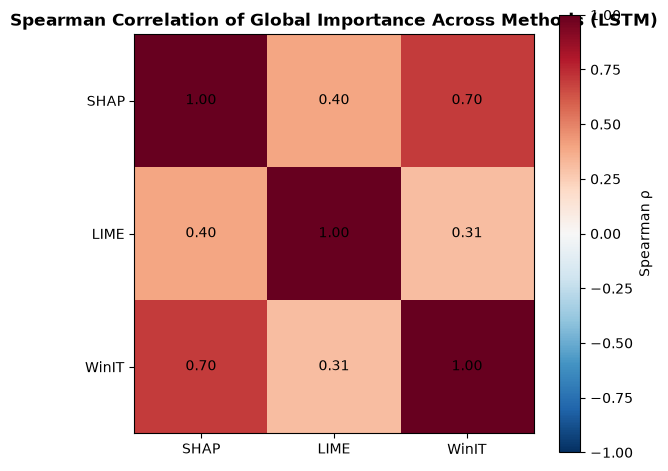

SHAP vs LIME: rho=0.397, p=0.128
SHAP vs WinIT: rho=0.703, p=0.002
LIME vs WinIT: rho=0.306, p=0.249


In [112]:
# Cross-method agreement in feature importance rankings for LSTM - SHAP vs LIME vs WinIT
global_lstm = pd.DataFrame({
    "SHAP": global_shap_lstm_by_feature,
    "LIME": global_lime_lstm_by_feature,
    "WinIT": global_winit_lstm_by_feature,
})
global_lstm_rankings = pd.DataFrame({
    'SHAP': global_shap_lstm_by_feature.index,
    'LIME': global_lime_lstm_by_feature.index,
    "WinIT" : global_winit_lstm_by_feature.index,
})
global_lstm_rankings = global_lstm_rankings.apply(lambda x: x[::-1])
global_lstm_rankings.index = range(1, len(global_lstm_rankings) + 1)
display(global_lstm_rankings)

corr_matrix = global_lstm.corr(method='spearman')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Spearman Correlation of Global Importance Across Methods (LSTM)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Spearman ρ')
plt.tight_layout()
plt.show()

# p-values
for m1, m2 in combinations(global_lstm.columns, 2):
    rho, p = spearmanr(global_lstm[m1], global_lstm[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

,SHAP,LIME,WinIT
1,lag1,lag1,lag1
2,lag2,lag2,lag2
3,lag3,lag5,lag3
4,lag4,lag4,lag4
5,lag5,lag6,lag5
6,lag6,lag7,lag6
7,lag7,lag8,lag7
8,lag8,lag3,lag8


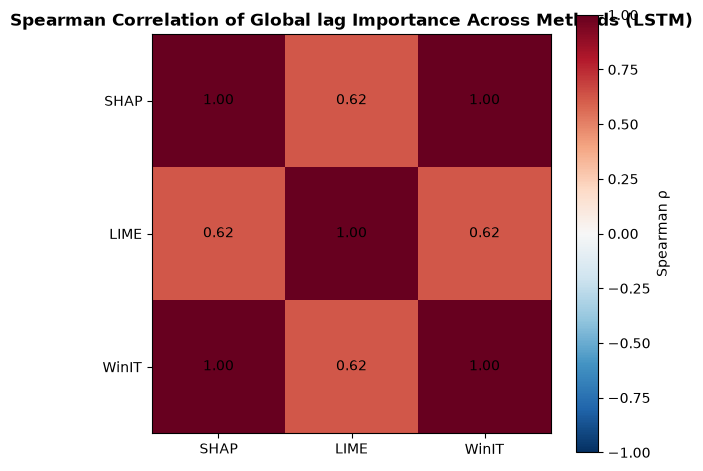

SHAP vs LIME: rho=0.619, p=0.102
SHAP vs WinIT: rho=1.000, p=0.000
LIME vs WinIT: rho=0.619, p=0.102


In [113]:
# Cross-method agreement in lag importance rankings for LSTM - SHAP vs LIME vs WinIT
global_lstm_lags = pd.DataFrame({
    "SHAP": global_shap_lstm_by_lag,
    "LIME": global_lime_lstm_by_lag,
    "WinIT": global_winit_lstm_by_lag,
})
global_lstm_lags_rankings = pd.DataFrame({
    'SHAP': global_shap_lstm_by_lag.sort_values(ascending=False).index,
    'LIME': global_lime_lstm_by_lag.sort_values(ascending=False).index,
    "WinIT" : global_winit_lstm_by_lag.sort_values(ascending=False).index,
})
global_lstm_lags_rankings.index = range(1, len(global_lstm_lags_rankings) + 1)
display(global_lstm_lags_rankings)

corr_matrix = global_lstm_lags.corr(method='spearman')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Spearman Correlation of Global lag Importance Across Methods (LSTM)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Spearman ρ')
plt.tight_layout()
plt.show()

# p-values
for m1, m2 in combinations(global_lstm_lags.columns, 2):
    rho, p = spearmanr(global_lstm_lags[m1], global_lstm_lags[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

In [114]:
# Cross-method agreement in feature importance rankings for TabPFN - SHAP vs LIME
global_tabpfn = pd.DataFrame({
    "SHAP": global_shap_tabpfn,
    "LIME": global_lime_tabpfn
})
global_tabpfn_rankings = pd.DataFrame({
    'SHAP': global_shap_tabpfn.index,
    'LIME': global_lime_tabpfn.index
})
global_tabpfn_rankings = global_tabpfn_rankings.apply(lambda x: x[::-1])
global_tabpfn_rankings.index = range(1, len(global_tabpfn_rankings) + 1)
display(global_tabpfn_rankings)

# p-values
for m1, m2 in combinations(global_tabpfn.columns, 2):
    rho, p = spearmanr(global_tabpfn[m1], global_tabpfn[m2])
    print(f"{m1} vs {m2}: rho={rho:.3f}, p={p:.3f}")

,SHAP,LIME
1,DOESCRUD Index,DOESCRUD Index
2,DSUPGASL Index,DSUPGASL Index
3,DOEPPERC Index,DOEPPERC Index
4,DSUPKERO Index,VIX Index
5,CL1 H/L,CL1 Comdty
6,CL1 Comdty,BAKEGAS Index
7,VIX Index,DSUPKERO Index
8,NAPMPMI Index,CL1 H/L
9,EPUSTOT Index,CRK321M1 Index
10,IP Index,NAPMPMI Index


SHAP vs LIME: rho=0.706, p=0.002


## Overall

,XGBoost SHAP,XGBoost LIME,LSTM SHAP,LSTM LIME,LSTM WinIT,TabPFN SHAP,TabPFN LIME
1,DOESCRUD Index,DOESCRUD Index,CL1 H/L,BAKEGAS Index,DSUPKERO Index,DOESCRUD Index,DOESCRUD Index
2,DSUPGASL Index,CL1 Comdty,DOESCRUD Index,CL1 H/L,CL1 H/L,DSUPGASL Index,DSUPGASL Index
3,CL1 Comdty,DSUPGASL Index,CRK321M1 Index,CRK321M1 Index,NAPMPMI Index,DOEPPERC Index,DOEPPERC Index
4,CRK321M1 Index,DOEPGRIN Index,DSUPGASL Index,DOEPGRIN Index,DSUPGASL Index,DSUPKERO Index,VIX Index
5,DOEPPERC Index,GT10 Govt,IP Index,IP Index,DOEPPERC Index,CL1 H/L,CL1 Comdty
6,EPUSTOT Index,DSUPKERO Index,DOEPPERC Index,DOESCROK Index,DOESCROK Index,CL1 Comdty,BAKEGAS Index
7,DSUPKERO Index,CRK321M1 Index,NAPMPMI Index,NAPMPMI Index,DOESCRUD Index,VIX Index,DSUPKERO Index
8,GT10 Govt,DOEPPERC Index,DOESCROK Index,DOESCRUD Index,CRK321M1 Index,NAPMPMI Index,CL1 H/L
9,DOEPGRIN Index,VIX Index,DOEPGRIN Index,GT10 Govt,IP Index,EPUSTOT Index,CRK321M1 Index
10,VIX Index,EPUSTOT Index,DSUPKERO Index,DOEPPERC Index,DOEPGRIN Index,IP Index,NAPMPMI Index


,XGBoost SHAP,XGBoost LIME,LSTM SHAP,LSTM LIME,LSTM WinIT,TabPFN SHAP,TabPFN LIME
1,US Crude Inventory,US Crude Inventory,WTI High/Low,Active US Gas Rigs,Kerosene Days of Supply,US Crude Inventory,US Crude Inventory
2,Gasoline Days of Supply,WTI Price,US Crude Inventory,WTI High/Low,WTI High/Low,Gasoline Days of Supply,Gasoline Days of Supply
3,WTI Price,Gasoline Days of Supply,321 Crack Spread,321 Crack Spread,US Purchasing Managers Index,US Refinery Utilization Rate,US Refinery Utilization Rate
4,321 Crack Spread,US Crude Processed Volume,Gasoline Days of Supply,US Crude Processed Volume,Gasoline Days of Supply,Kerosene Days of Supply,VIX Index
5,US Refinery Utilization Rate,10Y Treasury Yield,US Industrial Production,US Industrial Production,US Refinery Utilization Rate,WTI High/Low,WTI Price
6,US Electricity Output,Kerosene Days of Supply,US Refinery Utilization Rate,Cushing Crude Inventory,Cushing Crude Inventory,WTI Price,Active US Gas Rigs
7,Kerosene Days of Supply,321 Crack Spread,US Purchasing Managers Index,US Purchasing Managers Index,US Crude Inventory,VIX Index,Kerosene Days of Supply
8,10Y Treasury Yield,US Refinery Utilization Rate,Cushing Crude Inventory,US Crude Inventory,321 Crack Spread,US Purchasing Managers Index,WTI High/Low
9,US Crude Processed Volume,VIX Index,US Crude Processed Volume,10Y Treasury Yield,US Industrial Production,US Electricity Output,321 Crack Spread
10,VIX Index,US Electricity Output,Kerosene Days of Supply,US Refinery Utilization Rate,US Crude Processed Volume,US Industrial Production,US Purchasing Managers Index


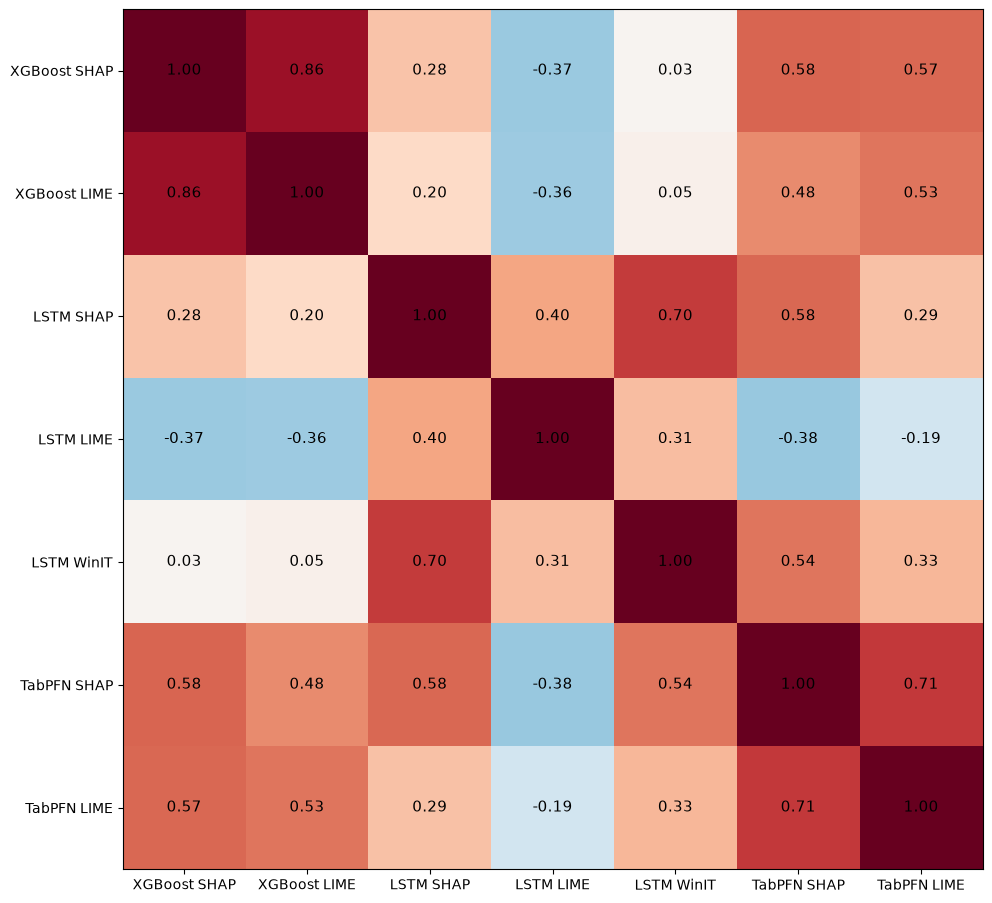

In [115]:
# Overall feature importance rankings

global_importance = pd.DataFrame({
    "XGBoost SHAP": global_shap_xgb,
    "XGBoost LIME": global_lime_xgb,
    "LSTM SHAP": global_shap_lstm_by_feature,
    "LSTM LIME": global_lime_lstm_by_feature,
    "LSTM WinIT": global_winit_lstm_by_feature,
    "TabPFN SHAP": global_shap_tabpfn,
    "TabPFN LIME": global_lime_tabpfn
})

global_importance_rankings = pd.DataFrame({
    "XGBoost SHAP": global_shap_xgb.index,
    "XGBoost LIME": global_lime_xgb.index,
    "LSTM SHAP": global_shap_lstm_by_feature.index,
    "LSTM LIME": global_lime_lstm_by_feature.index,
    "LSTM WinIT": global_winit_lstm_by_feature.index,
    "TabPFN SHAP": global_shap_tabpfn.index,
    "TabPFN LIME": global_lime_tabpfn.index
})
global_importance_rankings = global_importance_rankings.apply(lambda x: x[::-1])
global_importance_rankings.index = range(1, len(global_importance_rankings) + 1)
display(global_importance_rankings)

# Rename features for clarity, use Feature Details Bloomberg ID to Common Name mapping
display(global_importance_rankings.replace(Feature_Name_Map))

# Cross-method-model agreement in feature importance rankings
corr_matrix = global_importance.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=11)
plt.tight_layout()
plt.savefig("Images/Global Feature Importance Correlation Matrix.png", dpi=300)
plt.show()

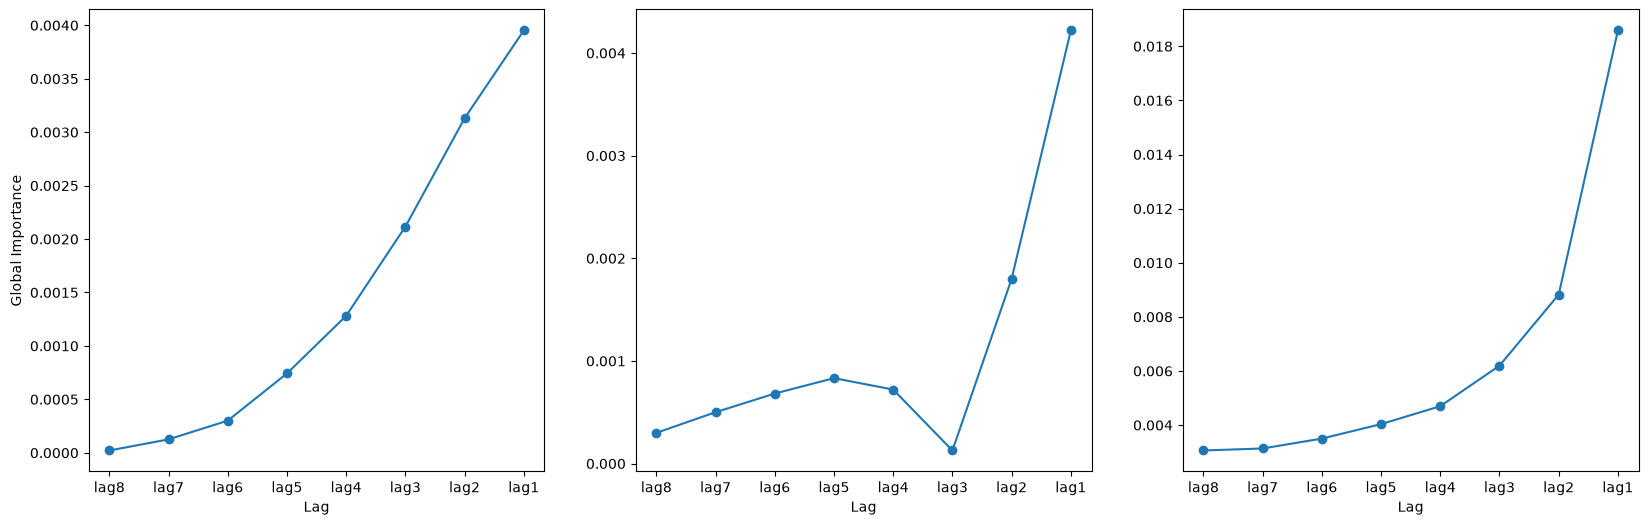

In [116]:
# Plot all 3 lag profiles side by side in one figure

plt.subplots(1, 3, figsize=(20, 6), sharex=True)
ax = plt.subplot(1, 3, 1)
ax.plot(global_shap_lstm_by_lag.index, global_shap_lstm_by_lag.values, marker='o', label='SHAP')
ax.set_xlabel('Lag')
ax.set_ylabel('Global Importance')

ax = plt.subplot(1, 3, 2)
ax.plot(global_lime_lstm_by_lag.index, global_lime_lstm_by_lag.values, marker='o', label='LIME')
ax.set_xlabel('Lag')
#ax.set_ylabel('Global Importance')

ax = plt.subplot(1, 3, 3)
ax.plot(global_winit_lstm_by_lag.index, global_winit_lstm_by_lag.values, marker='o', label='WinIT')
ax.set_xlabel('Lag')
#ax.set_ylabel('Global Importance')

plt.savefig("Images/LSTM Global Lag Importance Profiles.png", dpi=300, bbox_inches='tight')
plt.show()

# Local Analysis

In [267]:
# Function to compute Jensen-Shannon Divergence between two distributions of attributions (e.g. correct vs incorrect predictions)
def Attributions_JSD(results_df, features):
    shap_correct = results_df.loc[results_df["Correct"] == True][features].abs().mean(axis=0)
    shap_incorrect = results_df.loc[results_df["Correct"] == False][features].abs().mean(axis=0)
    # Normalize to probability distributions
    p = shap_correct / shap_correct.sum()
    q = shap_incorrect / shap_incorrect.sum()
    # Compute Jensen-Shannon Divergence
    jsd = jensenshannon(p, q, base=2)  # base=2 for bits
    return jsd

# Function to perform permutation test for JSD significance
def jsd_permutation_test(results_df, features, n_permutations=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    # Observed JSD
    observed_jsd = Attributions_JSD(results_df, features)

    n_correct = (results_df["Correct"] == True).sum()
    n_total = len(results_df)

    null_jsds = np.zeros(n_permutations)
    attributions = results_df[features].abs()

    for i in range(n_permutations):
        # Random split of same group sizes, ignoring actual correctness label
        shuffled_idx = rng.permutation(n_total)
        group_a_idx = shuffled_idx[:n_correct]
        group_b_idx = shuffled_idx[n_correct:]

        p = attributions.iloc[group_a_idx].mean(axis=0)
        q = attributions.iloc[group_b_idx].mean(axis=0)
        p = p / p.sum()
        q = q / q.sum()

        null_jsds[i] = jensenshannon(p, q, base=2)

    # p-value: proportion of null JSDs >= observed
    p_value = (null_jsds >= observed_jsd).mean()
    percentile = (null_jsds < observed_jsd).mean() * 100

    return {
        "observed_jsd": observed_jsd,
        "null_mean": null_jsds.mean(),
        "null_std": null_jsds.std(),
        "p_value": p_value,
        "percentile": percentile,
        "null_distribution": null_jsds
    }

# Function to compute per-prediction Shannon entropy of attributions
def compute_entropy(results_df, features):
    attributions = results_df[features].abs()
    
    entropies = []
    for idx, row in attributions.iterrows():
        vals = row.values.astype(float)
        total = vals.sum()
        if total == 0 or np.isnan(total):
            entropies.append(np.nan)
            continue
        p = vals / total
        h = entropy(p, base=2)
        entropies.append(h)
    
    return pd.Series(entropies, index=results_df.index, name="feature_entropy")

# Function to compute correlation between a per-prediction attribution metric and absolute prediction error
def metric_error_corr(results_df, metric_series, alternative='two-sided', error_col='Abs Error'):
    if error_col == "Signed PnL":
        results_df["Signed PnL"] = np.sign(results_df["Pred"]) * results_df["Actual"]
    elif error_col == "Error":
        results_df["Error"] = results_df["Pred"] - results_df["Actual"]
        
    df = pd.DataFrame({
        'metric': metric_series,
        'error': results_df[error_col]
    }).dropna()

    rho, p_spear = spearmanr(df['metric'], df['error'], alternative=alternative)

    return {'n': len(df), 'correlation': rho, 'p_value': p_spear}

# Function to perform Mann-Whitney U test and compute Cliff's delta
def mw_cliffs_test(group_a, group_b):
    u_stat, p_value = mannwhitneyu(group_a, group_b, alternative="two-sided")
    delta, size = cliffs_delta(group_a, group_b)
    return {"MW stat": u_stat, "p_value": p_value, "cliffs_delta": delta, "effect_size": size}

## Importance over time

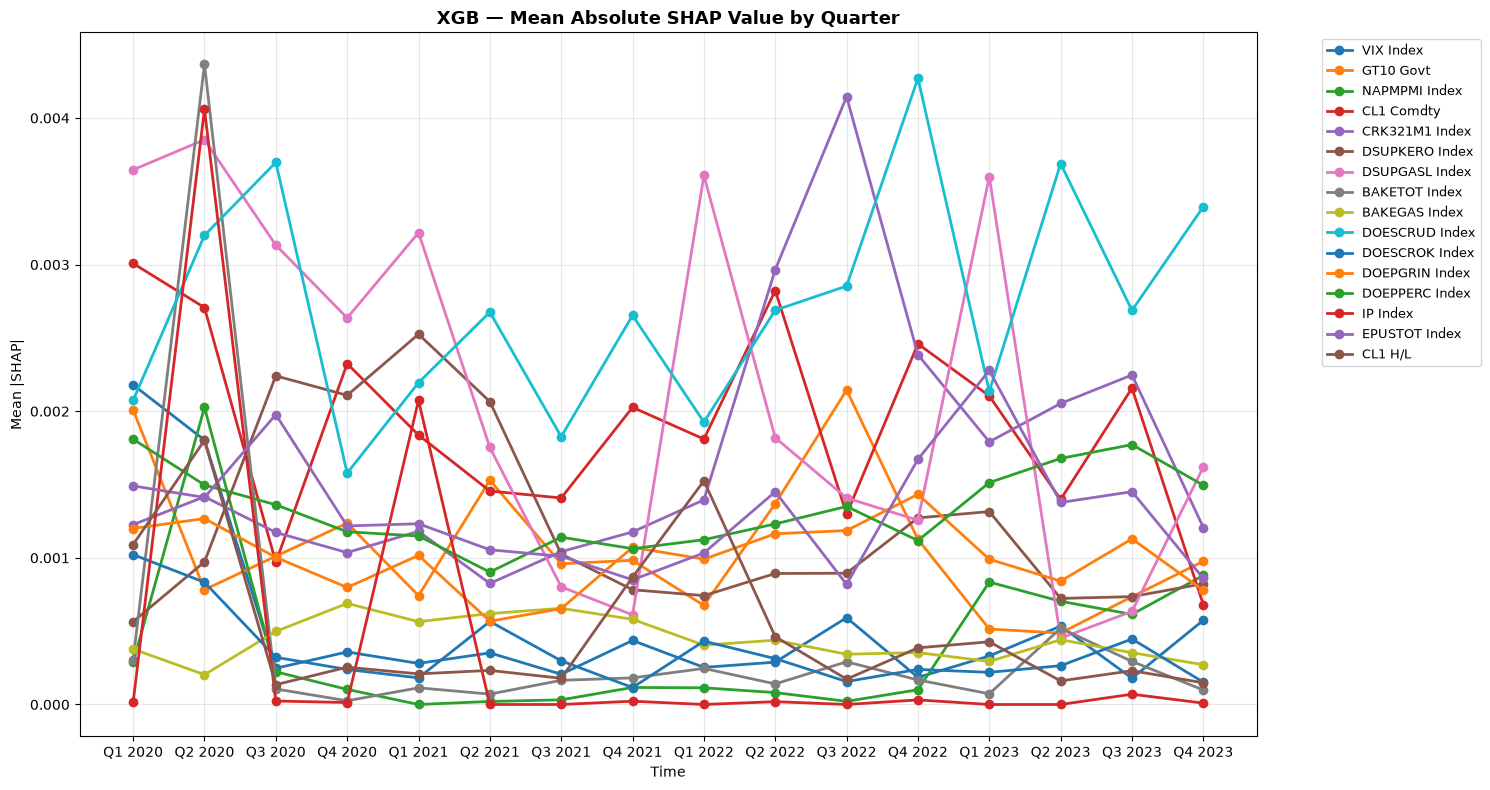

In [268]:
# SHAP importance by quarter for XGBoost
shap_quarterly_xgb = (XGB_RESULTS_TEST1[shap_features].abs().resample('QE').mean().T)

x = range(len(shap_quarterly_xgb.columns))
year_labels = [f"Q{((c.month - 1) // 3) + 1} {c.year}" for c in shap_quarterly_xgb.columns]

fig, ax = plt.subplots(figsize=(15, 8))
for feature in features:
    ax.plot(x, shap_quarterly_xgb.loc[f"shap__{feature}"], marker='o', linewidth=2, label=feature)
ax.set_title('XGB — Mean Absolute SHAP Value by Quarter', fontsize=13, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Mean |SHAP|')
ax.set_xticks(x)
ax.set_xticklabels(year_labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

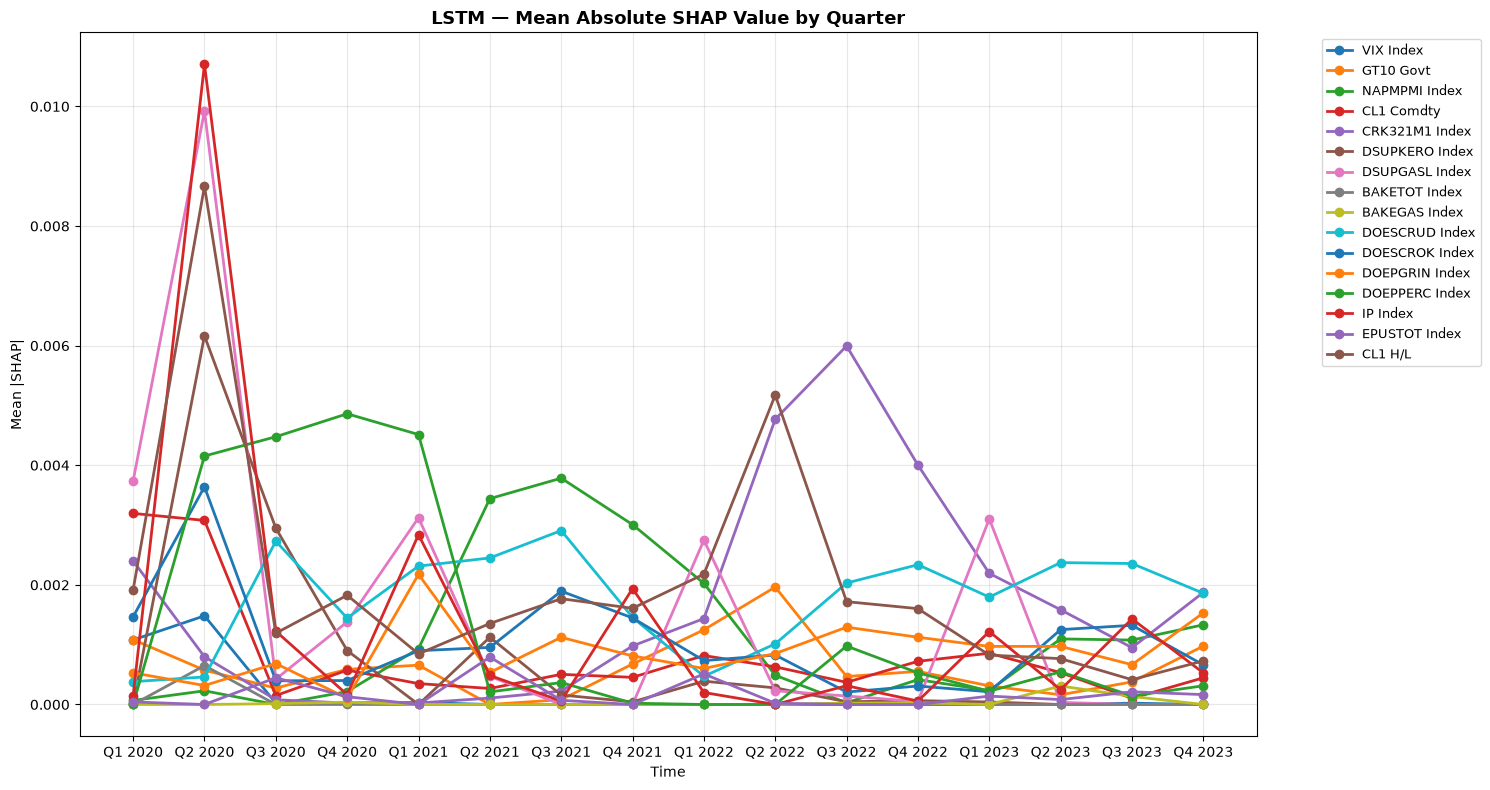

In [269]:
# SHAP importance by quarter for LSTM
shap_quarterly_lstm = (LSTM_RESULTS_TEST1[shap_features]
                    .abs()
                    .resample('QE')
                    .mean()
                    .T)

x = range(len(shap_quarterly_lstm.columns))
year_labels = [f"Q{((c.month - 1) // 3) + 1} {c.year}" for c in shap_quarterly_lstm.columns]

fig, ax = plt.subplots(figsize=(15, 8))
for feature in features:
    ax.plot(x, shap_quarterly_lstm.loc[f"shap__{feature}"], marker='o', linewidth=2, label=feature)
ax.set_title('LSTM — Mean Absolute SHAP Value by Quarter', fontsize=13, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Mean |SHAP|')
ax.set_xticks(x)
ax.set_xticklabels(year_labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

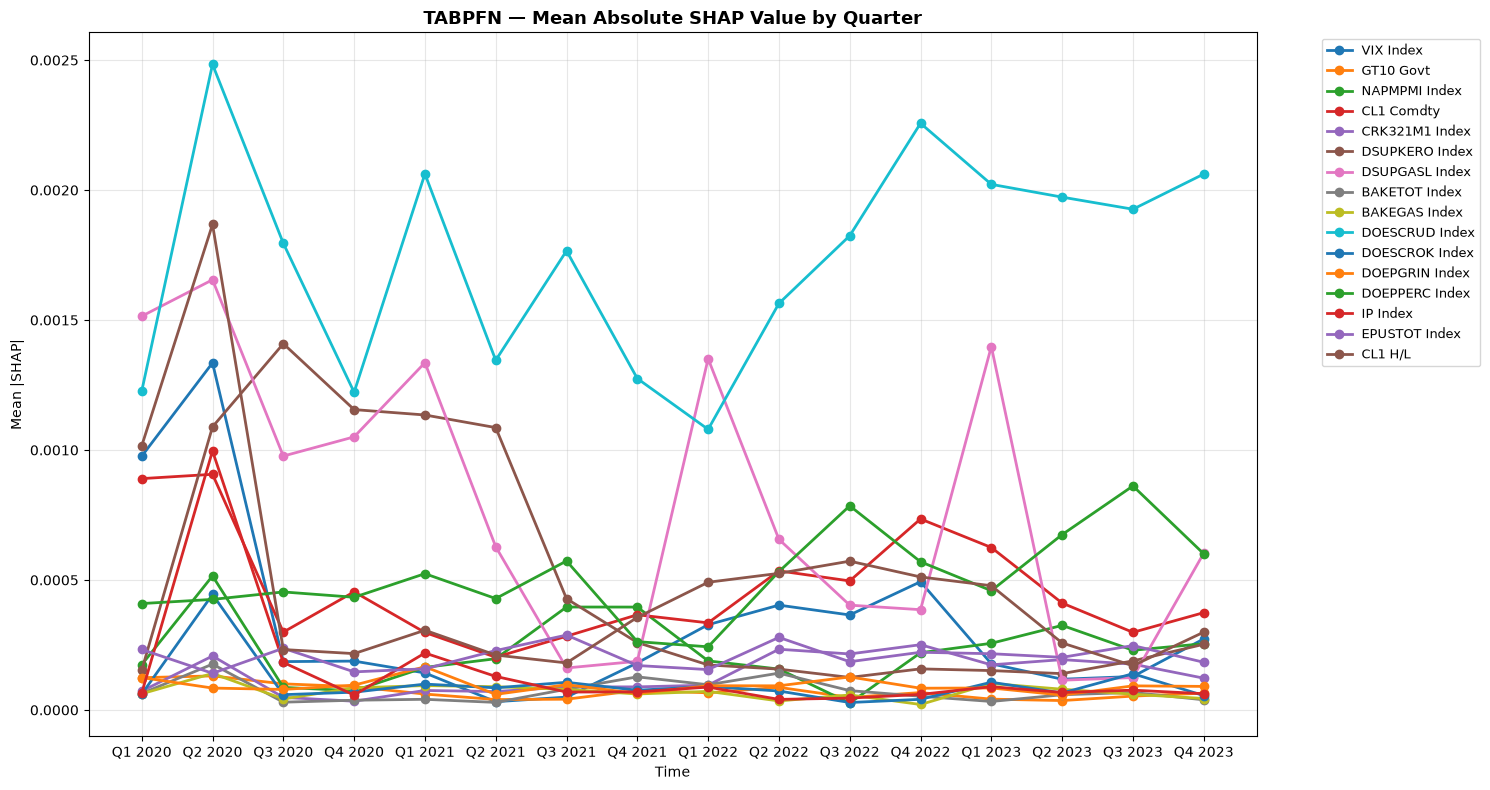

In [270]:
# SHAP importance by quarter for TabPFN
shap_features = [f'shap__{f}' for f in features]
shap_quarterly_tabpfn = (TABPFN_RESULTS_TEST1[shap_features]
                   .abs()
                   .resample('QE')
                   .mean()
                   .T)

x = range(len(shap_quarterly_tabpfn.columns))
year_labels = [f"Q{((c.month - 1) // 3) + 1} {c.year}" for c in shap_quarterly_tabpfn.columns]

fig, ax = plt.subplots(figsize=(15, 8))
for feature in features:
    ax.plot(x, shap_quarterly_tabpfn.loc[f"shap__{feature}"], marker='o', linewidth=2, label=feature)
ax.set_title('TABPFN — Mean Absolute SHAP Value by Quarter', fontsize=13, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Mean |SHAP|')
ax.set_xticks(x)
ax.set_xticklabels(year_labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature attributions

### XGBoost


=== XGB SHAP: Profitable vs Loss-Making ===
                      profitable  loss_making  difference  percent_difference
shap__GT10 Govt         0.001242     0.000870    0.000372            0.427675
shap__CRK321M1 Index    0.001806     0.001587    0.000219            0.138222
shap__EPUSTOT Index     0.001374     0.001247    0.000127            0.101779
shap__DSUPKERO Index    0.001260     0.001185    0.000075            0.063220
shap__BAKEGAS Index     0.000466     0.000412    0.000055            0.132911
shap__DOEPPERC Index    0.001355     0.001311    0.000044            0.033783
shap__VIX Index         0.000548     0.000556   -0.000009           -0.015350
shap__DOESCROK Index    0.000324     0.000411   -0.000087           -0.212596
shap__NAPMPMI Index     0.000345     0.000437   -0.000093           -0.211729
shap__DOEPGRIN Index    0.000942     0.001099   -0.000157           -0.142843
shap__CL1 Comdty        0.001815     0.002025   -0.000210           -0.103926
shap__DOESCRUD Inde

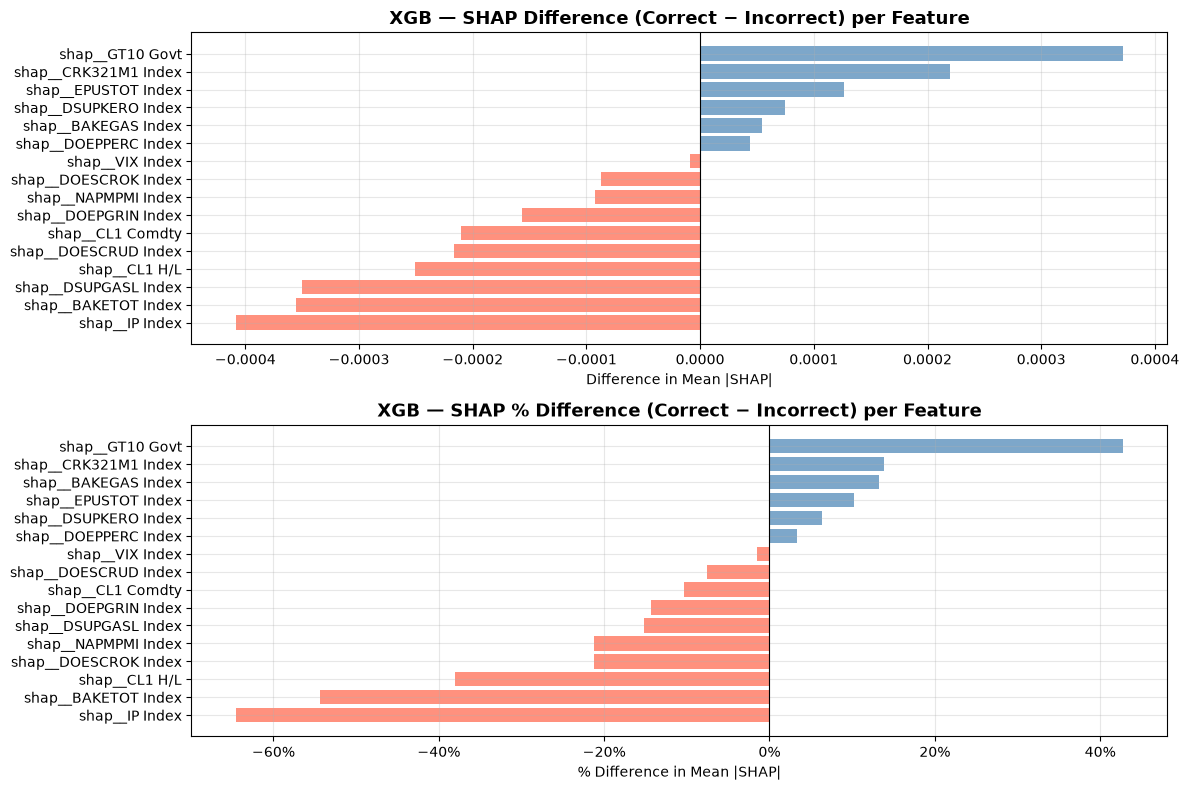

In [271]:
# Comparison of SHAP attributions for profitable vs loss-making predictions - XGBoost

correct_preds_xgb = XGB_RESULTS_TEST1["Correct"].values
profitable_xgb  = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == True][shap_features].abs().mean()
loss_making_xgb = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == False][shap_features].abs().mean()

shap_comparison_xgb = pd.DataFrame({
    'profitable':  profitable_xgb,
    'loss_making': loss_making_xgb,
}).assign(
    difference=lambda x: x['profitable'] - x['loss_making'],
    percent_difference=lambda x: (x['profitable'] - x['loss_making']) / x['loss_making']
)
print("\n=== XGB SHAP: Profitable vs Loss-Making ===")
print(shap_comparison_xgb.sort_values('difference', ascending=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.barh(shap_comparison_xgb.sort_values('difference').index,
         shap_comparison_xgb.sort_values('difference')['difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_xgb.sort_values('difference')['difference']],
         alpha=0.7)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('XGB — SHAP Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax1.set_xlabel('Difference in Mean |SHAP|')
ax1.grid(True, alpha=0.3)

ax2.barh(shap_comparison_xgb.sort_values('percent_difference').index,
         shap_comparison_xgb.sort_values('percent_difference')['percent_difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_xgb.sort_values('percent_difference')['percent_difference']],
         alpha=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('XGB — SHAP % Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax2.set_xlabel('% Difference in Mean |SHAP|')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== XGB LIME: Profitable vs Loss-Making ===
                profitable  loss_making  difference  percent_difference
DOESCRUD Index    0.002880     0.002738    0.000142            0.051849
CL1 Comdty        0.001779     0.001668    0.000111            0.066855
DSUPKERO Index    0.000604     0.000524    0.000080            0.152966
GT10 Govt         0.000756     0.000697    0.000059            0.084324
DOEPGRIN Index    0.000765     0.000716    0.000049            0.068291
CRK321M1 Index    0.000579     0.000531    0.000049            0.091408
DSUPGASL Index    0.001667     0.001625    0.000042            0.026005
VIX Index         0.000535     0.000496    0.000038            0.077316
DOEPPERC Index    0.000560     0.000554    0.000006            0.011343
EPUSTOT Index     0.000433     0.000427    0.000006            0.014494
BAKETOT Index     0.000224     0.000220    0.000004            0.018681
BAKEGAS Index     0.000212     0.000214   -0.000002           -0.007993
DOESCROK Index    0

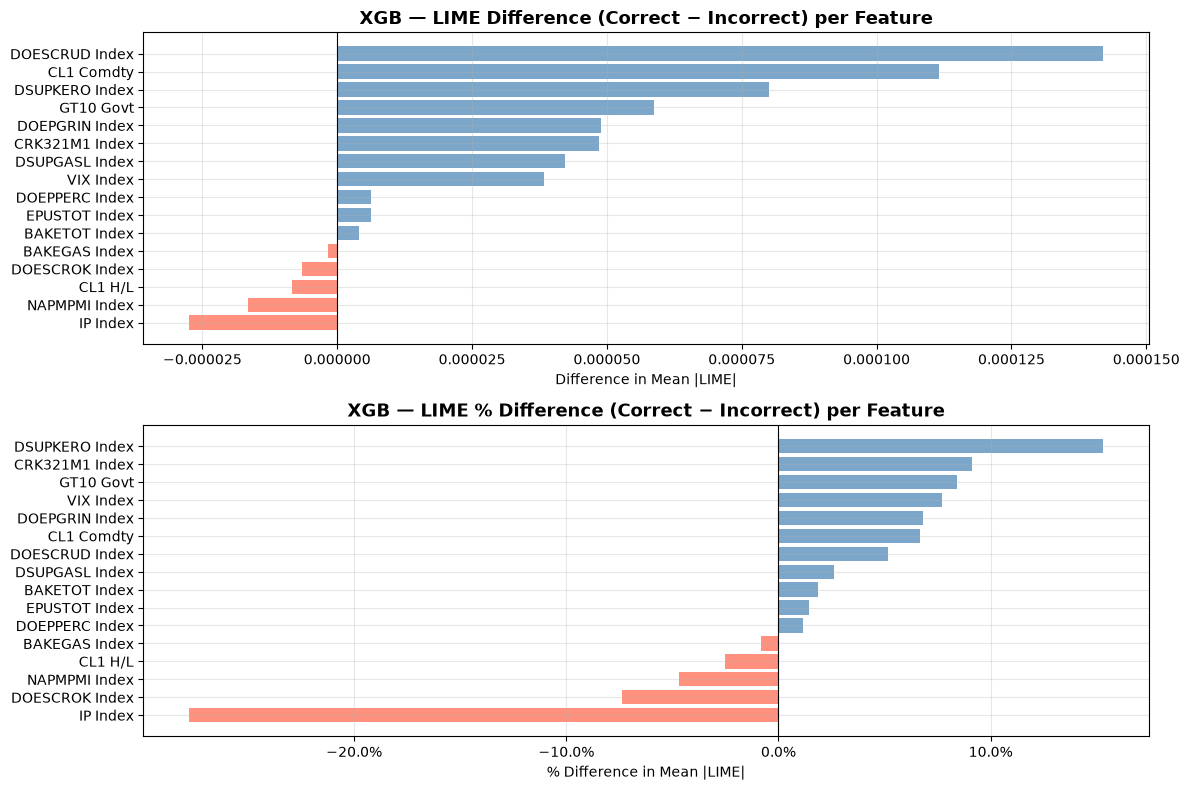

In [272]:
# Comparison of LIME attributions for profitable vs loss-making predictions - XGBoost

correct_preds_xgb = XGB_RESULTS_TEST1["Correct"].values
profitable_xgb  = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == True][lime_features].abs().mean()
loss_making_xgb = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == False][lime_features].abs().mean()

lime_comparison_xgb = pd.DataFrame({
    'profitable':  profitable_xgb,
    'loss_making': loss_making_xgb,
}).assign(
    difference=lambda x: x['profitable'] - x['loss_making'],
    percent_difference=lambda x: (x['profitable'] - x['loss_making']) / x['loss_making']
)
lime_comparison_xgb.index = features
print("\n=== XGB LIME: Profitable vs Loss-Making ===")
print(lime_comparison_xgb.sort_values('difference', ascending=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.barh(lime_comparison_xgb.sort_values('difference').index,
         lime_comparison_xgb.sort_values('difference')['difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in lime_comparison_xgb.sort_values('difference')['difference']],
         alpha=0.7)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('XGB — LIME Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax1.set_xlabel('Difference in Mean |LIME|')
ax1.grid(True, alpha=0.3)

ax2.barh(lime_comparison_xgb.sort_values('percent_difference').index,
         lime_comparison_xgb.sort_values('percent_difference')['percent_difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in lime_comparison_xgb.sort_values('percent_difference')['percent_difference']],
         alpha=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('XGB — LIME % Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax2.set_xlabel('% Difference in Mean |LIME|')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

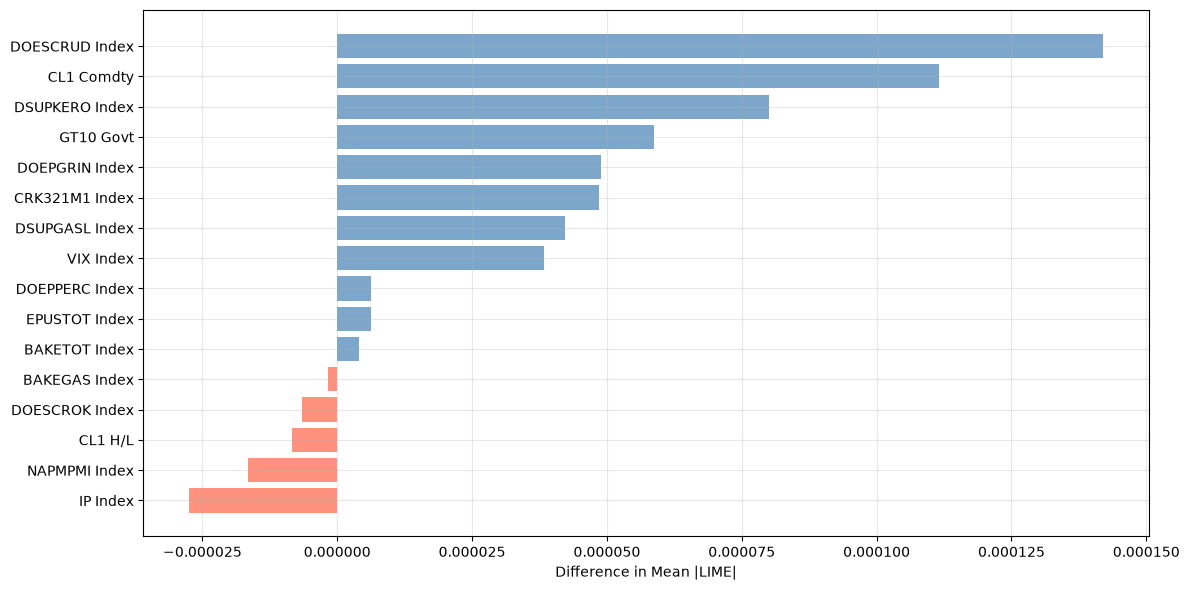

In [ ]:
plt.figure(figsize=(12, 6))
plt.barh(lime_comparison_xgb.sort_values('difference').index,
         lime_comparison_xgb.sort_values('difference')['difference'],
         color=['#2E8B57' if d >= 0 else 'tomato' for d in lime_comparison_xgb.sort_values('difference')['difference']],
         alpha=0.7)
plt.xlabel('Difference in Mean |LIME|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Images/XGB LIME Difference Correct vs Incorrect.png", dpi=300)
plt.show()

### LSTM


=== LSTM SHAP: Profitable vs Loss-Making ===
                      profitable  loss_making  difference  percent_difference
shap__DSUPKERO Index    0.000905     0.000617    0.000288            0.466932
shap__DOESCRUD Index    0.001932     0.001691    0.000241            0.142471
shap__IP Index          0.001459     0.001305    0.000154            0.118298
shap__DSUPGASL Index    0.001542     0.001421    0.000122            0.085746
shap__EPUSTOT Index     0.000211     0.000103    0.000108            1.049803
shap__VIX Index         0.000175     0.000080    0.000094            1.176366
shap__DOESCROK Index    0.001063     0.000972    0.000091            0.093199
shap__BAKETOT Index     0.000062     0.000018    0.000044            2.455052
shap__NAPMPMI Index     0.001199     0.001168    0.000031            0.026409
shap__CL1 Comdty        0.000727     0.000732   -0.000005           -0.006860
shap__BAKEGAS Index     0.000032     0.000040   -0.000008           -0.199924
shap__CRK321M1 Ind

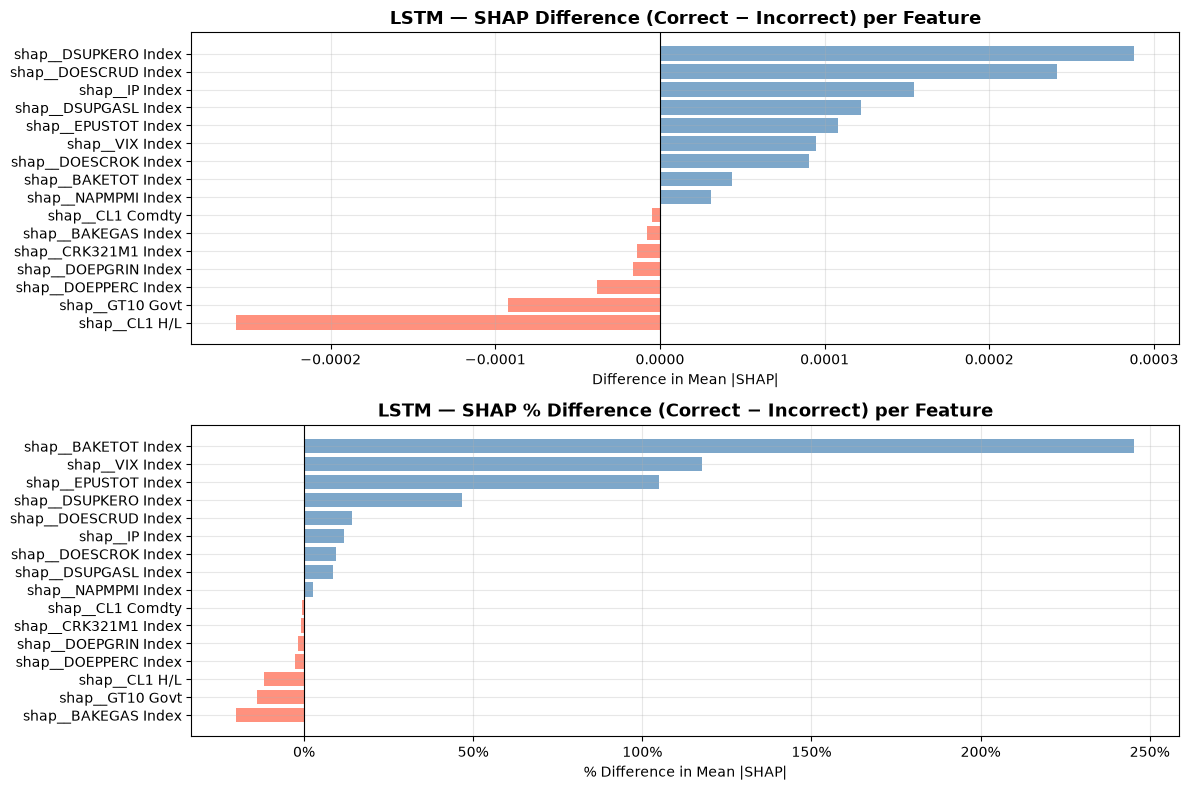

In [274]:
# Comparison of SHAP feature attributions for profitable vs loss-making predictions - LSTM

correct_preds_lstm = LSTM_RESULTS_TEST1["Correct"].values
profitable_lstm  = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][shap_features].abs().mean()
loss_making_lstm = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][shap_features].abs().mean()

shap_comparison_lstm = pd.DataFrame({
    'profitable':  profitable_lstm,
    'loss_making': loss_making_lstm,
}).assign(
    difference=lambda x: x['profitable'] - x['loss_making'],
    percent_difference=lambda x: (x['profitable'] - x['loss_making']) / x['loss_making']
)
print("\n=== LSTM SHAP: Profitable vs Loss-Making ===")
print(shap_comparison_lstm.sort_values('difference', ascending=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.barh(shap_comparison_lstm.sort_values('difference').index,
         shap_comparison_lstm.sort_values('difference')['difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_lstm.sort_values('difference')['difference']],
         alpha=0.7)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('LSTM — SHAP Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax1.set_xlabel('Difference in Mean |SHAP|')
ax1.grid(True, alpha=0.3)

ax2.barh(shap_comparison_lstm.sort_values('percent_difference').index,
         shap_comparison_lstm.sort_values('percent_difference')['percent_difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_lstm.sort_values('percent_difference')['percent_difference']],
         alpha=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('LSTM — SHAP % Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax2.set_xlabel('% Difference in Mean |SHAP|')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

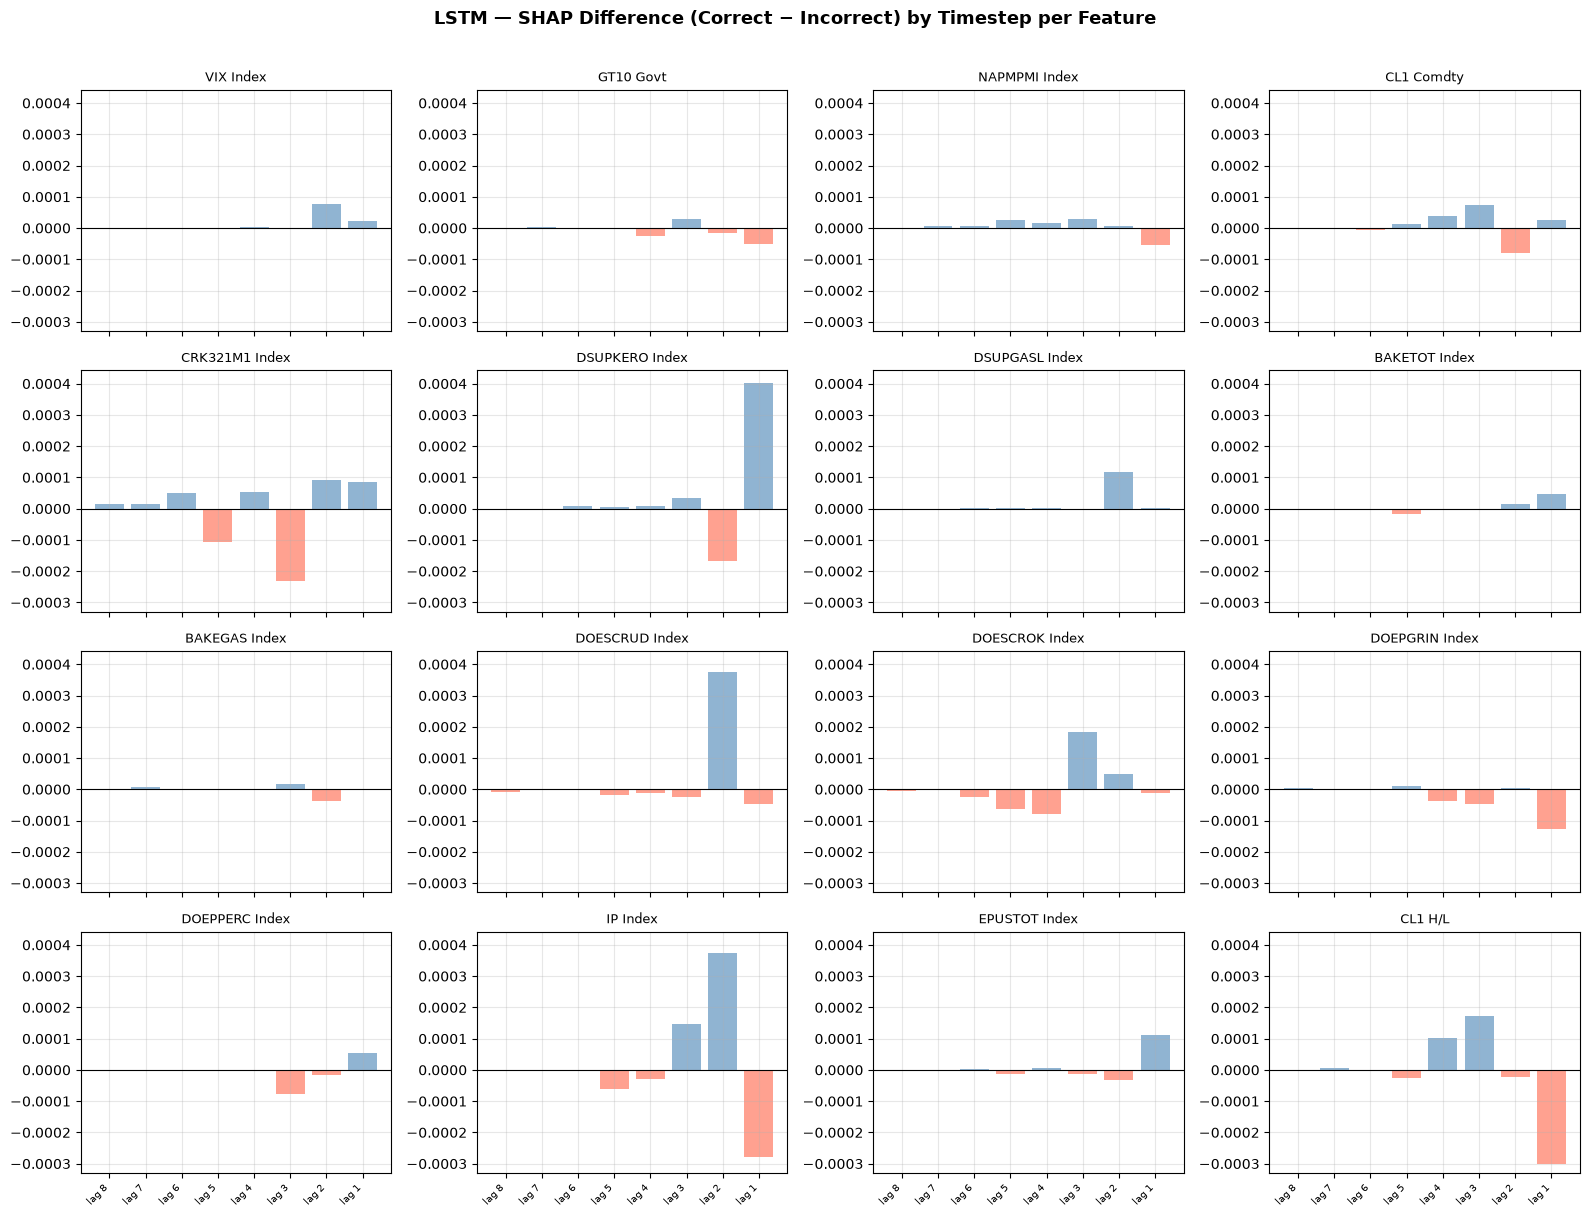

In [275]:
# Comparison of SHAP lag attributions by feature for profitable vs loss-making predictions (LSTM)

n_features = len(features)
correct_preds_lstm = LSTM_RESULTS_TEST1["Correct"].values  # shape: (n_test_samples,)
shap_abs_profitable = np.abs(shap_lstm_3d_test1[correct_preds_lstm]).mean(axis=0)
shap_abs_loss = np.abs(shap_lstm_3d_test1[~correct_preds_lstm]).mean(axis=0)

# Set global y-axis limits across all features
all_diffs = [shap_abs_profitable[:, i] - shap_abs_loss[:, i] for i in range(n_features)]
y_min = min(d.min() for d in all_diffs)
y_max = max(d.max() for d in all_diffs)

ncols = 4
nrows = -(-n_features // ncols)
x = range(len(lags))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharex=True)
axes = axes.flatten()

labels = [f'lag {lag}' for lag in lags]
for i, feature in enumerate(features):
    diff = all_diffs[i]
    ax = axes[i]
    ax.bar(x, diff, color=['steelblue' if d >= 0 else 'tomato' for d in diff], alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylim(y_min * 1.1, y_max * 1.1)
    ax.set_title(feature, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('LSTM — SHAP Difference (Correct − Incorrect) by Timestep per Feature',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### JSD

In [276]:
# Jensen-Shannon Divergence of feature attributions between profitable vs loss-making predictions
jsd_feature_results = {}
for model_name, df in [("XGBoost", XGB_RESULTS_TEST1), ("LSTM", LSTM_RESULTS_TEST1)]:
    for method_name, feats in [("SHAP", shap_features), ("LIME", lime_features)]:
        if model_name == "LSTM" or method_name != "WinIT":  # skip WinIT for non-LSTM
            key = (model_name, method_name)
            jsd_feature_results[key] = jsd_permutation_test(df, feats)

jsd_feature_results = pd.DataFrame({
    k: {"JSD": v["observed_jsd"], "p_value": v["p_value"]}
    for k, v in jsd_feature_results.items()
}).T
display(jsd_feature_results.round(3))

JSD  p_value
XGBoost SHAP  0.104    0.356
        LIME  0.021    0.026
LSTM    SHAP  0.068    0.977
        LIME  0.006    0.397

### Entropy

In [277]:
# Comparison of entropy of feature attributions for correct vs incorrect predictions
entrop_feature_results = []
for model_name, results_df, xai_features_sets in [
    ("XGB", XGB_RESULTS_TEST1, [shap_features, lime_features]),
    ("LSTM", LSTM_RESULTS_TEST1, [shap_features, lime_features]),
]:
    for xai_features in xai_features_sets:
        entropy_series = compute_entropy(results_df, xai_features)
        entropy_correct = entropy_series[results_df["Correct"] == True]
        entropy_incorrect = entropy_series[results_df["Correct"] == False]
        entropy_binary = mw_cliffs_test(entropy_correct, entropy_incorrect)
        entropy_abs_error = metric_error_corr(results_df, entropy_series, error_col='Abs Error')

        entrop_feature_results.append({
            "model": model_name,
            "method": xai_features[0].split('__')[0],
            "entropy_binary_p_value": entropy_binary["p_value"],
            "entropy_abs_error_corr": entropy_abs_error["correlation"],
            "entropy_abs_error_p_value": entropy_abs_error["p_value"],
        })
entrop_feature_results = pd.DataFrame(entrop_feature_results).set_index(["model", "method"])
display(entrop_feature_results.round(3))

entropy_binary_p_value  entropy_abs_error_corr  \
model method                                                   
XGB   shap                     0.500                   0.097   
      lime                     0.117                   0.023   
LSTM  shap                     0.737                  -0.121   
      lime                     0.035                   0.141   

              entropy_abs_error_p_value  
model method                             
XGB   shap                        0.162  
      lime                        0.739  
LSTM  shap                        0.086  
      lime                        0.045

### Feature Analysis Summary

In [278]:
# Summary of p-values for local analysis of feature attributions (JSD, entropy binary test, entropy-abs error correlation)
local_analysis_feature_results = []
for model_name, results_df, xai_features_sets in [
    ("XGB", XGB_RESULTS_TEST1, [shap_features, lime_features]),
    ("LSTM", LSTM_RESULTS_TEST1, [shap_features, lime_features]),
]:
    for xai_features in xai_features_sets:
        jsd = jsd_permutation_test(results_df, xai_features)
        entropy_series = compute_entropy(results_df, xai_features)
        entropy_correct = entropy_series[results_df["Correct"] == True]
        entropy_incorrect = entropy_series[results_df["Correct"] == False]
        entropy_binary = mw_cliffs_test(entropy_correct, entropy_incorrect)
        entropy_abs_error = metric_error_corr(results_df, entropy_series, error_col='Abs Error')

        local_analysis_feature_results.append({
            "model": model_name,
            "method": xai_features[0].split('__')[0],
            "jsd": jsd["p_value"],
            "entropy_binary": entropy_binary["p_value"],
            "entropy_abs_error": entropy_abs_error["p_value"],
        })     
local_analysis_feature_results = pd.DataFrame(local_analysis_feature_results)
display(local_analysis_feature_results.round(3))

,model,method,jsd,entropy_binary,entropy_abs_error
0,XGB,shap,0.356,0.500,0.162
1,XGB,lime,0.026,0.117,0.739
2,LSTM,shap,0.977,0.737,0.086
3,LSTM,lime,0.397,0.035,0.045


## Lag profiles

### SHAP


=== LSTM SHAP: Profitable vs Loss-Making ===
       profitable  loss_making  difference  percent_difference
lag 8    0.000024     0.000018    0.000006            0.320775
lag 7    0.000135     0.000112    0.000023            0.203394
lag 6    0.000323     0.000274    0.000049            0.177714
lag 5    0.000629     0.000916   -0.000287           -0.313278
lag 4    0.001377     0.001150    0.000228            0.197980
lag 3    0.002210     0.001994    0.000217            0.108625
lag 2    0.003353     0.002837    0.000516            0.181877
lag 1    0.003640     0.004368   -0.000728           -0.166650


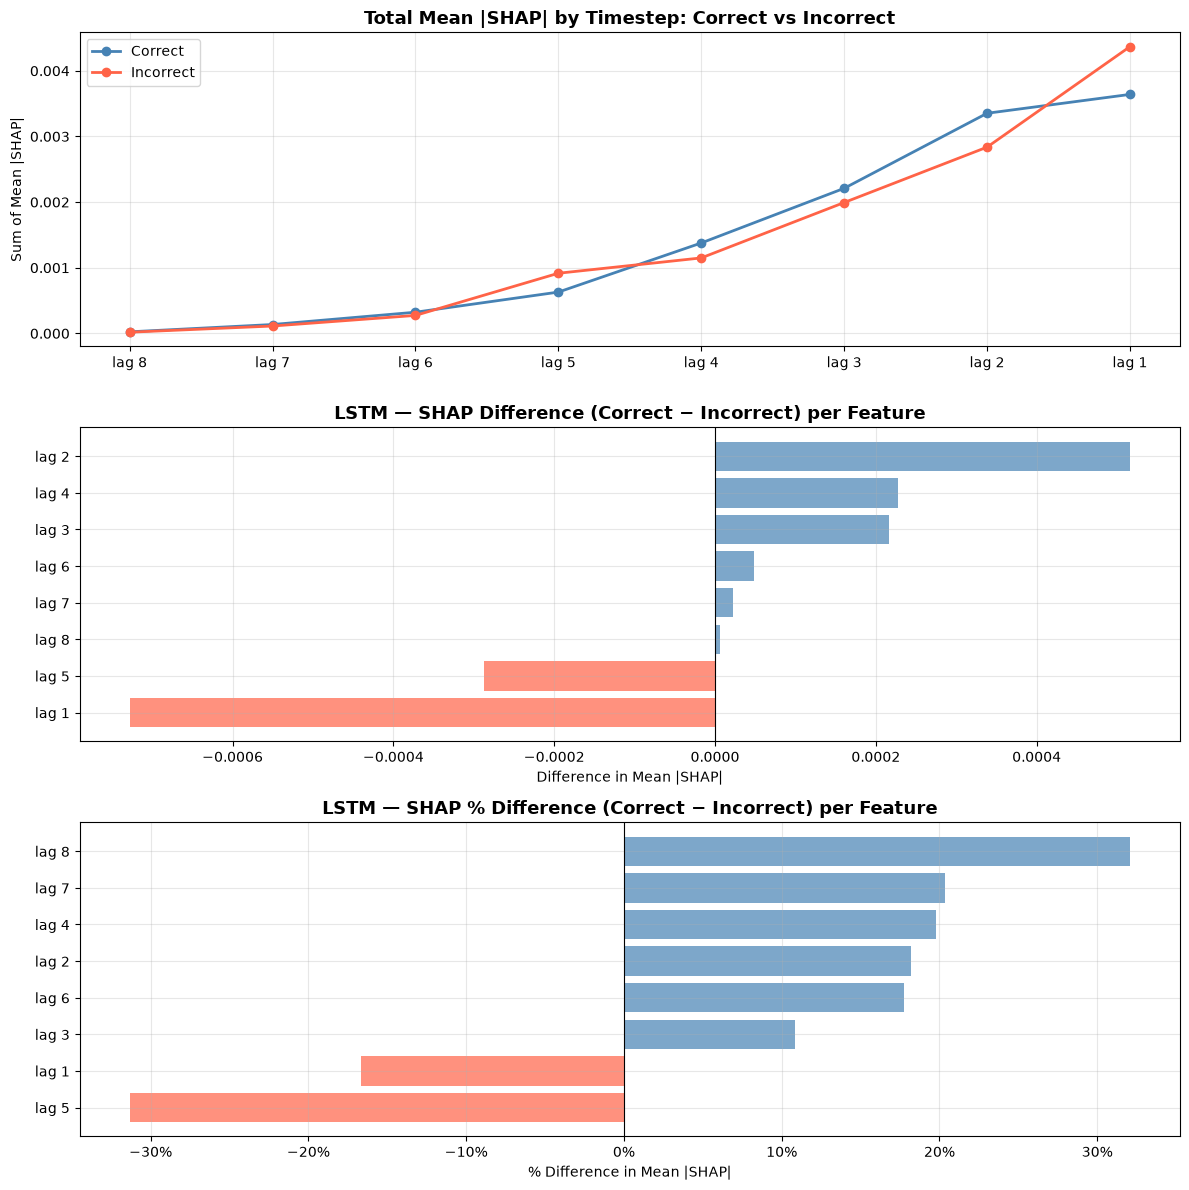

In [279]:
# Comparison of SHAP lag attributions for profitable vs loss-making predictions (LSTM)

profitable_lstm_lags  = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][shap_lags].abs().mean()
loss_making_lstm_lags = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][shap_lags].abs().mean()

shap_comparison_lstm_lags = pd.DataFrame({
    'profitable':  profitable_lstm_lags,
    'loss_making': loss_making_lstm_lags,
}).assign(
    difference=lambda x: x['profitable'] - x['loss_making'],
    percent_difference=lambda x: (x['profitable'] - x['loss_making']) / x['loss_making']
)
shap_comparison_lstm_lags.index = [f'lag {lag}' for lag in lags]
print("\n=== LSTM SHAP: Profitable vs Loss-Making ===")
print(shap_comparison_lstm_lags)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot(shap_comparison_lstm_lags['profitable'], marker='o', linewidth=2, label='Correct', color='steelblue')
ax1.plot(shap_comparison_lstm_lags['loss_making'],marker='o', linewidth=2, label='Incorrect', color='tomato')
ax1.set_ylabel('Sum of Mean |SHAP|')
ax1.set_title('Total Mean |SHAP| by Timestep: Correct vs Incorrect', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.barh(shap_comparison_lstm_lags.sort_values('difference').index,
         shap_comparison_lstm_lags.sort_values('difference')['difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_lstm_lags.sort_values('difference')['difference']],
         alpha=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('LSTM — SHAP Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax2.set_xlabel('Difference in Mean |SHAP|')
ax2.grid(True, alpha=0.3)

ax3.barh(shap_comparison_lstm_lags.sort_values('percent_difference').index,
         shap_comparison_lstm_lags.sort_values('percent_difference')['percent_difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in shap_comparison_lstm_lags.sort_values('percent_difference')['percent_difference']],
         alpha=0.7)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('LSTM — SHAP % Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax3.set_xlabel('% Difference in Mean |SHAP|')
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### LIME


=== LSTM LIME: Profitable vs Loss-Making ===
       profitable  loss_making    difference  percent_difference
lag 8    0.000290     0.000311 -2.138417e-05           -0.068675
lag 7    0.000500     0.000501 -5.972159e-07           -0.001192
lag 6    0.000668     0.000701 -3.303862e-05           -0.047120
lag 5    0.000807     0.000867 -6.012324e-05           -0.069376
lag 4    0.000709     0.000737 -2.868031e-05           -0.038898
lag 3    0.000125     0.000130 -5.364009e-06           -0.041109
lag 2    0.001800     0.001800  5.708721e-07            0.000317
lag 1    0.004179     0.004273 -9.395009e-05           -0.021987


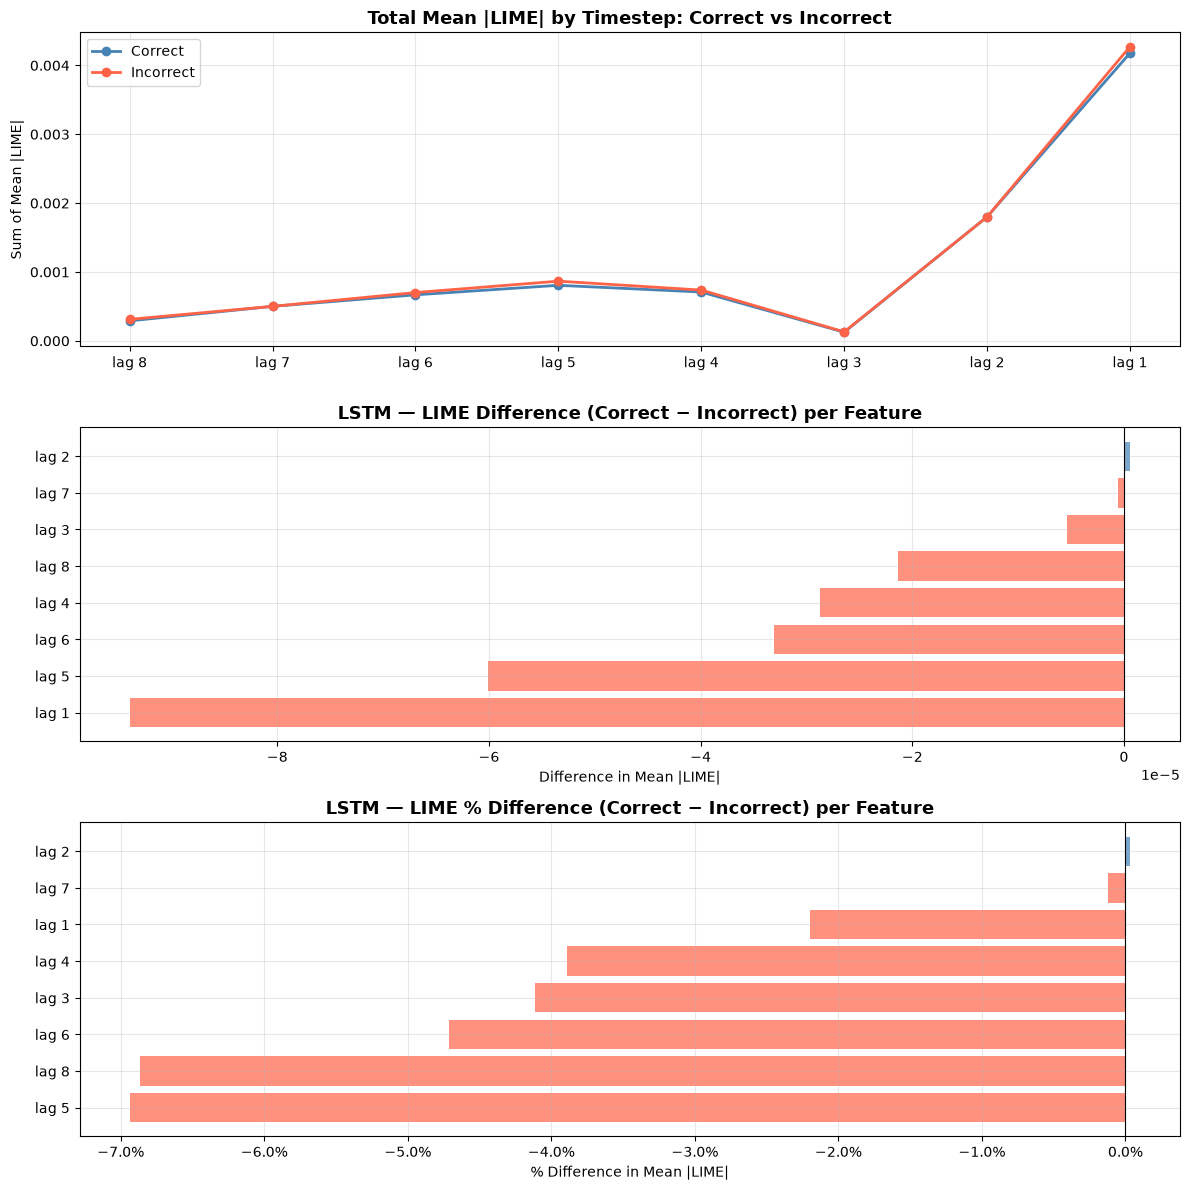

In [280]:
# Comparison of LIME lag attributions for profitable vs loss-making predictions (LSTM)

profitable_lstm  = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][lime_lags].abs().mean()
loss_making_lstm = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][lime_lags].abs().mean()

lime_comparison_lstm = pd.DataFrame({
    'profitable':  profitable_lstm,
    'loss_making': loss_making_lstm,
}).assign(
    difference=lambda x: x['profitable'] - x['loss_making'],
    percent_difference=lambda x: (x['profitable'] - x['loss_making']) / x['loss_making']
)
lime_comparison_lstm.index = [f'lag {lag}' for lag in lags]
print("\n=== LSTM LIME: Profitable vs Loss-Making ===")
print(lime_comparison_lstm)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot(lime_comparison_lstm['profitable'], marker='o', linewidth=2, label='Correct', color='steelblue')
ax1.plot(lime_comparison_lstm['loss_making'],marker='o', linewidth=2, label='Incorrect', color='tomato')
ax1.set_ylabel('Sum of Mean |LIME|')
ax1.set_title('Total Mean |LIME| by Timestep: Correct vs Incorrect', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.barh(lime_comparison_lstm.sort_values('difference').index,
         lime_comparison_lstm.sort_values('difference')['difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in lime_comparison_lstm.sort_values('difference')['difference']],
         alpha=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('LSTM — LIME Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax2.set_xlabel('Difference in Mean |LIME|')
ax2.grid(True, alpha=0.3)

ax3.barh(lime_comparison_lstm.sort_values('percent_difference').index,
         lime_comparison_lstm.sort_values('percent_difference')['percent_difference'],
         color=['steelblue' if d >= 0 else 'tomato' for d in lime_comparison_lstm.sort_values('percent_difference')['percent_difference']],
         alpha=0.7)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('LSTM — LIME % Difference (Correct − Incorrect) per Feature', fontsize=13, fontweight='bold')
ax3.set_xlabel('% Difference in Mean |LIME|')
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

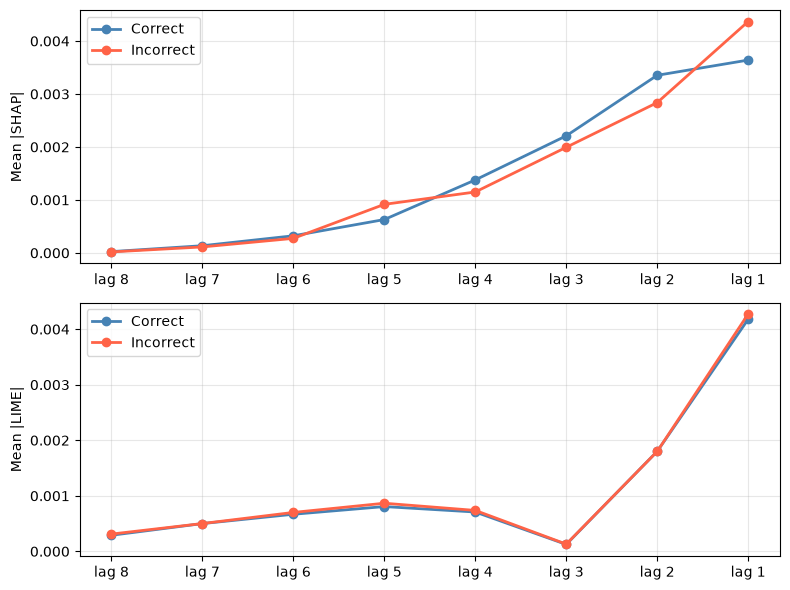

In [ ]:
# Plots of profitable vs loss-making prediction lag attributions for SHAP and LIME (LSTM)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(shap_comparison_lstm_lags['profitable'], marker='o', linewidth=2, label='Correct', color='#2E8B57')
ax1.plot(shap_comparison_lstm_lags['loss_making'],marker='o', linewidth=2, label='Incorrect', color='tomato')
ax1.set_ylabel('Mean |SHAP|')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(lime_comparison_lstm['profitable'], marker='o', linewidth=2, label='Correct', color='#2E8B57')
ax2.plot(lime_comparison_lstm['loss_making'],marker='o', linewidth=2, label='Incorrect', color='tomato')
ax2.set_ylabel('Mean |LIME|')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Images/LSTM Lag Profiles SHAP LIME Correct vs Incorrect.png", dpi=300)
plt.show()

### JSD

In [282]:
# Jensen-Shannon Divergence of lag attributions between profitable vs loss-making predictions (LSTM)
jsd_lag_results = {}
for method_name, xai_lags in [("SHAP", shap_lags), ("LIME", lime_lags)]:
    key = method_name
    jsd_lag_results[key] = jsd_permutation_test(LSTM_RESULTS_TEST1, xai_lags)

# Build summary table
jsd_lag_results = pd.DataFrame({
    k: {"JSD": v["observed_jsd"], "p_value": v["p_value"]}
    for k, v in jsd_lag_results.items()
}).T
display(jsd_lag_results.round(3))

,JSD,p_value
SHAP,0.079,0.072
LIME,0.009,0.626


### Entropy

In [283]:
# Comparison of entropy of lag attributions for correct vs incorrect predictions (LSTM)
entropy_lag_results = []
for xai_lags in [shap_lags, lime_lags]:
    entropy_series = compute_entropy(LSTM_RESULTS_TEST1, xai_lags)
    entropy_correct = entropy_series[LSTM_RESULTS_TEST1["Correct"] == True]
    entropy_incorrect = entropy_series[LSTM_RESULTS_TEST1["Correct"] == False]
    entropy_binary = mw_cliffs_test(entropy_correct, entropy_incorrect)
    entropy_abs_error = metric_error_corr(LSTM_RESULTS_TEST1, entropy_series, error_col='Abs Error')

    entropy_lag_results.append({
        "method": xai_lags[0].split('__')[0],
        "entropy_binary_p_value": entropy_binary["p_value"],
        "entropy_abs_error_corr": entropy_abs_error["correlation"],
        "entropy_abs_error_p_value": entropy_abs_error["p_value"],
    })
entropy_lag_results = pd.DataFrame(entropy_lag_results).set_index("method")
display(entropy_lag_results.round(3))

,entropy_binary_p_value,entropy_abs_error_corr,entropy_abs_error_p_value
method,,,
shap,0.653,0.107,0.128
lime,0.203,0.160,0.023


### Lag Analysis Summary

In [284]:
# Summary of p-values for local analysis of lag attributions (JSD, entropy binary test, entropy-abs error correlation)
local_analysis_lag_results = []
for xai_lags in [shap_lags, lime_lags]:
    jsd = jsd_permutation_test(LSTM_RESULTS_TEST1, xai_lags)

    entropy_series = compute_entropy(LSTM_RESULTS_TEST1, xai_lags)
    entropy_correct = entropy_series[LSTM_RESULTS_TEST1["Correct"] == True]
    entropy_incorrect = entropy_series[LSTM_RESULTS_TEST1["Correct"] == False]
    entropy_binary = mw_cliffs_test(entropy_correct, entropy_incorrect)
    entropy_abs_error = metric_error_corr(LSTM_RESULTS_TEST1, entropy_series, error_col='Abs Error')

    local_analysis_lag_results.append({
        "method": xai_lags[0].split('__')[0],
        "jsd": jsd["p_value"],
        "entropy_binary": entropy_binary["p_value"],
        "entropy_abs_error": entropy_abs_error["p_value"],
    })
local_analysis_lag_results = pd.DataFrame(local_analysis_lag_results)
display(local_analysis_lag_results.round(3))

,method,jsd,entropy_binary,entropy_abs_error
0,shap,0.072,0.653,0.128
1,lime,0.626,0.203,0.023


## Cross method-model agreement

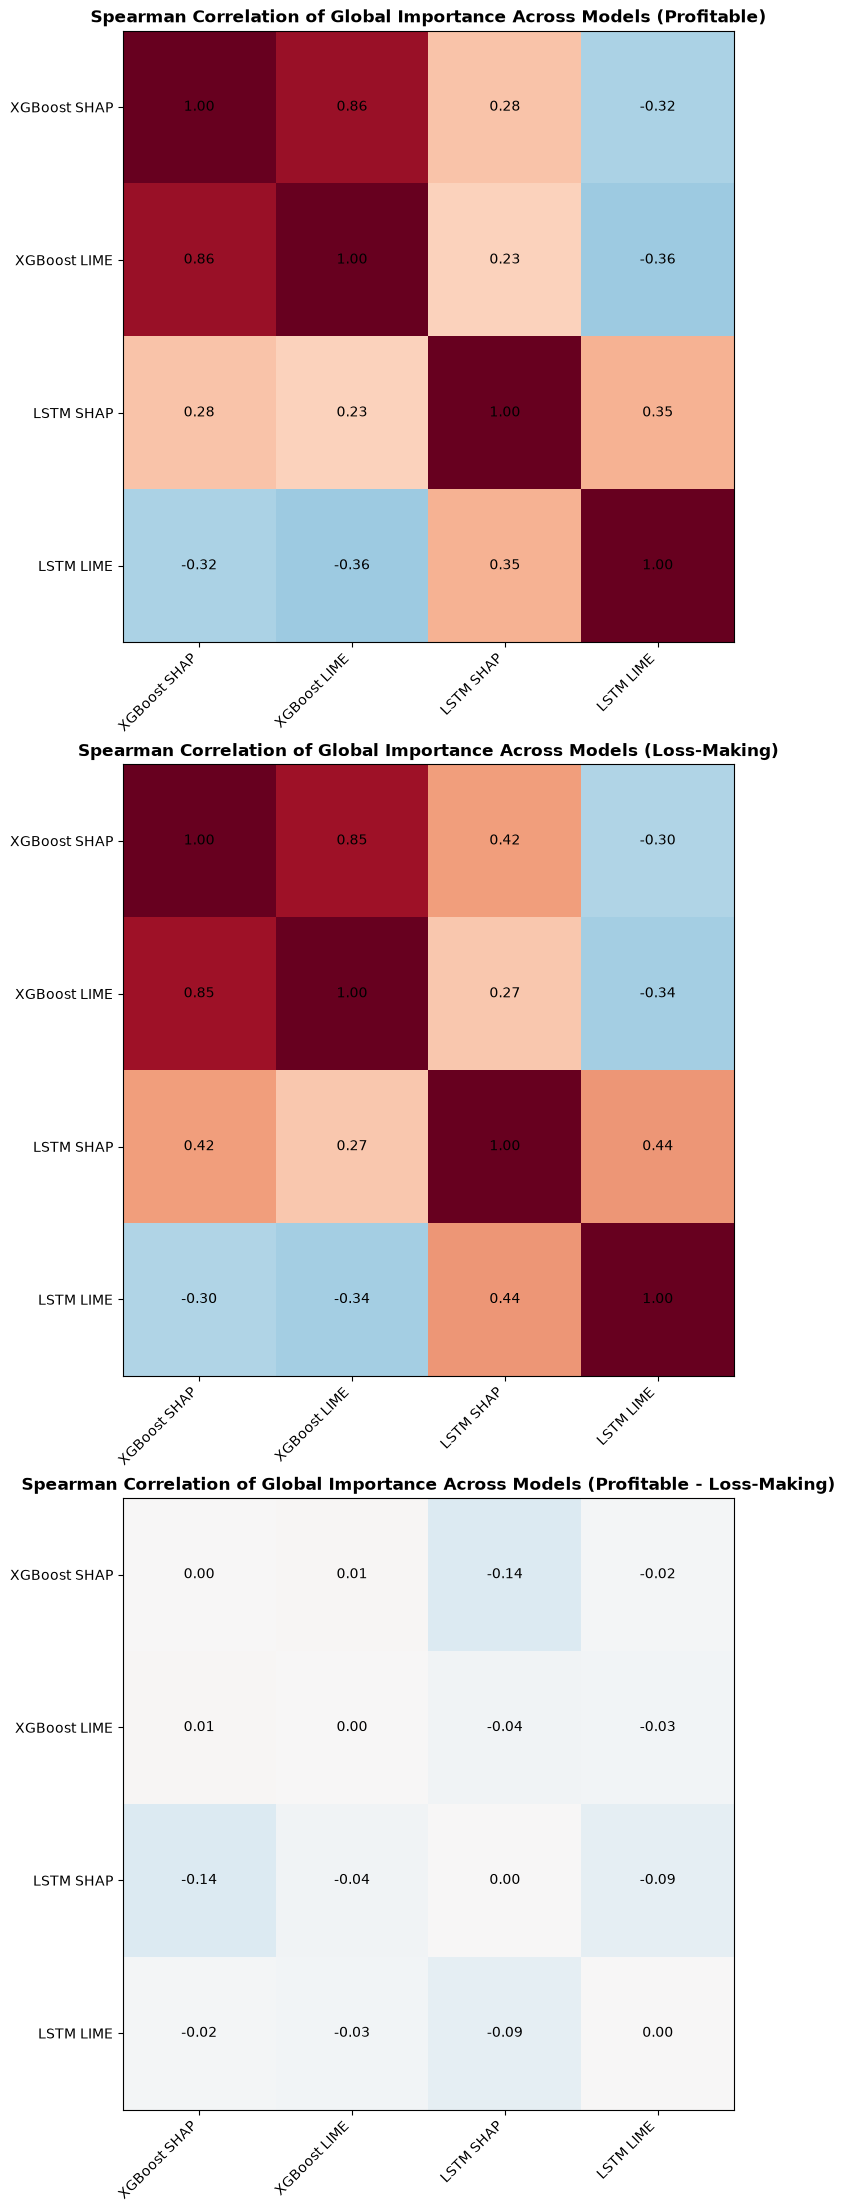

In [285]:
# Compute cross-method-model correlations similarly to for global analysis, but separately for profitable and loss-making subsets.

shap_xgb_profitable = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == True][shap_features].abs().mean()
shap_xgb_profitable.index = features
lime_xgb_profitable = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == True][lime_features].abs().mean()
lime_xgb_profitable.index = features
shap_lstm_profitable = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][shap_features].abs().mean()
shap_lstm_profitable.index = features
lime_lstm_profitable = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][lime_features].abs().mean()
lime_lstm_profitable.index = features
winit_lstm_profitable = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == True][winit_features].abs().mean()
winit_lstm_profitable.index = features
shap_tabpfn_profitable = TABPFN_RESULTS_TEST1.loc[TABPFN_RESULTS_TEST1["Correct"] == True][shap_features].abs().mean()
shap_tabpfn_profitable.index = features
lime_tabpfn_profitable = TABPFN_RESULTS_TEST1.loc[TABPFN_RESULTS_TEST1["Correct"] == True][lime_features].abs().mean()
lime_tabpfn_profitable.index = features

shap_xgb_lossmaking = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == False][shap_features].abs().mean()
shap_xgb_lossmaking.index = features
lime_xgb_lossmaking = XGB_RESULTS_TEST1.loc[XGB_RESULTS_TEST1["Correct"] == False][lime_features].abs().mean()
lime_xgb_lossmaking.index = features
shap_lstm_lossmaking = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][shap_features].abs().mean()
shap_lstm_lossmaking.index = features
lime_lstm_lossmaking = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][lime_features].abs().mean()
lime_lstm_lossmaking.index = features
winit_lstm_lossmaking = LSTM_RESULTS_TEST1.loc[LSTM_RESULTS_TEST1["Correct"] == False][winit_features].abs().mean()
winit_lstm_lossmaking.index = features
shap_tabpfn_lossmaking = TABPFN_RESULTS_TEST1.loc[TABPFN_RESULTS_TEST1["Correct"] == False][shap_features].abs().mean()
shap_tabpfn_lossmaking.index = features
lime_tabpfn_lossmaking = TABPFN_RESULTS_TEST1.loc[TABPFN_RESULTS_TEST1["Correct"] == False][lime_features].abs().mean()
lime_tabpfn_lossmaking.index = features

profitable_importance = pd.DataFrame({
    "XGBoost SHAP": shap_xgb_profitable,
    "XGBoost LIME": lime_xgb_profitable,
    "LSTM SHAP": shap_lstm_profitable,
    "LSTM LIME": lime_lstm_profitable,
})
lossmaking_importance = pd.DataFrame({
    "XGBoost SHAP": shap_xgb_lossmaking,
    "XGBoost LIME": lime_xgb_lossmaking,
    "LSTM SHAP": shap_lstm_lossmaking,
    "LSTM LIME": lime_lstm_lossmaking,
})

profitable_rankings = pd.DataFrame({
    "XGBoost SHAP": shap_xgb_profitable.sort_values(ascending=False).index,
    "XGBoost LIME": lime_xgb_profitable.sort_values(ascending=False).index,
    "LSTM SHAP": shap_lstm_profitable.sort_values(ascending=False).index,
    "LSTM LIME": lime_lstm_profitable.sort_values(ascending=False).index,
})
lossmaking_rankings = pd.DataFrame({
    "XGBoost SHAP": shap_xgb_lossmaking.sort_values(ascending=False).index,
    "XGBoost LIME": lime_xgb_lossmaking.sort_values(ascending=False).index,
    "LSTM SHAP": shap_lstm_lossmaking.sort_values(ascending=False).index,
    "LSTM LIME": lime_lstm_lossmaking.sort_values(ascending=False).index,
})

profitable_corr = profitable_importance.corr(method='spearman')
lossmaking_corr = lossmaking_importance.corr(method="spearman")
profitable_lossmaking_corr_diff = profitable_corr - lossmaking_corr

fig, axs = plt.subplots(3, 1, figsize=(10, 27))
for i, (corr_matrix, title) in enumerate(zip([profitable_corr, lossmaking_corr, profitable_lossmaking_corr_diff], ['Profitable', 'Loss-Making', 'Profitable - Loss-Making'])):
    ax = axs[i]
    im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    for j in range(len(corr_matrix)):
        for k in range(len(corr_matrix)):
            ax.text(k, j, f'{corr_matrix.iloc[j, k]:.2f}', ha='center', va='center')
    ax.set_title(f'Spearman Correlation of Global Importance Across Models ({title})', fontsize=12, fontweight='bold')
plt.show()


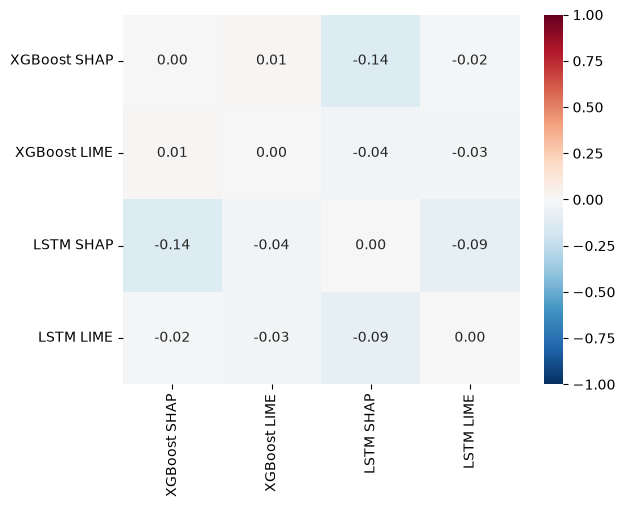

In [286]:
# Heatmap of the difference in global correlation between profitable and loss-making predictions
sns.heatmap(profitable_lossmaking_corr_diff, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1)
plt.savefig("Images/Global Importance Correlation Difference.png", dpi=300, bbox_inches='tight')
plt.show()

In [287]:
# Function to compute per-prediction Spearman correlation
def per_prediction_corr(xai_vals_a, xai_vals_b, correct_preds):
    corrs = []
    for i in range(len(xai_vals_a)):
        rho, _ = spearmanr(xai_vals_a.iloc[i], xai_vals_b.iloc[i])
        corrs.append(rho)
    corrs = pd.Series(corrs, index=xai_vals_a.index)
    return corrs[correct_preds], corrs[~correct_preds]

XGBoost SHAP vs LIME: Mean Spearman ρ (Correct)=0.479, Mean Spearman ρ (Incorrect)=0.436


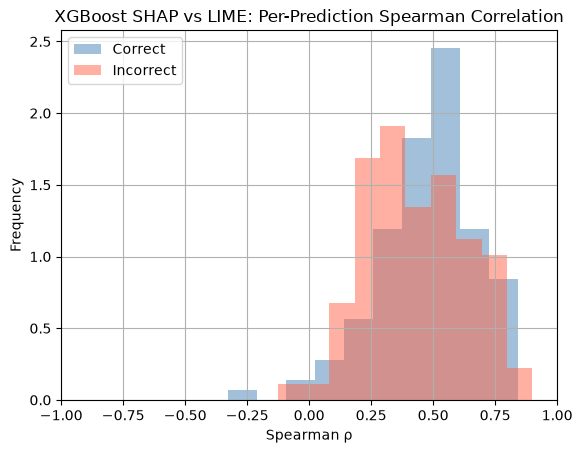

{'MW stat': np.float64(6042.0), 'p_value': np.float64(0.088327643907946), 'cliffs_delta': 0.13849632560768796, 'effect_size': 'negligible'}
LSTM SHAP vs LIME: Mean Spearman ρ (Correct)=0.258, Mean Spearman ρ (Incorrect)=0.256


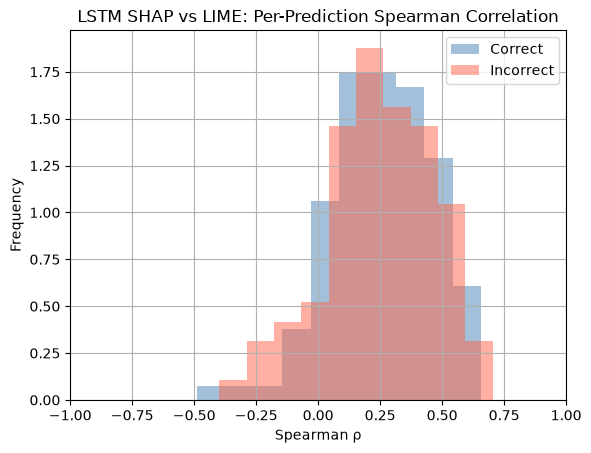

{'MW stat': np.float64(4961.0), 'p_value': np.float64(0.9206143954008871), 'cliffs_delta': -0.008295852073963019, 'effect_size': 'negligible'}
TabPFN SHAP vs LIME: Mean Spearman ρ (Correct)=0.511, Mean Spearman ρ (Incorrect)=0.521


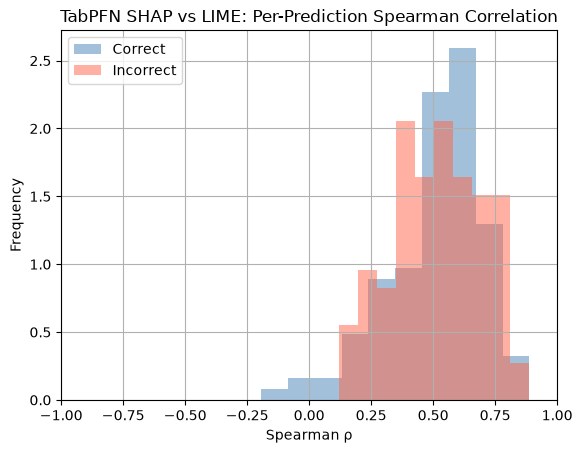

{'MW stat': np.float64(5485.0), 'p_value': np.float64(0.8731561578272937), 'cliffs_delta': 0.012927054478301015, 'effect_size': 'negligible'}


In [288]:
# Plots per-prediction Spearman correlation between SHAP and LIME rankings for each correct and incorrect predictions, for each model
for model_name, df in [("XGBoost", XGB_RESULTS_TEST1), ("LSTM", LSTM_RESULTS_TEST1), ("TabPFN", TABPFN_RESULTS_TEST1)]:
    xai_vals_a = df[shap_features].abs()
    xai_vals_b = df[lime_features].abs()
    correct_preds = df["Correct"].values.astype(bool)

    corrs_correct, corrs_incorrect = per_prediction_corr(xai_vals_a, xai_vals_b, df["Correct"].values.astype(bool))
    rho_correct_mean = corrs_correct.mean()
    rho_incorrect_mean = corrs_incorrect.mean()

    print(f"{model_name} SHAP vs LIME: Mean Spearman ρ (Correct)={rho_correct_mean:.3f}, Mean Spearman ρ (Incorrect)={rho_incorrect_mean:.3f}")

    corrs_correct.hist(bins=10, alpha=0.5, label='Correct', color='steelblue', density=True)
    corrs_incorrect.hist(bins=10, alpha=0.5, label='Incorrect', color='tomato', density=True)
    plt.title(f"{model_name} SHAP vs LIME: Per-Prediction Spearman Correlation")
    plt.xlabel("Spearman ρ")
    plt.ylabel("Frequency")
    plt.legend()
    plt.xlim(-1, 1)
    plt.show()
    print(mw_cliffs_test(corrs_correct, corrs_incorrect))

In [289]:
# Summary of MW test on distributions of per-prediction Spearman correlation between SHAP and LIME rankings
per_prediction_corr_results = []

for model_name, df in [("XGBoost", XGB_RESULTS_TEST1), ("LSTM", LSTM_RESULTS_TEST1), ("TabPFN", TABPFN_RESULTS_TEST1)]:
    xai_vals_a = df[shap_features].abs()
    xai_vals_b = df[lime_features].abs()
    correct_preds = df["Correct"].values.astype(bool)
    corrs_correct, corrs_incorrect = per_prediction_corr(xai_vals_a, xai_vals_b, df["Correct"].values.astype(bool))
    per_prediction_corr_results.append((model_name, mw_cliffs_test(corrs_correct, corrs_incorrect)["p_value"]))

per_prediction_corr_results = pd.DataFrame(per_prediction_corr_results, columns=["Model", "MW"])
display(per_prediction_corr_results.round(3))

,Model,MW
0,XGBoost,0.088
1,LSTM,0.921
2,TabPFN,0.873


## Summary

Feature Attributions


,model,method,jsd,entropy_binary,entropy_abs_error
0,XGB,shap,0.356,0.500,0.162
1,XGB,lime,0.026,0.117,0.739
2,LSTM,shap,0.977,0.737,0.086
3,LSTM,lime,0.397,0.035,0.045


Lag Attributions


,method,jsd,entropy_binary,entropy_abs_error
0,shap,0.072,0.653,0.128
1,lime,0.626,0.203,0.023


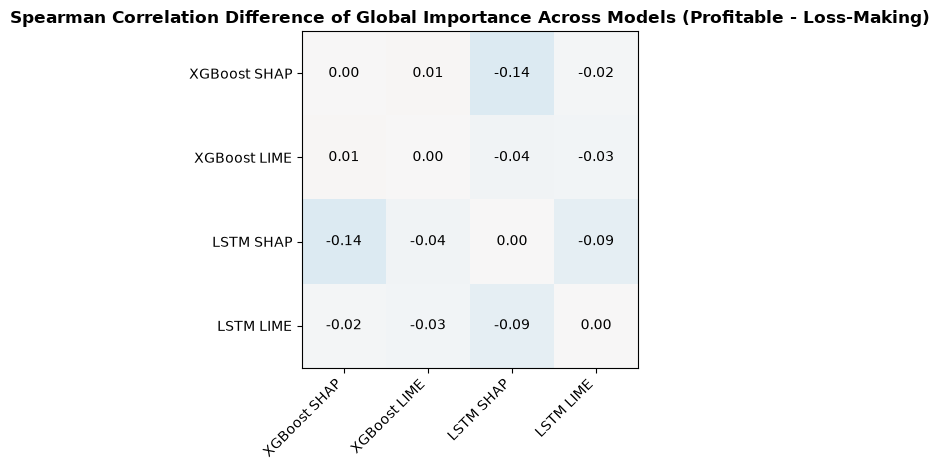

,Model,MW
0,XGBoost,0.088
1,LSTM,0.921
2,TabPFN,0.873


In [290]:
# Summary of p-values for local analysis

def highlight_sig(val):
    if isinstance(val, (int, float)) and val < 0.01:
        return 'background-color: #2ca02c; color: white'
    elif isinstance(val, (int, float)) and val < 0.05:
        return 'background-color: #90EE90; color: black'
    elif isinstance(val, (int, float)) and val < 0.10:
        return 'background-color: #f5a623; color: black'
    return ''

print("Feature Attributions")
display(local_analysis_feature_results.style.map(highlight_sig).format(precision=3))
print("Lag Attributions")
display(local_analysis_lag_results.style.map(highlight_sig).format(precision=3))

plt.imshow(profitable_lossmaking_corr_diff, vmin=-1, vmax=1, cmap='RdBu_r')
plt.xticks(range(len(profitable_lossmaking_corr_diff.columns)), profitable_lossmaking_corr_diff.columns, rotation=45, ha='right')
plt.yticks(range(len(profitable_lossmaking_corr_diff.index)), profitable_lossmaking_corr_diff.index)
plt.title('Spearman Correlation Difference of Global Importance Across Models (Profitable - Loss-Making)', fontsize=12, fontweight='bold')
for j in range(len(profitable_lossmaking_corr_diff)):
    for k in range(len(profitable_lossmaking_corr_diff)):
        plt.text(k, j, f'{profitable_lossmaking_corr_diff.iloc[j, k]:.2f}', ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

display(per_prediction_corr_results.style.map(highlight_sig).format(precision=3))

# XAI-Derived Trading Strategies

## Trading Strategies

### Buy-and-hold

In [306]:
# Generate results for a buy-and-hold benchmark strategy

def build_buy_and_hold_results(actual_log_returns: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=actual_log_returns.index)
    df["position"] = 1.0
    df["actual_log_return"] = actual_log_returns
    df["strategy_log_return"] = df["position"] * df["actual_log_return"]
    df["cum_log_return"] = df["strategy_log_return"].cumsum()
    df["equity_curve"] = np.exp(df["cum_log_return"])
    return df

buy_and_hold_results = build_buy_and_hold_results(Y_Test2[7:])
buy_and_hold_results

,position,actual_log_return,strategy_log_return,cum_log_return,equity_curve
Dates,,,,,
2024-02-23,1.0,-0.015338,-0.015338,-0.015338,0.984779
2024-03-01,1.0,0.026022,0.026022,0.010684,1.010741
2024-03-08,1.0,-0.022012,-0.022012,-0.011328,0.988736
2024-03-15,1.0,0.024323,0.024323,0.012994,1.013079
2024-03-22,1.0,-0.018832,-0.018832,-0.005838,0.994179
...,...,...,...,...,...
2025-11-28,1.0,0.010886,0.010886,-0.165873,0.847154
2025-12-05,1.0,0.033614,0.033614,-0.132259,0.876114
2025-12-12,1.0,-0.071953,-0.071953,-0.204212,0.815289


### LSTM All Predictions

In [307]:
# Generate LSTM predictions for test set 2
X_Test2_lstm, Y_Test2_lstm, test2_dates_lstm = make_sequences(X_Test2_scaled, Y_Test2, lstm_params['SEQ_LEN'])
test2_preds_lstm, test2_preds_dir_lstm, lstm_test2_performance = evaluate_lstm(
    LSTM_MODEL,
    X_Test2_lstm, Y_Test2_lstm
)
LSTM_RESULTS_TEST2 = build_results_df(test2_dates_lstm, Y_Test2_lstm, test2_preds_lstm, features)
display(lstm_test2_performance)

{'MSE': 0.0008607626084716015,
 'MAE': 0.022949622638448637,
 'Directional Accuracy': 0.5360824742268041,
 'ROC-AUC': 0.541025641025641,
 'F1 Score': 0.43037974683544306,
 'Confusion Matrix': array([[35, 17],
        [28, 17]]),
 'Classification Report': '              precision    recall  f1-score   support\n\n    Down (0)       0.56      0.67      0.61        52\n      Up (1)       0.50      0.38      0.43        45\n\n    accuracy                           0.54        97\n   macro avg       0.53      0.53      0.52        97\nweighted avg       0.53      0.54      0.53        97\n',
 'Dir Acc p-value': np.float64(0.09301481353095505)}

In [308]:
# Generate results for LSTM all predictions

def build_all_preds_results(result_df):
    positions = np.where(result_df["Pred_Dir"] == 1, 1, -1)  # long if prediction is 1, short if prediction is 0

    df = pd.DataFrame(index=test2_dates_lstm)
    df["position"] = positions
    df["actual_log_return"] = Y_Test2_lstm
    df["strategy_log_return"] = df["position"] * df["actual_log_return"]
    df["cum_log_return"] = df["strategy_log_return"].cumsum()
    df["equity_curve"] = np.exp(df["cum_log_return"])
    return df

lstm_all_preds_results = build_all_preds_results(LSTM_RESULTS_TEST2)
lstm_all_preds_results

,position,actual_log_return,strategy_log_return,cum_log_return,equity_curve
date,,,,,
2024-02-23,1,-0.015338,-0.015338,-0.015338,0.984779
2024-03-01,1,0.026022,0.026022,0.010684,1.010741
2024-03-08,1,-0.022012,-0.022012,-0.011328,0.988736
2024-03-15,1,0.024323,0.024323,0.012994,1.013079
2024-03-22,1,-0.018832,-0.018832,-0.005838,0.994179
...,...,...,...,...,...
2025-11-28,-1,0.010886,-0.010886,-0.029122,0.971298
2025-12-05,-1,0.033614,-0.033614,-0.062736,0.939191
2025-12-12,-1,-0.071953,0.071953,0.009217,1.009260


### LSTM LIME Lag Entropy

In [309]:
# Compute LIME explanations for LSTM on test set 2
LSTM_RESULTS_TEST2, _ = compute_lstm_lime(LSTM_RESULTS_TEST2, X_Train_lstm, X_Test2_lstm, LSTM_MODEL, lstm_params["SEQ_LEN"])

Explaining instance 1/97...
Explaining instance 20/97...
Explaining instance 40/97...
Explaining instance 60/97...
Explaining instance 80/97...


In [310]:
# Determine threnshold for LSTM LIME lag entropy based on test set 1

lstm_lime_lag_entropy_threholds = []
lstm_lime_lag_entropy = compute_entropy(LSTM_RESULTS_TEST1, lime_lags)
for threshold in range(int(round(lstm_lime_lag_entropy.min(),3) * 100), int(round(lstm_lime_lag_entropy.max(),3) * 100), 2):
    threshold = threshold / 100
    low_entropy = lstm_lime_lag_entropy < threshold
    passed = lstm_lime_lag_entropy[low_entropy]
    dir_acc = (LSTM_RESULTS_TEST1.loc[low_entropy, "Correct"].sum() / low_entropy.sum())
    lstm_lime_lag_entropy_threholds.append({"threshold": threshold, "num_samples": low_entropy.sum(), "dir_acc": dir_acc})
lstm_lime_lag_entropy_threholds = pd.DataFrame(lstm_lime_lag_entropy_threholds).set_index("threshold")

min_samples = int(0.5*len(LSTM_RESULTS_TEST1))
max_samples = int(0.8*len(LSTM_RESULTS_TEST1))
lstm_lime_lag_entropy_threhold = lstm_lime_lag_entropy_threholds.loc[(lstm_lime_lag_entropy_threholds["num_samples"] >= min_samples) & (lstm_lime_lag_entropy_threholds["num_samples"] <= max_samples)].idxmax()["dir_acc"]
print(f"Threshold: {lstm_lime_lag_entropy_threhold}")

Threshold: 2.33


In [311]:
# Generate results for LSTM predictions filtered by LIME lag entropy

def build_lstm_lime_lag_entropy_results(results_df, threshold):
    entropy_series = compute_entropy(results_df, lime_lags)
    positions = np.where(entropy_series < threshold, np.where(results_df["Pred_Dir"] == 1, 1, -1), 0)  # long if prediction is 1, short if prediction is 0, flat if entropy >= threshold
    df = pd.DataFrame(index=test2_dates_lstm)
    df["position"] = positions
    df["actual_log_return"] = Y_Test2_lstm
    df["strategy_log_return"] = df["position"] * df["actual_log_return"]
    df["cum_log_return"] = df["strategy_log_return"].cumsum()
    df["equity_curve"] = np.exp(df["cum_log_return"])
    return df

lstm_lime_lag_entropy = build_lstm_lime_lag_entropy_results(LSTM_RESULTS_TEST2, threshold=lstm_lime_lag_entropy_threhold)

### LSTM LIME Feature Entropy

In [312]:
# Determine threshold for LSTM LIME feature entropy based on test set 1

lstm_lime_feature_entropy_threholds = []
entropy_series = compute_entropy(LSTM_RESULTS_TEST1, lime_features)
for threshold in range(int(round(entropy_series.min(),3) * 100), int(round(entropy_series.max(),3) * 100), 2):
    threshold = threshold / 100
    low_entropy = entropy_series < threshold
    passed = entropy_series[low_entropy]
    dir_acc = (LSTM_RESULTS_TEST1.loc[low_entropy, "Correct"].sum() / low_entropy.sum())
    lstm_lime_feature_entropy_threholds.append({"threshold": threshold, "num_samples": low_entropy.sum(), "dir_acc": dir_acc})
lstm_lime_feature_entropy_threholds = pd.DataFrame(lstm_lime_feature_entropy_threholds).set_index("threshold")

lstm_lime_feature_entropy_threhold = lstm_lime_feature_entropy_threholds.loc[(lstm_lime_feature_entropy_threholds["num_samples"] >= min_samples) & (lstm_lime_feature_entropy_threholds["num_samples"] <= max_samples)].idxmax()["dir_acc"]
print(f"Threshold: {lstm_lime_feature_entropy_threhold}")

Threshold: 3.58


In [313]:
# Generate results for LSTM predictions filtered by LIME feature entropy

def build_lstm_lime_feature_entropy_results(results_df, threshold):
    entropy_series = compute_entropy(results_df, lime_features)
    positions = np.where(entropy_series < threshold, np.where(results_df["Pred_Dir"] == 1, 1, -1), 0)  # long if prediction is 1, short if prediction is 0, flat if entropy >= threshold
    df = pd.DataFrame(index=test2_dates_lstm)
    df["position"] = positions
    df["actual_log_return"] = Y_Test2_lstm
    df["strategy_log_return"] = df["position"] * df["actual_log_return"]
    df["cum_log_return"] = df["strategy_log_return"].cumsum()
    df["equity_curve"] = np.exp(df["cum_log_return"])
    return df

lstm_lime_feature_entropy = build_lstm_lime_feature_entropy_results(LSTM_RESULTS_TEST2, threshold=lstm_lime_feature_entropy_threhold)

### LSTM SHAP LAG JSD

In [314]:
# Compute SHAP explanations for LSTM on test set 2
LSTM_RESULTS_TEST2, _ = compute_lstm_shap(LSTM_RESULTS_TEST2, X_Train_lstm, X_Test2_lstm, LSTM_MODEL, lstm_params["SEQ_LEN"])

100%|██████████| 97/97 [00:03<00:00, 31.61it/s]


In [315]:
# Function to compute Jensen-Shannon Divergence between individual predictions and a reference distribution (e.g. global mean feature attribution for profitable predictions)
def jsd_per_prediction(row, reference):
    row = row.abs() / row.abs().sum()  # normalize to sum to 1
    reference = reference / reference.sum()  # normalize to sum to 1
    return jensenshannon(row, reference)

In [316]:
# Determine threshold for LSTM SHAP lag JSD based on test set 1

lstm_lags_jsd_threholds = []
lstm_lags_jsd_test1 = LSTM_RESULTS_TEST1[shap_lags].apply(lambda row: jsd_per_prediction(row, profitable_lstm_lags), axis=1)
for threshold in range(int(round(lstm_lags_jsd_test1.min(),3) * 100), int(round(lstm_lags_jsd_test1.max(),3) * 100), 2):
    threshold = threshold / 100
    low_jsd = lstm_lags_jsd_test1 < threshold
    passed = lstm_lags_jsd_test1[low_jsd]
    dir_acc = (LSTM_RESULTS_TEST1.loc[low_jsd, "Correct"].sum() / low_jsd.sum())
    lstm_lags_jsd_threholds.append({"threshold": threshold, "num_samples": low_jsd.sum(), "dir_acc": dir_acc})
lstm_lags_jsd_threholds = pd.DataFrame(lstm_lags_jsd_threholds).set_index("threshold")

lstm_lags_jsd_threshold = lstm_lags_jsd_threholds.loc[(lstm_lags_jsd_threholds["num_samples"] >= min_samples) & (lstm_lags_jsd_threholds["num_samples"] <= max_samples)].idxmax()["dir_acc"]
print(f"Threshold: {lstm_lags_jsd_threshold}")

Threshold: 0.3


In [317]:
# Generate results for LSTM predictions filtered by SHAP lag JSD

lstm_lags_jsd_test2 = LSTM_RESULTS_TEST2[shap_lags].apply(lambda row: jsd_per_prediction(row, profitable_lstm_lags), axis=1)

def build_lstm_shap_lag_jsd(results_df, threshold):
    positions = np.where(lstm_lags_jsd_test2 < threshold, np.where(results_df["Pred_Dir"] == 1, 1, -1), 0)  # long if prediction is 1, short if prediction is 0, flat if entropy >= threshold
    df = pd.DataFrame(index=test2_dates_lstm)
    df["position"] = positions
    df["actual_log_return"] = Y_Test2_lstm
    df["strategy_log_return"] = df["position"] * df["actual_log_return"]
    df["cum_log_return"] = df["strategy_log_return"].cumsum()
    df["equity_curve"] = np.exp(df["cum_log_return"])
    return df

lstm_shap_lag_jsd = build_lstm_shap_lag_jsd(LSTM_RESULTS_TEST2, threshold=lstm_lags_jsd_threshold)

## Strategy Evaluation

In [318]:
# Functions to compute strategy performance evaluation metrics

PERIODS_PER_YEAR = 52  # weekly data

def total_return(df):
    return df["equity_curve"].iloc[-1] - 1.0

def annualised_return(df):
    n_periods = len(df)
    total_log_return = df["cum_log_return"].iloc[-1]
    annualised_log_return = total_log_return * (PERIODS_PER_YEAR / n_periods)
    return np.exp(annualised_log_return) - 1.0

def annualised_volatility(df):
    return df["strategy_log_return"].std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)

def vol_trades_only(df):
    return df.loc[df["position"] != 0, "strategy_log_return"].std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)

def sharpe_ratio(df, risk_free_rate=0.0):
    weekly_rf = (1 + risk_free_rate) ** (1 / PERIODS_PER_YEAR) - 1
    excess_returns = df["strategy_log_return"] - weekly_rf
    return (excess_returns.mean() / excess_returns.std(ddof=1)) * np.sqrt(PERIODS_PER_YEAR)

def max_drawdown(df):
    equity = df["equity_curve"]
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    return -drawdown.min()

def calmar_ratio(df):
    return annualised_return(df) / max_drawdown(df)

def n_trades(df: pd.DataFrame) -> int:
    """Number of periods with a non-zero position."""
    return int((df["position"] != 0).sum())

def exposure(df: pd.DataFrame) -> float:
    """Fraction of periods with a non-zero position."""
    return (df["position"] != 0).mean()

def compute_all_metrics(df, strategy_name=None):
    metrics = {
        "Total Return": total_return(df),
        "Annualised Return": annualised_return(df),
        "Annualised Volatility": annualised_volatility(df),
        "Volatility (Trades Only)": vol_trades_only(df),
        "Sharpe Ratio": sharpe_ratio(df),
        "Max Drawdown": max_drawdown(df),
        "Calmar Ratio": calmar_ratio(df),
        "Exposure": exposure(df),
        "Number of Trades": n_trades(df),
    }
    return {"Strategy": strategy_name, **metrics} if strategy_name else metrics

def compare_strategies(results: dict):
    return pd.DataFrame([compute_all_metrics(df, name) for name, df in results.items()]).set_index("Strategy")

In [319]:
# Evaluation of all trading strategies on test set 2

# Styling of strategy performance table
BENCHMARKS = {"Buy-and-Hold", "LSTM All-Preds"}
def highlight_row_type(row):
    """Muted grey for benchmarks, muted blue for actual strategies."""
    if row.name in BENCHMARKS:
        style = "background-color: #666666; color: #e0e0e0"
    else:
        style = "background-color: #2a3f54; color: #e0e0e0"
    return [style] * len(row)
styled = (
    df.style
    .apply(highlight_row_type, axis=1)   # axis=1 -> function receives each row
    .format("{:.3f}")
    .set_properties(**{"text-align": "center"})
)

compare_strategies({
    "Buy-and-Hold": buy_and_hold_results,
    "LSTM All-Preds": lstm_all_preds_results,
    "LSTM-SHAP-Lag-JSD": lstm_shap_lag_jsd,
    "LSTM-LIME-Feature-Entropy": lstm_lime_feature_entropy,
    "LSTM-LIME-Lag-Entropy": lstm_lime_lag_entropy,
}).style.apply(highlight_row_type, axis=1).format("{:.3f}")

,Total Return,Annualised Return,Annualised Volatility,Volatility (Trades Only),Sharpe Ratio,Max Drawdown,Calmar Ratio,Exposure,Number of Trades
Strategy,,,,,,,,,
Buy-and-Hold,-0.192,-0.108,0.209,0.209,-0.546,0.250,-0.431,1.000,97.000
LSTM All-Preds,0.018,0.010,0.210,0.210,0.046,0.330,0.029,1.000,97.000
LSTM-SHAP-Lag-JSD,0.149,0.077,0.149,0.194,0.500,0.179,0.431,0.588,57.000
LSTM-LIME-Feature-Entropy,0.082,0.043,0.200,0.216,0.211,0.279,0.155,0.866,84.000
LSTM-LIME-Lag-Entropy,0.084,0.044,0.138,0.177,0.313,0.157,0.280,0.608,59.000


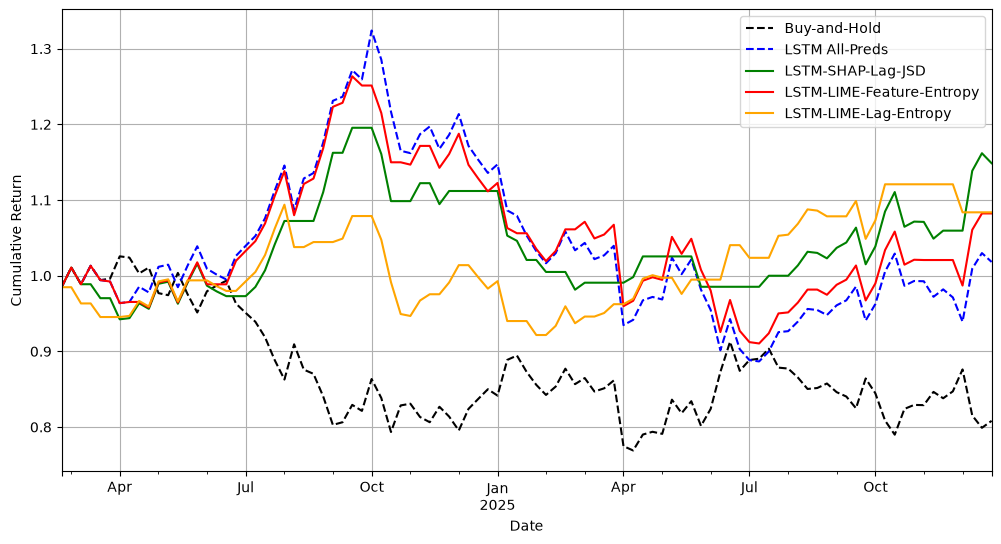

In [320]:
# Plot equity curves for all strategies on test set 2
plt.figure(figsize=(12, 6))
buy_and_hold_results["equity_curve"].plot(color='black', linestyle='--')
lstm_all_preds_results["equity_curve"].plot(color='blue', linestyle='--')
lstm_shap_lag_jsd["equity_curve"].plot(color='green', linestyle='-')
lstm_lime_feature_entropy["equity_curve"].plot(color='red', linestyle='-')
lstm_lime_lag_entropy["equity_curve"].plot(color='orange', linestyle='-')
plt.legend(["Buy-and-Hold", "LSTM All-Preds", "LSTM-SHAP-Lag-JSD",  "LSTM-LIME-Feature-Entropy", "LSTM-LIME-Lag-Entropy"])
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.savefig("Images/Equity Curves.png", dpi=300, bbox_inches='tight')
plt.show()